In [133]:
from __future__ import annotations

import json
import zipfile
from pathlib import Path
import unicodedata
import numpy as np
import pandas as pd
import holidays
import re
from zoneinfo import ZoneInfo
import duckdb

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score, 
    recall_score
 )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC

import gc

In [134]:
ACCIDENT_YEARS = [2024, 2025]
ACCIDENTS_DATA_DIR = Path("./data/datasets/sinistros")
ACCIDENTS_CACHE_PATH = Path("./data/datasets/acidentes.csv")
PARQUET_PATH = Path("./data/datasets/dataset_final.parquet")
PARQUET_EXISTS = PARQUET_PATH.exists()

In [135]:
# Funções auxiliares para manipular o dataset

def _load_single_dataset(path: Path, sep: str = ";", encoding: str = "latin1") -> pd.DataFrame:
    """Lê um único CSV de acidentes a partir de um caminho explícito.

    Parameters
    ----------
    path: Path
        Caminho do arquivo CSV a ser lido.
    sep: str
        Separador usado no CSV.
    encoding: str
        Codificação do arquivo original.

    Returns
    -------
    pandas.DataFrame
        Dataframe bruto carregado do arquivo informado.
    """
    return pd.read_csv(path, sep=sep, engine="python", encoding=encoding)


def load_dataset(
    years_or_path: list[int | str] | tuple[int | str, ...] | range | Path | str,
    data_dir: Path | None = None,
    sep: str = ";",
    encoding: str = "latin1",
) -> pd.DataFrame:
    """Carrega um ou mais datasets de acidentes.

    Parameters
    ----------
    years_or_path: list[int | str] | tuple[int | str, ...] | range | Path | str
        Quando `data_dir` é informado, representa os anos a serem lidos em
        ordem crescente. Quando `data_dir` é omitido, mantém o modo legado de
        leitura de um único arquivo por caminho explícito.
    data_dir: Path | None
        Diretório que contém os arquivos `datatran{ano}.csv`. Se `None`, a
        função interpreta `years_or_path` como um caminho de arquivo.
    sep: str
        Separador dos CSVs.
    encoding: str
        Codificação usada na leitura.

    Returns
    -------
    pandas.DataFrame
        Dataframe concatenado do ano mais antigo para o mais recente.

    Raises
    ------
    FileNotFoundError
        Quando um arquivo solicitado não existe.
    ValueError
        Quando a lista de anos fica vazia.
    """
    if data_dir is None:
        if not isinstance(years_or_path, (str, Path)):
            raise TypeError("Quando data_dir nao e informado, years_or_path precisa ser um caminho.")
        return _load_single_dataset(Path(years_or_path), sep=sep, encoding=encoding)

    years = sorted({int(year) for year in years_or_path})
    if not years:
        raise ValueError("Pelo menos um ano deve ser informado para carregar os acidentes.")

    data_dir = Path(data_dir)
    frames: list[pd.DataFrame] = []
    for year in years:
        csv_path = data_dir / f"datatran{year}.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"Dataset de acidentes nao encontrado: {csv_path}")
        frames.append(_load_single_dataset(csv_path, sep=sep, encoding=encoding))

    return pd.concat(frames, ignore_index=True)


# Tokens que representam valores ausentes
NUMERIC_MISSING_VALUES = [-200, -200.0]

STRING_MISSING_VALUES = [
    "?", " ?", "? ", "NA", "N/A", "na", "n/a", "NaN", "nan", "", " ",
    "unknown", "Unknown", "-200",
]

def make_one_hot_encoder(sparse: bool = True) -> OneHotEncoder:
    """Cria um OneHotEncoder compatível com diferentes versões do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse)


def split_X_y(df: pd.DataFrame, target: str, extra: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    """Separa variáveis explicativas e alvo de um dataframe.

    Parameters
    ----------
    df: pandas.DataFrame
        Dataframe já preparado para modelagem.
    target: str
        Nome da coluna alvo.
    extra: list[str]
        Colunas auxiliares que devem ser removidas do conjunto de entrada.

    Returns
    -------
    tuple[pandas.DataFrame, pandas.Series]
        `X` com as variáveis explicativas e `y` com o alvo.
    """
    if target not in df.columns:
        raise ValueError(f"Target '{target}' nao esta no dataset.")
    return df.drop(columns=[target] + extra), df[target]


def normalize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Substitui tokens de missing por NaN, coluna a coluna, respeitando o dtype.

    - Colunas numericas: substitui -200 e -200.0.
    - Colunas de texto: faz strip e substitui tokens como '?', 'unknown', etc.
    Essa abordagem evita erros do pandas 2.x ao misturar int e str no replace().
    """
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace(NUMERIC_MISSING_VALUES, np.nan)
        else:
            # Normaliza os tokens de ausente para np.nan antes do imputador,
            # porque pd.NA nesta base gera erro no pipeline com scikit-learn/pandas.
            df[col] = df[col].astype(object)
            df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)
            df[col] = df[col].replace(STRING_MISSING_VALUES, np.nan)
    return df


# Pré-Processamento

Os dados de acidentes de trânsito dos datasets da datatran já possuem dados muito interessantes a cerca dos acidentes: números de mortos, feridos, condição da pista, data e hora do acidente, período do dia, dia do acidente.

## Colunas booleanas

Porém, ainda é possível melhorar isso, adicionando colunas booleanas úteis para rápida identificação de informações e melhoria na identificação de certos fatores relacionados a períodos do ano.

Essas colunas são:
* teve_mortos
* teve_feridos_leves
* teve_feridos_graves
* teve_ilesos
* teve_feridos
* teve_ignorados

E também:
* e_feriado: Diz se o acidente aconteceu em um dia de feriado.
* em_feriado_prolongado: Diz se o acidente aconteceu durante um feriado prolongado, como diz a descrição de `build_holiday_flags`.


In [136]:

def build_victim_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Cria as colunas booleanas que indicam presença de vítimas.

    Parameters
    ----------
    df: pandas.DataFrame
        Dataframe bruto dos acidentes, já carregado dos CSVs.

    Returns
    -------
    pandas.DataFrame
        Cópia do dataframe com as colunas `teve_*` adicionadas.
    """
    df = df.copy()
    victim_columns = [
        "mortos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
        "feridos",
        "ignorados",
    ]
    for column in victim_columns:
        df[f"teve_{column}"] = df[column] > 0
    return df


def normalize_weekday_text(series: pd.Series) -> pd.Series:
    """Normaliza o texto do dia da semana para comparação simples.

    A base usa nomes em português com acentos. Normalizar para ASCII evita
    ter que manter várias grafias em listas de comparação.
    """
    return series.astype(str).map(
        lambda value: "".join(
            character
            for character in unicodedata.normalize("NFKD", value)
            if not unicodedata.combining(character)
        ).lower().strip()
    )


def build_weekend_flag(df: pd.DataFrame) -> pd.Series:
    """Marca sábado e domingo com base na coluna `dia_semana`.

    Returns
    -------
    pandas.Series
        Série booleana com `True` apenas para sábado e domingo.
    """
    normalized_weekday = normalize_weekday_text(df["dia_semana"])
    return normalized_weekday.isin({"sabado", "domingo"})


def build_brazil_holidays(df: pd.DataFrame) -> holidays.Brazil:
    """Cria o calendário de feriados brasileiros cobrindo os anos do dataframe.

    The `holidays` package espera um conjunto de anos. Como o notebook vai
    trabalhar com acidentes de vários anos, essa função infere o intervalo
    necessário diretamente da coluna `data_inversa`.
    """
    accident_years = pd.to_datetime(df["data_inversa"], errors="coerce").dt.year.dropna().astype(int)
    if accident_years.empty:
        return holidays.Brazil(years=[])
    years = sorted(accident_years.unique().tolist())
    return holidays.Brazil(years=years)


def build_holiday_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Cria as colunas `e_feriado` e `em_feriado_prolongado`.

    A lógica usada aqui separa duas ideias diferentes:
    - `e_feriado` marca apenas o dia oficial do feriado.
    - `em_feriado_prolongado` marca o feriado e os dias adjacentes do chamado
      feriado prolongado.

    Para feriados na terça-feira, o período prolongado inclui sábado, domingo,
    segunda e a própria terça. Para feriados na quinta-feira, inclui quinta,
    sexta, sábado e domingo. Para feriados na segunda ou na sexta, a emenda é
    mais curta, cobrindo sábado/domingo + o feriado. Nos demais feriados, a
    coluna de prolongado fica falsa, porque a regra pedida aqui só considera
    esses casos.
    """
    df = df.copy()
    dates = pd.to_datetime(df["data_inversa"], errors="coerce")
    brazil_holidays = build_brazil_holidays(df)
    holiday_dates = {pd.Timestamp(day) for day in brazil_holidays.keys()}
    prolonged_dates: set[pd.Timestamp] = set()

    for holiday_date in holiday_dates:
        if holiday_date.dayofweek == 1:
            # Feriado na terça: emenda com a segunda e o fim de semana anterior.
            prolonged_dates.update(
                {
                    holiday_date - pd.Timedelta(days=3),
                    holiday_date - pd.Timedelta(days=2),
                    holiday_date - pd.Timedelta(days=1),
                    holiday_date,
                }
            )
        elif holiday_date.dayofweek == 3:
            # Feriado na quinta: emenda com a sexta e o fim de semana seguinte.
            prolonged_dates.update(
                {
                    holiday_date,
                    holiday_date + pd.Timedelta(days=1),
                    holiday_date + pd.Timedelta(days=2),
                    holiday_date + pd.Timedelta(days=3),
                }
            )
        elif holiday_date.dayofweek == 0:
            # Feriado na segunda: prolonga com o fim de semana anterior.
            prolonged_dates.update(
                {
                    holiday_date - pd.Timedelta(days=2),
                    holiday_date - pd.Timedelta(days=1),
                    holiday_date,
                }
            )
        elif holiday_date.dayofweek == 4:
            # Feriado na sexta: prolonga com o fim de semana seguinte.
            prolonged_dates.update(
                {
                    holiday_date,
                    holiday_date + pd.Timedelta(days=1),
                    holiday_date + pd.Timedelta(days=2),
                }
            )

    df["e_feriado"] = dates.dt.normalize().isin(holiday_dates)
    df["em_feriado_prolongado"] = dates.dt.normalize().isin(prolonged_dates)
    return df


def preprocess_dataset(
    df: pd.DataFrame,
    cache_path: Path | None = None,
) -> pd.DataFrame:
    """Aplica o pré-processamento final do dataframe de acidentes.

    Parameters
    ----------
    df: pandas.DataFrame
        Dataframe bruto carregado a partir dos CSVs de acidentes.
    cache_path: Path | None
        Caminho opcional para persistir o dataframe final. Quando informado, a
        função salva a saída em cache após o processamento.

    Returns
    -------
    pandas.DataFrame
        Dataframe final com as flags booleanas e temporais adicionadas.
    """
    if cache_path is not None and cache_path.exists():
        print(f"Cache hit: {cache_path}")
        return pd.read_csv(cache_path)

    processed_df = build_victim_flags(df)
    processed_df["e_fim_de_semana"] = build_weekend_flag(processed_df)
    processed_df = build_holiday_flags(processed_df)

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        processed_df.to_csv(cache_path, index=False, encoding="utf-8")

    return processed_df


def load_or_preprocess_dataset(
    years_or_path: list[int | str] | tuple[int | str, ...] | range | Path | str,
    data_dir: Path | None = None,
    cache_path: Path | None = None,
    sep: str = ";",
    encoding: str = "latin1",
) -> pd.DataFrame:
    """Carrega do cache ou executa o fluxo completo de carregamento e pré-processamento.

    Essa função é usada no fluxo principal do notebook para evitar que os CSVs
    brutos sejam lidos quando `acidentes.csv` já existe.
    """
    if cache_path is not None and cache_path.exists():
        print(f"Cache hit: {cache_path}")
        return pd.read_csv(cache_path)

    raw_df = load_dataset(years_or_path, data_dir=data_dir, sep=sep, encoding=encoding)
    return preprocess_dataset(raw_df, cache_path=cache_path)



In [137]:
if not PARQUET_EXISTS:
    df = load_or_preprocess_dataset(
        ACCIDENT_YEARS,
        data_dir=ACCIDENTS_DATA_DIR,
        cache_path=ACCIDENTS_CACHE_PATH,    
    )
    df_acidentes = df

    df.head()

In [138]:
if not PARQUET_EXISTS:
    boolean_cols = df.select_dtypes(include="bool").columns.tolist()

    bool_counts = pd.DataFrame(
        {
            "True": df[boolean_cols].sum(),
            "False": (~df[boolean_cols]).sum(),
        }
    ).astype(int)

    display(bool_counts)

    categorical_columns = [
        "tipo_acidente",
        "classificacao_acidente",
        "fase_dia",
        "causa_acidente",
        "condicao_metereologica",
        "tipo_pista",
        "tracado_via",
        "regional"
    ]

    unique_values = {
        column: sorted(df[column].dropna().unique().tolist())
        for column in categorical_columns
        if column in df.columns
    }

    unique_values_df = pd.DataFrame(
        {
            "coluna": list(unique_values.keys()),
            "valores_unicos": list(unique_values.values()),
        }
     )

    display(unique_values_df)

# Integração com fontes externas

## Inmet

A primeira fonte de integração externa a ser utilizada será o INMET, que fornecerá dados acerca das condições climáticas no momento do acidente.

Os datasets do INMET, tem algumas peculiaridades que dificultam sua integração:

**Nomenclatura dos arquivos**

Nos CSVs do INMET estão os nomes das cidades onde as estações se localizam. Muitas cidades contém espaços em seus nomes, o que acaba gerando alguns erros nas leituras de CSVs, o que torna necessário normalizar o nome desses arquivos.

**Cabeçalho nos CSVs:**

```txt
REGIAO:;CO
UF:;DF
ESTACAO:;BRASILIA
CODIGO (WMO):;A001
LATITUDE:;-15,78944444
LONGITUDE:;-47,92583332
ALTITUDE:;1160,96
DATA DE FUNDACAO:;07/05/00
<Colunas>
```

Todo csv do INMET apresenta seus dados da estação nas 8 primeiras linhas do dataset, então, não se pode simplesmente só ler o arquivo e extrair as informações úteis. A partir da 9ª linha, começam os dados históricos da estação naquele no ano em escolhido.

**Grande quantidade de arquivos**

Para cada estação existe um arquivo, totalizando mais de quinhentos arquivos. Mesmo com um grande volume de acidentes, eles ocorreram em rodovias federais, então, é altamente improvável que todas as estações sejam usadas para complementar os dados de acidentes.


---

Para resolver esses problemas, é necessário realizar alguns pré-processamentos:
1. Extrair todos os dados das estações em um arquivo separado
2. Sanitizar os nomes dos arquivos, removendo espaços.
3. Com as estações, identificar quais são efetivamente viáveis para complementar o dataset de acidentes, descartando as que forem desnecessárias.
4. Das estações úteis, condensar todo o histórico dessas estações em um único CSV.
5. O objetivo é transformar todos os dados do INMET em dois CSVs: estações e histórico estações.



In [139]:
INMET_YEARS = ACCIDENT_YEARS 
INMET_RAW_ROOT = Path("./data/datasets/inmet_raw")
INMET_PROCESSED_ROOT = Path("./data/datasets/inmet_processed")
INMET_FILENAME_RE = re.compile(
    r"^INMET_(?P<regiao>[^_]+)_(?P<uf>[^_]+)_(?P<estacao_id>[^_]+)_(?P<cidade>.+)_(?P<periodo>\d{2}-\d{2}-\d{4}_A_\d{2}-\d{2}-\d{4})\.CSV$",
    re.IGNORECASE,
)

In [140]:
def normalize_inmet_token(value: str) -> str:
    """Normaliza um pedaço do nome da estação para poder usar como parte de arquivo.

    A função pega somente o texto da cidade ou de outro fragmento humano e faz uma
    transformação mecânica: remove espaços em branco repetidos e troca cada sequência
    de espaços por `-`. Ela não muda maiúsculas/minúsculas, não remove acentos e não
    tenta resolver nenhum outro caractere especial.

    Exemplo
    -------
    `SÃO JOÃO DA BARRA` -> `SÃO-JOÃO-DA-BARRA`
    """
    return re.sub(r"\s+", "-", value.strip())


def parse_inmet_filename(filename: str) -> dict[str, str]:
    """Lê o nome bruto do CSV do INMET e extrai os campos codificados nele.

    O padrão esperado é algo como::

        INMET_CO_DF_A001_BRASILIA_01-01-2025_A_31-12-2025.CSV

    A função valida se o nome bate com a regex definida para o projeto e, se bater,
    separa o nome em cinco pedaços úteis: região, UF, código da estação, cidade e
    período. A cidade passa pela normalização de hífens para virar uma chave segura
    de arquivo. Os demais campos são devolvidos em maiúsculas porque esse é o formato
    canônico usado no pipeline.

    Returns
    -------
    dict[str, str]
        Dicionário com `regiao`, `uf`, `estacao_id`, `cidade` e `periodo`.
    """
    match = INMET_FILENAME_RE.match(filename)
    if match is None:
        raise ValueError(f"Nome de arquivo INMET fora do padrao esperado: {filename}")

    info = match.groupdict()
    return {
        "regiao": info["regiao"].upper(),
        "uf": info["uf"].upper(),
        "estacao_id": info["estacao_id"].upper(),
        "cidade": normalize_inmet_token(info["cidade"]),
        "periodo": info["periodo"],
    }


def build_inmet_output_stem(filename: str) -> str:
    """Monta o nome-base dos CSVs derivados a partir do nome bruto do INMET.

    A função primeiro chama `parse_inmet_filename()` para decompor o nome original e
    depois recompõe um prefixo padronizado no formato::

        inmet_<regiao>_<uf>_<estacao_id>_<cidade>_<periodo>_dados

    Esse prefixo é usado tanto para o CSV de histórico quanto para o arquivo de
    metadados da estação. O objetivo é garantir que um arquivo bruto sempre gere os
    mesmos nomes de saída, independentemente de onde o pipeline seja executado.
    """
    info = parse_inmet_filename(filename)
    return (
        f"inmet_{info['regiao']}_{info['uf']}_{info['estacao_id']}_"
        f"{info['cidade']}_{info['periodo']}_dados"
    )


def load_inmet_station_metadata(path: Path) -> pd.DataFrame:
    """Lê as linhas de metadados no topo de um CSV bruto do INMET."""
    metadata = pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        nrows=8,
        header=None,
        names=["coluna", "valor"],
        engine="python",
    )
    metadata["coluna"] = metadata["coluna"].astype(str).str.replace(":", "", regex=False).str.strip()
    metadata["valor"] = metadata["valor"].astype(str).str.strip()
    return metadata


def load_inmet_data(path: Path) -> pd.DataFrame:
    """Lê o histórico de medições de um arquivo bruto do INMET."""
    df = pd.read_csv(path, sep=";", encoding="latin1", skiprows=8, engine="python")
    df = df.dropna(axis=1, how="all")
    df.columns = [str(column).strip() for column in df.columns]
    return df


def _normalize_inmet_column_name(value: object) -> str:
    """Normaliza nomes de colunas do INMET para facilitar comparações estruturais."""
    normalized = unicodedata.normalize("NFKD", str(value))
    normalized = "".join(character for character in normalized if not unicodedata.combining(character))
    normalized = normalized.lower().strip()
    return re.sub(r"[^a-z0-9]+", "_", normalized).strip("_")


def _summarize_inmet_precipitation(raw_data_df: pd.DataFrame) -> tuple[str | None, int, int]:
    """Identifica a coluna de precipitação e conta linhas sem medição válida."""
    precipitation_column = None
    for column in raw_data_df.columns:
        normalized_column = _normalize_inmet_column_name(column)
        if (
            normalized_column.startswith("precip")
            and "total" in normalized_column
            and "horario" in normalized_column
            and "mm" in normalized_column
        ):
            precipitation_column = column
            break

    total_rows = len(raw_data_df)
    if precipitation_column is None or total_rows == 0:
        return precipitation_column, total_rows, total_rows

    precipitation_series = raw_data_df[precipitation_column].apply(
        lambda value: value.strip() if isinstance(value, str) else value
    )
    precipitation_series = precipitation_series.replace(NUMERIC_MISSING_VALUES, np.nan)
    precipitation_series = precipitation_series.replace(STRING_MISSING_VALUES, np.nan)

    missing_rows = int(precipitation_series.isna().sum())
    return precipitation_column, missing_rows, total_rows


def preprocess_inmet_file(path: Path, output_dir: Path) -> tuple[dict[str, str], bool]:
    """Processa um arquivo bruto do INMET e indica se ele deve ser ignorado.

    O retorno é uma dupla ``(resultado, skip)``. O primeiro item preserva a estrutura
    atual do resumo do arquivo processado. O segundo item sinaliza se o arquivo deve
    ser descartado porque não possui coluna de precipitação útil ou porque mais de
    80% das linhas dessa coluna estão sem medição.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    output_stem = build_inmet_output_stem(path.name)
    metadata_path = output_dir / f"{output_stem}_station_metadata.csv"
    data_path = output_dir / f"{output_stem}.csv"

    raw_data_df = pd.read_csv(path, sep=";", encoding="latin1", skiprows=8, engine="python")
    precipitation_column, missing_rows, total_rows = _summarize_inmet_precipitation(raw_data_df)
    missing_ratio = (missing_rows / total_rows) if total_rows else 1.0
    skip = precipitation_column is None or missing_ratio > 0.8

    if skip:
        if precipitation_column is None:
            reason = "sem coluna de precipitacao"
        else:
            reason = f"{missing_rows}/{total_rows} linhas sem precipitacao ({missing_ratio:.1%})"
        print(f"[AVISO] Pulando {path.name}: {reason}")
        return (
            {
                "input_file": path.name,
                "metadata_path": str(metadata_path),
                "data_path": str(data_path),
            },
            True,
        )

    metadata_df = load_inmet_station_metadata(path)
    data_df = load_inmet_data(path)

    metadata_df.to_csv(metadata_path, index=False)
    data_df.to_csv(data_path, index=False)

    return (
        {
            "input_file": path.name,
            "metadata_path": str(metadata_path),
            "data_path": str(data_path),
        },
        False,
    )


def load_cached_inmet_directory_results(output_dir: Path, year_label: str) -> list[dict[str, str]]:
    """Reconstrói o resumo de uma pasta de INMET já processada, reaplicando o filtro de precipitação."""
    cached_results: list[dict[str, str]] = []
    metadata_files = sorted(output_dir.glob("*_station_metadata.csv"))
    skipped_files = 0

    for metadata_path in metadata_files:
        data_path = output_dir / metadata_path.name.replace("_station_metadata.csv", ".csv")
        if not data_path.exists():
            continue

        cached_data_df = pd.read_csv(data_path)
        precipitation_column, missing_rows, total_rows = _summarize_inmet_precipitation(cached_data_df)
        missing_ratio = (missing_rows / total_rows) if total_rows else 1.0
        if precipitation_column is None or missing_ratio > 0.8:
            skipped_files += 1
            if precipitation_column is None:
                reason = "sem coluna de precipitacao"
            else:
                reason = f"{missing_rows}/{total_rows} linhas sem precipitacao ({missing_ratio:.1%})"
            print(f"[AVISO] Pulando cache {data_path.name}: {reason}")
            continue

        cached_results.append(
            {
                "input_file": data_path.name,
                "metadata_path": str(metadata_path),
                "data_path": str(data_path),
                "year": year_label,
            }
        )

    print(f"Cache hit: {output_dir} | {len(cached_results)} arquivos reutilizados | {skipped_files} pulados")
    return cached_results


def preprocess_inmet_directory(year: int | str, source_root: Path, output_root: Path) -> list[dict[str, str]]:
    """Processa todos os CSVs de INMET de um ano, com cache por diretório."""
    year_label = str(year)
    source_dir = source_root / year_label
    output_dir = output_root / year_label

    if output_dir.exists():
        return load_cached_inmet_directory_results(output_dir, year_label)

    if not source_dir.exists():
        raise FileNotFoundError(f"Diretorio INMET nao encontrado: {source_dir}")

    csv_files = sorted(
        path for path in source_dir.iterdir()
        if path.is_file() and path.suffix.lower() == ".csv"
    )

    results: list[dict[str, str]] = []
    skipped_files = 0
    for path in csv_files:
        try:
            item, skip = preprocess_inmet_file(path, output_dir)
            if skip:
                skipped_files += 1
                continue
            item["year"] = year_label
            results.append(item)
        except Exception as exc:
            print(f"[ERRO] {path.name}: {exc}")

    print(
        f"Processados {len(results)} de {len(csv_files)} arquivos INMET em {output_dir} | "
        f"pulados {skipped_files}"
    )
    return results


if not PARQUET_EXISTS:
    inmet_results = []
    for year in INMET_YEARS:
        try:
            inmet_results.extend(preprocess_inmet_directory(year, INMET_RAW_ROOT, INMET_PROCESSED_ROOT))
        except Exception as exc:
            print(f"[ERRO] ano={year}: {exc}")

    inmet_results[:3]

In [141]:
INMET_PROCESSED_ROOT = Path("./data/datasets/inmet_processed")
INMET_AGGREGATED_ROOT = Path("./data/datasets/inmet_aggregated")
INMET_HISTORICO_PATH = INMET_AGGREGATED_ROOT / "inmet_historico.parquet"
ESTACOES_BASE_PATH = INMET_AGGREGATED_ROOT / "estacoes.csv"
ESTACOES_FINAIS_PATH = INMET_AGGREGATED_ROOT / "estacoes_finais.csv"
SINISTRO_ESTACAO_MAIS_PROXIMA_PATH = INMET_AGGREGATED_ROOT / "sinistro_estacao_mais_proxima.csv"
ACCIDENTS_CACHE_PATH = Path("./data/datasets/acidentes.csv")
BRASILIA_TZ = ZoneInfo("America/Sao_Paulo")

METADATA_KEY_ALIASES = {
    "regiao": "regiao",
    "uf": "uf",
    "estacao": "estacao",
    "codigo_wmo": "wmo",
    "wmo": "wmo",
    "latitude": "latitude",
    "longitude": "longitude",
    "altitude": "altitude",
    "data_de_fundacao": "data_de_fundacao",
}

EXPECTED_STATION_COLUMNS = [
    "wmo",
    "regiao",
    "uf",
    "estacao",
    "latitude",
    "longitude",
    "altitude",
    "data_de_fundacao",
    "source_file",
]

EXPECTED_MAPPING_COLUMNS = ["id", "wmo", "distancia_km"]


def slugify_text(value: object) -> str:
    """Normaliza texto para lower_snake_case ASCII."""
    text = unicodedata.normalize("NFKD", str(value))
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.lower().strip()
    return re.sub(r"[^a-z0-9]+", "_", text).strip("_")


def normalize_dataframe_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza os nomes das colunas para lower_snake_case ASCII."""
    kept_columns: list[str] = []
    normalized_columns: list[str] = []
    counts: dict[str, int] = {}

    for column in df.columns:
        normalized = slugify_text(column)
        if not normalized or normalized.startswith("unnamed"):
            continue

        count = counts.get(normalized, 0)
        counts[normalized] = count + 1
        kept_columns.append(column)
        normalized_columns.append(normalized if count == 0 else f"{normalized}_{count + 1}")

    cleaned_df = df.loc[:, kept_columns].copy()
    cleaned_df.columns = normalized_columns
    return cleaned_df


def normalize_station_value(value: object) -> str | None:
    """Remove espaços e trata strings vazias como ausentes."""
    if value is None or pd.isna(value):
        return None

    text = str(value).strip()
    if not text or text.lower() in {"nan", "none"}:
        return None
    return text


def clean_station_catalog(df: pd.DataFrame) -> pd.DataFrame:
    """Limpa o catálogo sem alterar o schema esperado."""
    cleaned_df = normalize_dataframe_columns(df)
    for column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].map(normalize_station_value)
    return cleaned_df


def load_station_metadata_row(metadata_path: Path) -> dict[str, str | None]:
    """Lê um arquivo de metadados do INMET e extrai os campos conhecidos."""
    metadata_df = pd.read_csv(metadata_path, dtype=str)

    if not {"coluna", "valor"}.issubset(metadata_df.columns):
        raise ValueError(f"Metadata invalido em {metadata_path.name}")

    metadata_lookup: dict[str, str | None] = {}
    for _, row in metadata_df[["coluna", "valor"]].iterrows():
        raw_key = slugify_text(row["coluna"])
        mapped_key = METADATA_KEY_ALIASES.get(raw_key)
        if mapped_key is not None:
            metadata_lookup[mapped_key] = normalize_station_value(row["valor"])

    wmo = metadata_lookup.get("wmo")
    if not wmo:
        raise ValueError(f"Nao foi possivel extrair o WMO de {metadata_path.name}")

    return {
        "wmo": wmo,
        "regiao": metadata_lookup.get("regiao"),
        "uf": metadata_lookup.get("uf"),
        "estacao": metadata_lookup.get("estacao"),
        "latitude": metadata_lookup.get("latitude"),
        "longitude": metadata_lookup.get("longitude"),
        "altitude": metadata_lookup.get("altitude"),
        "data_de_fundacao": metadata_lookup.get("data_de_fundacao"),
        "source_file": metadata_path.name.replace("_station_metadata.csv", ".csv"),
    }


def build_station_catalog_from_processed(years: list[int | str]) -> pd.DataFrame:
    """Monta o catálogo base a partir dos metadados já processados."""
    station_rows: list[dict[str, str | None]] = []
    seen_wmo: set[str] = set()

    for year in years:
        year_dir = INMET_PROCESSED_ROOT / str(year)
        if not year_dir.exists():
            print(f"[AVISO] Diretorio ausente, ignorando: {year_dir}")
            continue

        metadata_files = sorted(year_dir.glob("*_station_metadata.csv"))
        if not metadata_files:
            print(f"[AVISO] Nenhum metadata encontrado em: {year_dir}")
            continue

        for metadata_path in metadata_files:
            try:
                station_row = load_station_metadata_row(metadata_path)
            except Exception as exc:
                print(f"[ERRO] {metadata_path.name}: {exc}")
                continue

            wmo = station_row["wmo"]
            if wmo in seen_wmo:
                continue

            station_rows.append(station_row)
            seen_wmo.add(wmo)

    if not station_rows:
        raise RuntimeError("Nenhum arquivo INMET valido foi encontrado para consolidacao das estacoes.")

    station_df = pd.DataFrame(station_rows, columns=EXPECTED_STATION_COLUMNS)
    return clean_station_catalog(station_df)


def load_station_catalog() -> pd.DataFrame:
    """Carrega o catálogo base ou o recompõe por processamento local."""
    if ESTACOES_BASE_PATH.exists():
        print(f"Cache hit: {ESTACOES_BASE_PATH}")
        return clean_station_catalog(pd.read_csv(ESTACOES_BASE_PATH, dtype=str))[EXPECTED_STATION_COLUMNS]

    station_df = build_station_catalog_from_processed(INMET_YEARS)
    INMET_AGGREGATED_ROOT.mkdir(parents=True, exist_ok=True)
    station_df.to_csv(ESTACOES_BASE_PATH, index=False, encoding="utf-8")
    return station_df


def load_inmet_historico_cache() -> pd.DataFrame | None:
    """Carrega o histórico em Parquet."""
    if not INMET_HISTORICO_PATH.exists():
        return None

    print(f"Cache hit: {INMET_HISTORICO_PATH}")
    return pd.read_parquet(INMET_HISTORICO_PATH, engine="pyarrow")


def load_accident_source() -> pd.DataFrame:
    """Carrega os sinistros usados para escolher as estações mais próximas.

    Prioriza o dataframe já carregado no notebook e, se ele não estiver disponível,
    recai para o CSV pré-processado `data/datasets/acidentes.csv`.
    """
    existing_df = globals().get("df")
    if isinstance(existing_df, pd.DataFrame) and {"latitude", "longitude"}.issubset(existing_df.columns):
        return existing_df.copy()

    if not ACCIDENTS_CACHE_PATH.exists():
        raise FileNotFoundError(f"Arquivo de acidentes nao encontrado: {ACCIDENTS_CACHE_PATH}")

    return pd.read_csv(ACCIDENTS_CACHE_PATH, dtype=str)


def to_numeric_coordinate(series: pd.Series) -> pd.Series:
    """Converte coordenadas com vírgula decimal para número."""
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce",
    )


def haversine_distances_km(
    latitude: float,
    longitude: float,
    station_latitudes: np.ndarray,
    station_longitudes: np.ndarray,
) -> np.ndarray:
    """Calcula distâncias Haversine em quilômetros para várias estações."""
    earth_radius_km = 6371.0088
    lat1 = np.radians(latitude)
    lon1 = np.radians(longitude)
    lat2 = np.radians(station_latitudes.astype(float))
    lon2 = np.radians(station_longitudes.astype(float))
    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1
    a = np.sin(delta_lat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2.0) ** 2
    return 2.0 * earth_radius_km * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


def build_accident_station_mapping(station_catalog: pd.DataFrame, accident_df: pd.DataFrame) -> pd.DataFrame:
    """Relaciona cada sinistro válido com a estação mais próxima."""
    stations_with_coordinates = station_catalog.copy()
    stations_with_coordinates["latitude_num"] = to_numeric_coordinate(stations_with_coordinates["latitude"])
    stations_with_coordinates["longitude_num"] = to_numeric_coordinate(stations_with_coordinates["longitude"])
    stations_with_coordinates = stations_with_coordinates.dropna(subset=["latitude_num", "longitude_num"]).copy()

    if stations_with_coordinates.empty:
        raise RuntimeError("Nao foi possivel encontrar estações com coordenadas validas.")

    accidents_with_coordinates = accident_df.copy()
    accidents_with_coordinates["latitude_num"] = to_numeric_coordinate(accidents_with_coordinates["latitude"])
    accidents_with_coordinates["longitude_num"] = to_numeric_coordinate(accidents_with_coordinates["longitude"])
    accidents_with_coordinates = accidents_with_coordinates.dropna(subset=["latitude_num", "longitude_num"]).copy()

    mapping_rows: list[dict[str, object]] = []
    station_latitudes = stations_with_coordinates["latitude_num"].to_numpy(dtype=float)
    station_longitudes = stations_with_coordinates["longitude_num"].to_numpy(dtype=float)

    # Mantém um relacionamento persistido para evitar recalcular as distâncias em execuções futuras.
    for accident in accidents_with_coordinates.itertuples(index=False):
        accident_id = normalize_station_value(getattr(accident, "id", None))
        if not accident_id:
            continue

        distances = haversine_distances_km(
            float(accident.latitude_num),
            float(accident.longitude_num),
            station_latitudes,
            station_longitudes,
        )
        nearest_index = int(np.argmin(distances))
        nearest_station = stations_with_coordinates.iloc[nearest_index]
        mapping_rows.append(
            {
                "id": accident_id,
                "wmo": str(nearest_station["wmo"]),
                "distancia_km": float(distances[nearest_index]),
            }
        )

    mapping_df = pd.DataFrame(mapping_rows, columns=EXPECTED_MAPPING_COLUMNS)
    if not mapping_df.empty:
        print(
            f"Sinistros válidos: {len(mapping_df)} | "
            f"estações distintas: {mapping_df['wmo'].nunique()} | "
            f"distancia media: {mapping_df['distancia_km'].mean():.2f} km"
        )
    else:
        print("Nenhum sinistro válido com coordenadas foi encontrado.")
    return mapping_df


def load_or_build_accident_station_mapping(station_catalog: pd.DataFrame, accident_df: pd.DataFrame) -> pd.DataFrame:
    """Carrega sinistro_estacao_mais_proxima.csv ou gera o relacionamento do zero."""
    if SINISTRO_ESTACAO_MAIS_PROXIMA_PATH.exists():
        print(f"Cache hit: {SINISTRO_ESTACAO_MAIS_PROXIMA_PATH}")
        mapping_df = pd.read_csv(SINISTRO_ESTACAO_MAIS_PROXIMA_PATH, dtype={"id": str, "wmo": str})
        mapping_df = mapping_df.rename(columns=slugify_text)
        mapping_df = mapping_df[[column for column in EXPECTED_MAPPING_COLUMNS if column in mapping_df.columns]]
        if "distancia_km" in mapping_df.columns:
            mapping_df["distancia_km"] = pd.to_numeric(mapping_df["distancia_km"], errors="coerce")
        return mapping_df

    mapping_df = build_accident_station_mapping(station_catalog, accident_df)
    INMET_AGGREGATED_ROOT.mkdir(parents=True, exist_ok=True)
    mapping_df.to_csv(SINISTRO_ESTACAO_MAIS_PROXIMA_PATH, index=False, encoding="utf-8")
    return mapping_df


def load_or_build_final_stations(station_catalog: pd.DataFrame, accident_station_mapping: pd.DataFrame) -> pd.DataFrame:
    """Carrega estacoes_finais.csv ou recalcula a seleção a partir do relacionamento persistido."""
    if ESTACOES_FINAIS_PATH.exists():
        print(f"Cache hit: {ESTACOES_FINAIS_PATH}")
        return clean_station_catalog(pd.read_csv(ESTACOES_FINAIS_PATH, dtype=str))[EXPECTED_STATION_COLUMNS]

    selected_wmos = sorted(
        accident_station_mapping["wmo"].dropna().astype(str).unique().tolist()
    )
    final_stations = station_catalog.loc[station_catalog["wmo"].isin(selected_wmos)].copy()
    final_stations = final_stations[EXPECTED_STATION_COLUMNS]
    final_stations.to_csv(ESTACOES_FINAIS_PATH, index=False, encoding="utf-8")
    return final_stations


def build_processed_file_index() -> dict[str, Path]:
    """Indexa os CSVs processados por nome do arquivo para leitura rápida."""
    file_index: dict[str, Path] = {}
    for data_path in INMET_PROCESSED_ROOT.rglob("*_dados.csv"):
        file_index[data_path.name] = data_path
    return file_index


def parse_and_convert_station_history(data_path: Path, wmo: str) -> pd.DataFrame:
    """Normaliza um CSV bruto de estação para o formato final do histórico."""
    raw_df = pd.read_csv(data_path, encoding="latin1")
    raw_df = normalize_dataframe_columns(raw_df)

    if not {"data", "hora_utc"}.issubset(raw_df.columns):
        raise ValueError(f"Colunas de data ausentes em {data_path.name}")

    timestamps_utc = pd.to_datetime(
        raw_df["data"].astype(str).str.strip() + " " + raw_df["hora_utc"].astype(str).str.strip(),
        format="%Y/%m/%d %H%M UTC",
        errors="coerce",
        utc=True,
    )

    converted_df = raw_df.drop(columns=["data", "hora_utc"], errors="ignore").copy()
    converted_df.insert(0, "wmo", wmo)
    converted_df.insert(
        1,
        "data_hora",
        timestamps_utc.dt.tz_convert(BRASILIA_TZ).dt.strftime("%Y-%m-%d %H:%M:%S"),
    )
    converted_df = converted_df.dropna(subset=["data_hora"]).copy()

    for column in converted_df.columns:
        if column in {"wmo", "data_hora"}:
            continue
        converted_df[column] = pd.to_numeric(
            converted_df[column].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors="coerce",
        )

    ordered_columns = ["wmo", "data_hora"] + [column for column in converted_df.columns if column not in {"wmo", "data_hora"}]
    return converted_df.loc[:, ordered_columns]


def build_historico_from_catalog(selected_catalog: pd.DataFrame) -> pd.DataFrame:
    """Consolida apenas os arquivos das estações selecionadas."""
    if selected_catalog.empty:
        return pd.DataFrame(columns=["wmo", "data_hora"])

    file_index = build_processed_file_index()
    history_chunks: list[pd.DataFrame] = []
    missing_files: list[str] = []

    for station in selected_catalog.itertuples(index=False):
        source_file = normalize_station_value(getattr(station, "source_file", None))
        if not source_file:
            continue

        data_path = file_index.get(source_file)
        if data_path is None:
            missing_files.append(source_file)
            continue

        station_history = parse_and_convert_station_history(data_path, str(station.wmo))
        if not station_history.empty:
            history_chunks.append(station_history)

    if missing_files:
        print("[AVISO] Arquivos de histórico nao encontrados:")
        for missing_file in sorted(set(missing_files)):
            print(f"  - {missing_file}")

    if not history_chunks:
        return pd.DataFrame(columns=["wmo", "data_hora"])

    historico_df = pd.concat(history_chunks, ignore_index=True)
    historico_df = historico_df.sort_values(["wmo", "data_hora"], kind="stable").reset_index(drop=True)
    ordered_columns = ["wmo", "data_hora"] + [column for column in historico_df.columns if column not in {"wmo", "data_hora"}]
    return historico_df.loc[:, ordered_columns]


def load_or_build_historico(selected_catalog: pd.DataFrame) -> pd.DataFrame:
    """Carrega inmet_historico.parquet ou gera a consolidação final do zero."""
    cached_df = load_inmet_historico_cache()
    if cached_df is not None:
        return cached_df

    historico_df = build_historico_from_catalog(selected_catalog)
    historico_df.to_parquet(INMET_HISTORICO_PATH, index=False, compression="snappy", engine="pyarrow")
    return historico_df


if not PARQUET_EXISTS:
    INMET_AGGREGATED_ROOT.mkdir(parents=True, exist_ok=True)
    station_catalog = load_station_catalog()
    accident_df = load_accident_source()
    accident_station_mapping = load_or_build_accident_station_mapping(station_catalog, accident_df)
    final_station_catalog = load_or_build_final_stations(station_catalog, accident_station_mapping)
    historico_df = load_or_build_historico(final_station_catalog)

In [142]:
if not PARQUET_EXISTS:
    print(f"Arquivo de estacoes finais: {ESTACOES_FINAIS_PATH}")
    print(f"Estacoes base: {len(station_catalog)}")
    print(f"Estacoes finais: {len(final_station_catalog)}")
    final_station_catalog.head()

In [143]:
if not PARQUET_EXISTS:
    print(f"Arquivo de relacionamento: {SINISTRO_ESTACAO_MAIS_PROXIMA_PATH}")
    print(f"Relacionamento sinistro-estacao: {len(accident_station_mapping)}")
    accident_station_mapping.head()

In [144]:
if not PARQUET_EXISTS:
    print(f"Arquivo de historico: {INMET_HISTORICO_PATH}")
    print(f"Historico INMET: {len(historico_df)}")
    historico_df.head()

## Acrestando informação de precipitação

In [145]:
ACIDENTES_FINAL_PATH = ACCIDENTS_CACHE_PATH.with_name("acidentes_final.csv")


def _resolve_precipitation_column(df: pd.DataFrame) -> str:
    """Localiza, no histórico do INMET, a coluna com a precipitação horária total."""
    normalized_to_original = {slugify_text(column): column for column in df.columns}
    for normalized, original in normalized_to_original.items():
        if (
            normalized.startswith("precip")
            and "total" in normalized
            and "horario" in normalized
            and "mm" in normalized
        ):
            return original
    raise ValueError(
        "Nao foi possivel identificar a coluna de precipitacao no historico_df."
    )


def _floor_to_hour(series: pd.Series) -> pd.Series:
    """Converte uma série de datas e horas para o início da respectiva hora."""
    return pd.to_datetime(series, errors="coerce").dt.floor("h")


def _normalize_coordinate_text(value: object) -> str | None:
    """Padroniza coordenadas como texto com vírgula decimal."""
    if value is None or pd.isna(value):
        return None

    text = str(value).strip()
    if not text:
        return None

    return text.replace(".", ",")


def _load_accidents_source() -> pd.DataFrame:
    """Carrega o CSV de acidentes já processado e usado como base do enriquecimento."""
    if not ACCIDENTS_CACHE_PATH.exists():
        raise FileNotFoundError(
            f"Arquivo de acidentes nao encontrado: {ACCIDENTS_CACHE_PATH}"
        )
    return pd.read_csv(ACCIDENTS_CACHE_PATH)


def build_accidentes_final() -> pd.DataFrame:
    """Gera o dataset final de acidentes com estação mais próxima e precipitação do momento.

    A função preserva todas as linhas de `acidentes.csv`, associa cada acidente à
    estação mais próxima via `accident_station_mapping` e, em seguida, busca no
    `historico_df` a precipitação da mesma hora do acidente. Quando não existir
    informação de precipitação para o horário correspondente, o valor é preenchido
    com `0`. O resultado é salvo em cache em `acidentes_final.csv`.
    """
    if ACIDENTES_FINAL_PATH.exists():
        print(f"Cache hit: {ACIDENTES_FINAL_PATH}")
        cached_df = pd.read_csv(ACIDENTES_FINAL_PATH)
        if "momento_acidente" in cached_df.columns:
            cached_df = cached_df.drop(columns=["momento_acidente"])
        for column in ["latitude", "longitude"]:
            if column in cached_df.columns:
                cached_df[column] = cached_df[column].map(_normalize_coordinate_text)
        if "precimitacao_momento" in cached_df.columns:
            cached_df["precimitacao_momento"] = pd.to_numeric(
                cached_df["precimitacao_momento"], errors="coerce"
            ).fillna(0)
        cached_df.to_csv(ACIDENTES_FINAL_PATH, index=False, encoding="utf-8")
        return cached_df

    accidents_source = _load_accidents_source().copy()
    for column in ["latitude", "longitude"]:
        if column in accidents_source.columns:
            accidents_source[column] = accidents_source[column].map(
                _normalize_coordinate_text
            )

    station_mapping = globals().get("accident_station_mapping")
    if not isinstance(station_mapping, pd.DataFrame):
        if not SINISTRO_ESTACAO_MAIS_PROXIMA_PATH.exists():
            raise FileNotFoundError(
                f"Arquivo de relacionamento nao encontrado: {SINISTRO_ESTACAO_MAIS_PROXIMA_PATH}"
            )
        station_mapping = pd.read_csv(SINISTRO_ESTACAO_MAIS_PROXIMA_PATH)

    weather_history = globals().get("historico_df")
    if not isinstance(weather_history, pd.DataFrame):
        weather_history = load_inmet_historico_cache()
        if weather_history is None:
            raise FileNotFoundError(
                f"Arquivo de historico nao encontrado: {INMET_HISTORICO_PATH}"
            )

    required_accident_columns = {"id", "data_inversa", "horario"}
    missing_accident_columns = required_accident_columns.difference(
        accidents_source.columns
    )
    if missing_accident_columns:
        raise ValueError(
            f"Colunas ausentes em acidentes.csv: {sorted(missing_accident_columns)}"
        )

    required_mapping_columns = {"id", "wmo"}
    missing_mapping_columns = required_mapping_columns.difference(
        station_mapping.columns
    )
    if missing_mapping_columns:
        raise ValueError(
            f"Colunas ausentes em accident_station_mapping: {sorted(missing_mapping_columns)}"
        )

    precipitation_column = _resolve_precipitation_column(weather_history)

    accidents_source = accidents_source.copy()
    accidents_source["id"] = accidents_source["id"].astype("string")
    accidents_source["momento_acidente"] = _floor_to_hour(
        accidents_source["data_inversa"].astype(str).str.strip()
        + " "
        + accidents_source["horario"].astype(str).str.strip()
    )

    station_mapping = (
        station_mapping[["id", "wmo"]]
        .drop_duplicates(subset=["id"], keep="first")
        .copy()
    )
    station_mapping["id"] = station_mapping["id"].astype("string")
    station_mapping["wmo"] = station_mapping["wmo"].astype("string")
    station_mapping = station_mapping.rename(columns={"wmo": "estacao_mais_proxima"})

    weather_history = weather_history[["wmo", "data_hora", precipitation_column]].copy()
    weather_history["wmo"] = weather_history["wmo"].astype("string")
    weather_history["data_hora"] = _floor_to_hour(weather_history["data_hora"])

    # Testando foi observado que muitas estações próximas, em dados períodos
    # não apresentam informações de precipitação
    # então, como medida padrão e evitar perca de dados, optou-se por preencher os valores ausentes com 0, indicando ausência de precipitação, ao invés de descartar as linhas.
    print('Colunas precipitação - valores ausentes antes do preenchimento:', weather_history[precipitation_column].isna().sum())

    weather_history[precipitation_column] = pd.to_numeric(
        weather_history[precipitation_column]
        .replace(NUMERIC_MISSING_VALUES, np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    ).fillna(0)
    weather_history = weather_history.dropna(
        subset=["wmo", "data_hora"]
    ).drop_duplicates(subset=["wmo", "data_hora"], keep="last")
    weather_history = weather_history.rename(
        columns={precipitation_column: "precimitacao_momento"}
    )

    acidentes_final_df = accidents_source.merge(station_mapping, on="id", how="left")
    acidentes_final_df = acidentes_final_df.merge(
        weather_history,
        left_on=["estacao_mais_proxima", "momento_acidente"],
        right_on=["wmo", "data_hora"],
        how="left",
    )
    acidentes_final_df["precimitacao_momento"] = pd.to_numeric(
        acidentes_final_df["precimitacao_momento"], errors="coerce"
    ).fillna(0)


    print('|F| Colunas precipitação - valores ausentes antes do preenchimento:', acidentes_final_df["precimitacao_momento"].isna().sum())
    for column in ["latitude", "longitude"]:
        if column in acidentes_final_df.columns:
            acidentes_final_df[column] = acidentes_final_df[column].map(
                _normalize_coordinate_text
            )
    acidentes_final_df = acidentes_final_df.drop(
        columns=["momento_acidente", "wmo", "data_hora"], errors="ignore"
    )

    ACIDENTES_FINAL_PATH.parent.mkdir(parents=True, exist_ok=True)
    acidentes_final_df.to_csv(ACIDENTES_FINAL_PATH, index=False, encoding="utf-8")
    print(f"Arquivo salvo em: {ACIDENTES_FINAL_PATH}")
    return acidentes_final_df


if not PARQUET_EXISTS:
    acidentes_final_df = build_accidentes_final()
    acidentes_final_df.head()

# Etapa 3 - Análise Exploratória e Consultas SQL

## Carregamento do Parquet

In [146]:
if PARQUET_EXISTS:
    df_acidentes = pd.read_parquet(PARQUET_PATH)
else:
    if "acidentes_final_df" not in globals():
        raise RuntimeError("Pipeline CSV nao executado antes da exportacao do Parquet.")
    df_acidentes = acidentes_final_df.copy()
    PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_acidentes.to_parquet(PARQUET_PATH, index=False, compression="snappy", engine="pyarrow")
    PARQUET_EXISTS = True


print(f"Parquet carregado/exportado em: {PARQUET_PATH}")
print(f"df_acidentes: {df_acidentes.shape}")
df_acidentes.head()

Parquet carregado/exportado em: data/datasets/dataset_final.parquet
df_acidentes: (145685, 41)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,teve_feridos_leves,teve_feridos_graves,teve_ilesos,teve_feridos,teve_ignorados,e_fim_de_semana,e_feriado,em_feriado_prolongado,estacao_mais_proxima,precimitacao_momento
0,571789.0,2024-01-01,segunda-feira,03:56:00,ES,101,38,CONCEICAO DA BARRA,Ultrapassagem Indevida,Colisão lateral sentido oposto,...,False,True,True,True,True,False,True,True,A616,0.0
1,571804.0,2024-01-01,segunda-feira,04:50:00,PI,343,185,PIRIPIRI,Manobra de mudança de faixa,Colisão frontal,...,False,False,True,False,False,False,True,True,A335,0.0
2,571806.0,2024-01-01,segunda-feira,04:30:00,BA,116,578,BREJOES,Ingestão de álcool pelo condutor,Colisão frontal,...,False,False,True,False,True,False,True,True,A434,0.0
3,571818.0,2024-01-01,segunda-feira,06:30:00,SE,101,18,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,False,True,False,True,True,False,True,True,A421,0.0
4,571838.0,2024-01-01,segunda-feira,05:00:00,MT,364,240,RONDONOPOLIS,Condutor deixou de manter distância do veículo...,Colisão traseira,...,False,False,True,False,True,False,True,True,A907,0.0


## Queries

- [ ] Top 10 acidentes com mais mortos (Tabela)
- [ ] Top 10 acidentes com mais feridos (Tabela)
- [ ] Quantidade total de acidentes por dia da semana com a média (Histograma)
- [ ] Hora do dia (Histogramas)
    - [ ] Distribuição de acidentes
    - [ ] Distribuição de mortes
    - [ ] Distribuição de feridos
- [ ] Série temporal por ano
    - [ ] Nº de acidentes
    - [ ] Nº de mortes
    - [ ] Nº de feridos
- [ ] Série Temporal de média móvel semanal estadual
    - [ ] Nº de acidentes
    - [ ] Nº de mortes
    - [ ] Nº de feridos

### Top 10 acidentes

#### Por mortes

A primeira query visa mostrar quais foram os top 10 acidentes com o maior número de mortes. O intuito é tentar visualizar se algum estado, ou município, possuí alguma frequência maior, além de visualizar os maiores números de mortes, e como isso puxa outros valores, como número de feridos.

In [148]:
sql_top10_acidentes_mortes_query = """
SELECT 
    data_inversa, 
    dia_semana, 
    horario, 
    uf, 
    municipio, 
    causa_acidente, 
    tipo_acidente,
    condicao_metereologica, precimitacao_momento, 
    fase_dia, 
    latitude, 
    longitude,  
    pessoas, 
    mortos, 
    feridos_graves, 
    feridos_leves, 
    feridos, 
    id 
FROM df_acidentes
ORDER BY mortos DESC
LIMIT 10
"""

In [234]:
df_top10_mortos = duckdb.query(sql_top10_acidentes_mortes_query).df()

ids_top10_mortos = df_top10_mortos["id"].tolist()

display(df_top10_mortos)

,data_inversa,dia_semana,horario,uf,municipio,causa_acidente,tipo_acidente,condicao_metereologica,precimitacao_momento,fase_dia,latitude,longitude,pessoas,mortos,feridos_graves,feridos_leves,feridos,id
0,2024-12-21,sábado,03:45:00,MG,TEOFILO OTONI,Carga excessiva e/ou mal acondicionada,Colisão lateral sentido oposto,Céu Claro,0.0,Plena Noite,"-17,93577075","-41,52783055",54,37,5,8,13,661121.0
1,2024-01-07,domingo,23:15:00,BA,GAVIAO,Transitar na contramão,Colisão frontal,Céu Claro,0.0,Plena Noite,"-11,48858977","-39,75706888",32,23,9,0,9,576603.0
2,2025-10-17,sexta-feira,19:20:00,PE,SALOA,Velocidade Incompatível,Saída de leito carroçável,Céu Claro,0.0,Plena Noite,"-8,9597983","-36,7250367",37,16,19,2,21,730910.0
3,2024-12-22,domingo,14:50:00,TO,AGUIARNOPOLIS,Demais falhas na via,Queda de ocupante de veículo,Céu Claro,0.0,Pleno dia,"-6,560232","-47,460426",30,14,1,0,1,650541.0
4,2025-08-08,sexta-feira,21:25:00,MT,LUCAS DO RIO VERDE,Mal súbito do condutor,Colisão frontal,Céu Claro,0.0,Plena Noite,"-13,386935","-56,09091616",69,11,22,20,42,710458.0
5,2025-12-27,sábado,08:30:00,BA,MUCURI,Transitar na contramão,Colisão frontal,Céu Claro,0.0,Pleno dia,"-18,1494022","-39,9071147",11,10,1,0,1,756184.0
6,2025-05-13,terça-feira,21:15:00,MG,GRAO MOGOL,Pista Escorregadia,Saída de leito carroçável,Garoa/Chuvisco,0.0,Plena Noite,"-16,4074212","-43,2280038",21,9,9,1,10,697817.0
7,2025-03-30,domingo,17:00:00,BA,BOA VISTA DO TUPIM,Transitar na contramão,Colisão frontal,Céu Claro,0.0,Anoitecer,"-12,453237","-40,593145",15,9,3,2,5,695988.0
8,2024-10-20,domingo,21:40:00,PR,GUARATUBA,Reação tardia ou ineficiente do condutor,Engavetamento,Garoa/Chuvisco,0.0,Plena Noite,"-25,85933941","-48,95074368",13,9,0,2,2,636355.0
9,2024-04-11,quinta-feira,03:50:00,BA,TEIXEIRA DE FREITAS,Velocidade Incompatível,Tombamento,Céu Claro,0.0,Plena Noite,"-17,60125828","-39,74868393",34,8,6,17,23,593205.0


Pela tabela, percebe-se uma maior frequência do estado da Bahia, com quatro acidentes, todos causados por imprudência dos motoristas, estando acima da velocidade ou na contramão.

De forma, geral, a maioria dos acidentes, oito deles, aconteceu no período da noite, sem condições climáticas adversas.

Chama atenção também o número elevado de mortos e de pessoas envolvidas, com o acidente mais fatal, envolvendo 54 pessoas e vitimando 37.

#### Por feridos

Para questões de comparação, a query abaixo mostra o top 10 de acidentes por maior número de feridos. É esperado que acidentes com elevado número de feridos tendam a ter mais mortes, então, será feita uma análise desse top 10 e verificado quais acidentes se repetem nas duas consultas.

In [150]:
sql_top10_acidentes_feridos_query = """
SELECT 
    data_inversa, 
    dia_semana, 
    horario, 
    uf, 
    municipio, 
    causa_acidente, 
    tipo_acidente,
    condicao_metereologica, precimitacao_momento, 
    fase_dia, 
    latitude, 
    longitude,  
    pessoas, 
    mortos, 
    feridos_graves, 
    feridos_leves, 
    feridos, 
    id 
FROM df_acidentes
ORDER BY feridos DESC
LIMIT 10
"""

In [235]:
df_top10_feridos = duckdb.query(sql_top10_acidentes_feridos_query).df()

ids_top10_feridos = df_top10_feridos["id"].tolist()

display(df_top10_feridos)

,data_inversa,dia_semana,horario,uf,municipio,causa_acidente,tipo_acidente,condicao_metereologica,precimitacao_momento,fase_dia,latitude,longitude,pessoas,mortos,feridos_graves,feridos_leves,feridos,id
0,2024-12-04,quarta-feira,20:30:00,BA,OLINDINA,Reação tardia ou ineficiente do condutor,Colisão com objeto,Céu Claro,0.0,Plena Noite,"-11,59501797","-38,29838527",93,5,1,83,84,659555.0
1,2024-11-08,sexta-feira,00:10:00,TO,CARIRI DO TOCANTINS,Velocidade Incompatível,Saída de leito carroçável,Chuva,0.2,Plena Noite,"-11,77460203","-49,10744996",63,4,35,22,57,660799.0
2,2025-01-22,quarta-feira,14:05:00,MG,MONTES CLAROS,Velocidade Incompatível,Colisão frontal,Chuva,0.0,Pleno dia,"-16,8557147","-44,06141289",52,0,8,41,49,656774.0
3,2024-12-19,quinta-feira,14:00:00,BA,EUNAPOLIS,Transitar na contramão,Colisão frontal,Chuva,0.0,Pleno dia,"-16,33255702","-39,58174321",51,2,8,41,49,653200.0
4,2024-06-09,domingo,06:00:00,RR,CARACARAI,Reação tardia ou ineficiente do condutor,Tombamento,Céu Claro,0.0,Amanhecer,"1,218244","-60,388416",45,0,11,34,45,606265.0
5,2024-10-11,sexta-feira,19:30:00,BA,FORMOSA DO RIO PRETO,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Céu Claro,0.0,Plena Noite,"-10,88328898","-45,14664108",43,0,0,43,43,635040.0
6,2024-07-21,domingo,05:15:00,MG,CATUJI,Ausência de reação do condutor,Colisão frontal,Garoa/Chuvisco,0.0,Amanhecer,"-17,40682777","-41,51524967",45,1,1,42,43,615922.0
7,2024-10-06,domingo,03:30:00,MG,NAQUE,Condutor Dormindo,Saída de leito carroçável,Nublado,0.0,Plena Noite,"-19,22999819","-42,32682471",43,1,1,41,42,632954.0
8,2025-08-08,sexta-feira,21:25:00,MT,LUCAS DO RIO VERDE,Mal súbito do condutor,Colisão frontal,Céu Claro,0.0,Plena Noite,"-13,386935","-56,09091616",69,11,22,20,42,710458.0
9,2025-09-19,sexta-feira,22:10:00,MG,SETE LAGOAS,Velocidade Incompatível,Colisão traseira,Céu Claro,0.0,Plena Noite,"-19,5240479","-44,2624413",49,0,2,39,41,719513.0


In [237]:
print(f"IDs dos acidentes em ambas as tabelas: ", set(ids_top10_mortos).intersection(ids_top10_feridos))

display(df_top10_feridos[df_top10_feridos["id"].isin(ids_top10_mortos)])

IDs dos acidentes em ambas as tabelas:  {'710458.0'}


,data_inversa,dia_semana,horario,uf,municipio,causa_acidente,tipo_acidente,condicao_metereologica,precimitacao_momento,fase_dia,latitude,longitude,pessoas,mortos,feridos_graves,feridos_leves,feridos,id
8,2025-08-08,sexta-feira,21:25:00,MT,LUCAS DO RIO VERDE,Mal súbito do condutor,Colisão frontal,Céu Claro,0.0,Plena Noite,"-13,386935","-56,09091616",69,11,22,20,42,710458.0


Já sobre o top 10 acidentes com mais feridos, observa-se uma predominância do estado do Mato Grosso, com quatro dos dez acidentes, causados também por comportamento do condutor, sendo despeito aos limites de velocidade a mais comum.

Os acidentes também ocorreram em sua maioria a noite, com seis deles nessas condições. Porém, aqui as condições climáticas podem ter tido alguma influência, já que quatro deles ocorrem sob chuva.

Chama a atenção também o elevado número de pessoas envolvidas, com o menor envolvimento sendo 43. Esse índice elevado acaba contribuindo para aumentar o número de feridos, que atinge 84 no top 1, 83 deles leves.

Com exceção do acidente 710458, que também estava no top 10 mortes, com 11 fatalidades, o número de mortos não foi elevado na mesma proporção do número de feridos, o que surpreende.

A maioria dos acidentes aqui, ocorreu na quinta e na sexta-feira.

### Quantidade total de acidentes por dia da semana com a média 

A ideia dessa query é proporcionar uma visão de quantos acidentes ocorreram por dia da semana, com o intuito de proporcionar uma visão acerca de quais dias ocorrem mais acidentes. O senso comum diz que será no fim de semana.

In [152]:
sql_acidentes_por_semana_query = """
WITH total_por_dia AS (
    SELECT 
        CASE dia_semana
            WHEN 'domingo' THEN 1
            WHEN 'segunda-feira' THEN 2
            WHEN 'terça-feira' THEN 3
            WHEN 'quarta-feira' THEN 4
            WHEN 'quinta-feira' THEN 5
            WHEN 'sexta-feira' THEN 6
            WHEN 'sábado' THEN 7
        END as dia_semana_index,
        dia_semana,
        COUNT(*) as total_acidentes
    FROM df_acidentes
    GROUP BY dia_semana
)
SELECT dia_semana, total_acidentes
FROM total_por_dia
ORDER BY dia_semana_index
"""

In [153]:
df_acidentes_por_semana_query = duckdb.query(sql_acidentes_por_semana_query).df()
display(df_acidentes_por_semana_query)

,dia_semana,total_acidentes
0,domingo,23211
1,segunda-feira,20493
2,terça-feira,18374
3,quarta-feira,18940
4,quinta-feira,18975
5,sexta-feira,22497
6,sábado,23195


In [154]:

def show_barplot_acidentes_por_semana(df_acidentes_por_semana_query):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Capitaliza os dias da semana para a exibição no gráfico
    df_acidentes_por_semana_query['dia_semana_label'] = df_acidentes_por_semana_query['dia_semana'].str.capitalize()
    mean_val = df_acidentes_por_semana_query['total_acidentes'].mean()

    # Criação do Barplot usando Seaborn
    ax_acidentes_por_semana = sns.barplot(
        data=df_acidentes_por_semana_query, 
        x='dia_semana_label', 
        y='total_acidentes', 
        hue='dia_semana_label', 
        palette='viridis', 
        edgecolor='gray', 
        alpha=0.85,
        legend=False
    )

    # Formatando o eixo Y para usar pontos como separador de milhar (padrão brasileiro)
    ax_acidentes_por_semana.get_yaxis().set_major_formatter(
        ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.'))
    )

    # Adiciona os valores absolutos sobre cada barra
    for p in ax_acidentes_por_semana.patches:
        y_val = p.get_height()
        if y_val > 0:
            formatted_val = f'{int(y_val):,}'.replace(',', '.')
            ax_acidentes_por_semana.annotate(
                formatted_val, 
                (p.get_x() + p.get_width() / 2., y_val), 
                ha='center', 
                va='bottom', 
                fontsize=10, 
                fontweight='bold', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    # Adiciona a linha de média geral formatada com padrão brasileiro
    formatted_mean = f'{mean_val:,.1f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    plt.axhline(mean_val, color='crimson', linestyle='--', linewidth=2, label=f'Média Semanal: {formatted_mean}')

    plt.title("Total de Acidentes por Dia da Semana (2024-2025)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Dia da Semana", fontsize=12)
    plt.ylabel("Quantidade de Acidentes", fontsize=12)
    plt.ylim(0, df_acidentes_por_semana_query['total_acidentes'].max() * 1.15)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

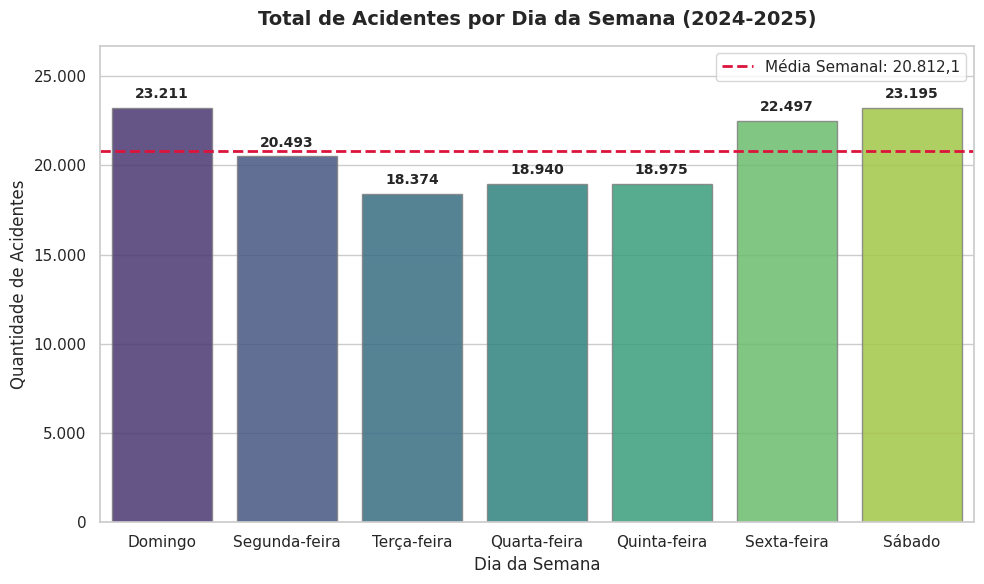

In [155]:
show_barplot_acidentes_por_semana(df_acidentes_por_semana_query)

Olhando o gráfico pode-se visualizar o esprado, com domingo, sábado e sexta-feiras possuindo o maior número de acidentes. Os três dias superam a média de 20,812 acidentes. Porém, não há uma grande redução no número de acidentes ao longo da semana, considerando essa totalização.

O Brasil é um país onde o transporte interno é feito por rodovias, sem haver outras alternativas que forneçam igual cobertura, como ferrovias ou hidrovias. Esse fato pode ajudar a explicar esse equilíbrio.

### Hora dia

Analisar como a hora do dia influenciou no número de acidentes, mortes e feridos, pode revelar padrões interessantes que auxiliem os modelos em sua missão de classificação.

Então a query obtém para cada hora do dia, o total de feridos e mortes.

In [156]:
sql_hora_dia_query = """
SELECT 
    LPAD(CAST(EXTRACT(HOUR FROM CAST(horario AS TIME)) AS VARCHAR), 2, '0') || ':00' as hora_formatada,
    EXTRACT(HOUR FROM CAST(horario AS TIME)) as hora,
    COUNT(*) as total_acidentes,
    SUM(mortos) as total_mortes,
    SUM(feridos) as total_feridos
FROM df_acidentes
GROUP BY hora_formatada, hora
ORDER BY hora
"""

In [157]:
df_hora_dia = duckdb.query(sql_hora_dia_query).df()
display(df_hora_dia)

,hora_formatada,hora,total_acidentes,total_mortes,total_feridos
0,00:00,0,2966,377.0,3038.0
1,01:00,1,2664,312.0,2637.0
2,02:00,2,2371,344.0,2362.0
3,03:00,3,2601,432.0,2596.0
4,04:00,4,3131,436.0,3264.0
5,05:00,5,4330,604.0,4755.0
6,06:00,6,6370,572.0,7444.0
7,07:00,7,9179,451.0,10897.0
8,08:00,8,7492,377.0,8766.0
9,09:00,9,6101,306.0,7066.0


In [ ]:
sns.set_theme(style="whitegrid")


def show_barplot_acidentes_por_hora(df_hora_dia):
    plt.figure(figsize=(10, 8))
    ax1 = sns.barplot(
        data=df_hora_dia,
        y='hora_formatada',
        x='total_acidentes',
        color='steelblue', # Azul aço sólido para acidentes
        edgecolor='gray',
        alpha=0.85
    )
    ax1.get_xaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    plt.title("Total de Acidentes por Hora do Dia (2024-2025)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Quantidade de Acidentes", fontsize=12)
    plt.ylabel("Hora do Dia", fontsize=12)
    plt.tight_layout()
    plt.show()


def show_barplot_mortes_por_hora(df_hora_dia):
    plt.figure(figsize=(10, 8))
    ax2 = sns.barplot(
        data=df_hora_dia,
        y='hora_formatada',
        x='total_mortes',
        color='#b33030', # Vermelho sólido para fatalidades
        edgecolor='gray',
        alpha=0.85
    )
    ax2.get_xaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    plt.title("Total de Mortes por Hora do Dia (2024-2025)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Quantidade de Mortes", fontsize=12)
    plt.ylabel("Hora do Dia", fontsize=12)
    plt.tight_layout()
    plt.show()


def show_barplot_feridos_por_hora(df_hora_dia):
    plt.figure(figsize=(10, 8))
    ax3 = sns.barplot(
        data=df_hora_dia,
        y='hora_formatada',
        x='total_feridos',
        color='#1e824c', # Verde sólido para feridos
        edgecolor='gray',
        alpha=0.85
    )
    ax3.get_xaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    plt.title("Total de Feridos por Hora do Dia (2024-2025)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Quantidade de Feridos", fontsize=12)
    plt.ylabel("Hora do Dia", fontsize=12)
    plt.tight_layout()
    plt.show()


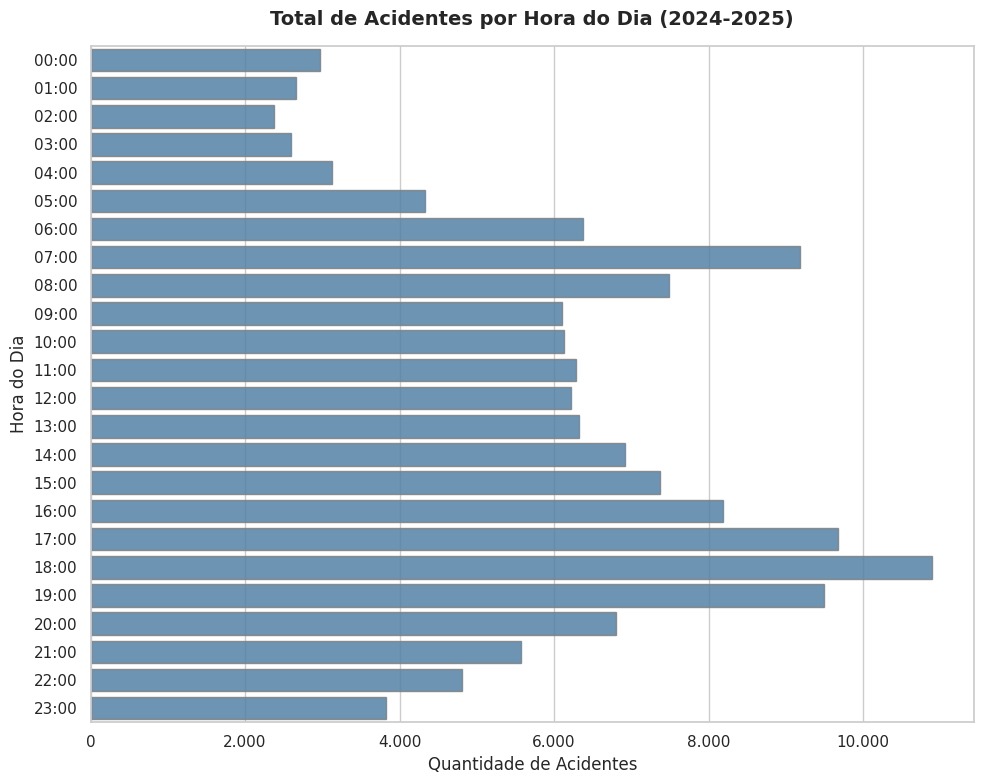

In [159]:
show_barplot_acidentes_por_hora(df_hora_dia)

Em relação ao total de acidentes, por hora, vemos que os picos ocorrem na chamada "Hora do Rush", quando as pessoas rotineramente vão e volta par ao trabalho, às 7 e às 18 horas. A hora do almoço, próximo ao meio-dia também tem um número mais elevado de acidentes.

A partir das 20 horas, até às 4h da manhã, o número de acidentes tendeu a reduzir.

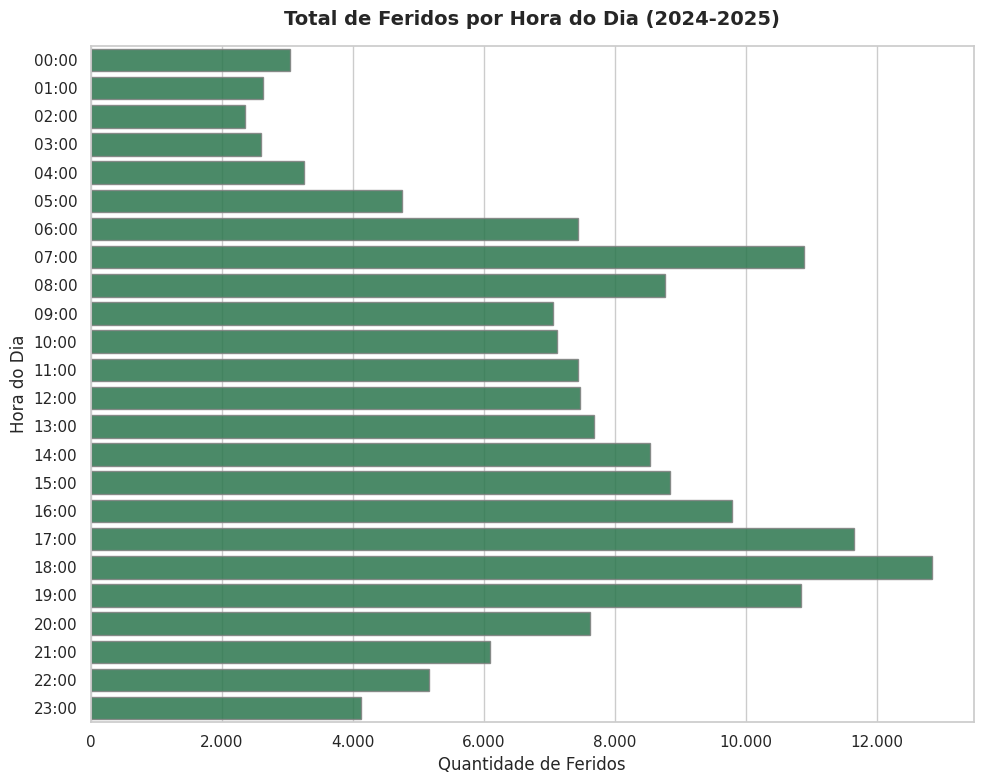

In [160]:
show_barplot_feridos_por_hora(df_hora_dia)

O gráfico de feridos, segue a mesma distribuição em seus dados, com os picos sendo às 7 e 18 horas. Como quanto mais acidentes, maior a probabilidade de feridos, faz sentido que quando um aumente o outro siga.

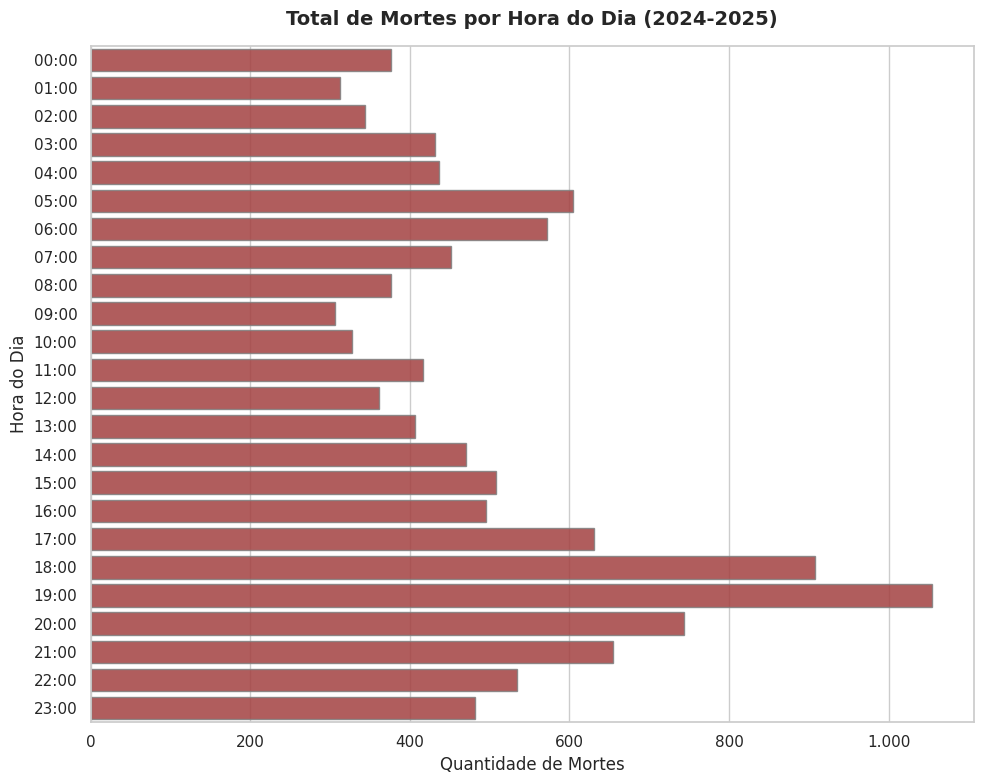

In [161]:
show_barplot_mortes_por_hora(df_hora_dia)

O gráfico de mortes, apesar de ter o mesmo formato, é diferente. O pico da tarde se deslocou das 18h para às 19h, apesar de ambos os horários serem muito elevados em fatalidades. Já o pico da manhã, se deslocou das 7h para às 5h.

Uma explicação possível para o deslocamento do pico da tarde é que, além do elevado fluxo de veículos que esses horários tendem a concentrar, há o fator atraso, pessoas que se atrasaram e querem chegar com pressa a algum lugar, tendem a ser mais imprudentes e a provocar acidentes graves.

Já o deslocamento do pico da manhã, pode ter sido deslocado pelo fato de que, como o fluxo de veículos nas estradas começa a aumentar a partir das 7h, pessoas para aproveitarem o "vazio na estrada" saem mais cedo em suas jornadas. Esse "vazio" pode passar uma sensação de segurança para o condutor, que se sente mais a vontade para ser imprudente na velocidade, o que acaba elevando a chance de fatalidades em caso de acidente. 

### Série Temporal por Ano

In [162]:
sql_serie_temporal_query = """
SELECT 
    EXTRACT(MONTH FROM CAST(data_inversa AS DATE)) as mes_num,
    EXTRACT(YEAR FROM CAST(data_inversa AS DATE)) as ano,
    COUNT(*) as total_acidentes,
    SUM(mortos) as total_mortes,
    SUM(feridos) as total_feridos
FROM df_acidentes
GROUP BY mes_num, ano
ORDER BY ano, mes_num
"""

In [163]:
df_serie_temporal = duckdb.query(sql_serie_temporal_query).df()
display(df_serie_temporal)

,mes_num,ano,total_acidentes,total_mortes,total_feridos
0,1,2024,5755,516.0,7124.0
1,2,2024,5280,390.0,6218.0
2,3,2024,5957,460.0,6729.0
3,4,2024,5835,478.0,6600.0
4,5,2024,6186,531.0,6899.0
5,6,2024,6225,535.0,7030.0
6,7,2024,6401,537.0,7383.0
7,8,2024,6167,546.0,7031.0
8,9,2024,6222,532.0,6979.0
9,10,2024,6406,493.0,7521.0


In [164]:
sns.set_theme(style="whitegrid")

def show_lineplot_serie_temporal_mensal(df_serie_temporal):
    if 'ano' not in df_serie_temporal.columns:
        raise KeyError(
            "A coluna 'ano' não foi encontrada. Certifique-se de copiar e re-executar "
            "a nova query SQL (que agrupa por 'mes_num' e 'ano') no seu notebook "
            "para atualizar a variável 'df_serie_temporal'!"
        )

    df_serie_temporal_copy = df_serie_temporal.copy()
    # Converte o ano para string para que o Seaborn o trate como variável categórica no 'hue'
    df_serie_temporal_copy['ano'] = df_serie_temporal_copy['ano'].astype(str)

    # Criando 3 subplots verticais compartilhando o mesmo eixo X (meses)
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # Nomes dos meses para exibição no eixo X
    months_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

    # 5.1 Evolução de Acidentes
    sns.lineplot(
        data=df_serie_temporal_copy, 
        x='mes_num', 
        y='total_acidentes', 
        hue='ano', 
        marker='o', 
        linewidth=2.5, 
        palette={'2024': '#1f77b4', '2025': '#ff7f0e'},
        ax=axes[0]
    )
    axes[0].set_title("Evolução Mensal de Acidentes (Comparativo por Ano)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Nº de Acidentes", fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].legend(title="Ano")
    axes[0].get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    # 5.2 Evolução de Mortes
    sns.lineplot(
        data=df_serie_temporal_copy, 
        x='mes_num', 
        y='total_mortes', 
        hue='ano', 
        marker='s', 
        linewidth=2.5, 
        palette={'2024': '#1f77b4', '2025': '#ff7f0e'},
        ax=axes[1]
    )
    axes[1].set_title("Evolução Mensal de Mortes (Comparativo por Ano)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Nº de Mortes", fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend(title="Ano")
    axes[1].get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    # 5.3 Evolução de Feridos
    sns.lineplot(
        data=df_serie_temporal_copy, 
        x='mes_num', 
        y='total_feridos', 
        hue='ano', 
        marker='^', 
        linewidth=2.5, 
        palette={'2024': '#1f77b4', '2025': '#ff7f0e'},
        ax=axes[2]
    )
    axes[2].set_title("Evolução Mensal de Feridos (Comparativo por Ano)", fontsize=12, fontweight='bold')
    axes[2].set_ylabel("Nº de Feridos", fontsize=11)
    axes[2].set_xlabel("Mês do Ano", fontsize=11)
    axes[2].grid(True, linestyle='--', alpha=0.7)
    axes[2].legend(title="Ano")
    axes[2].get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    # Customização do eixo X com os meses
    plt.xticks(range(1, 13), months_labels)

    plt.suptitle("Série Temporal de Acidentes, Mortes e Feridos - Comparativo por Ano", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


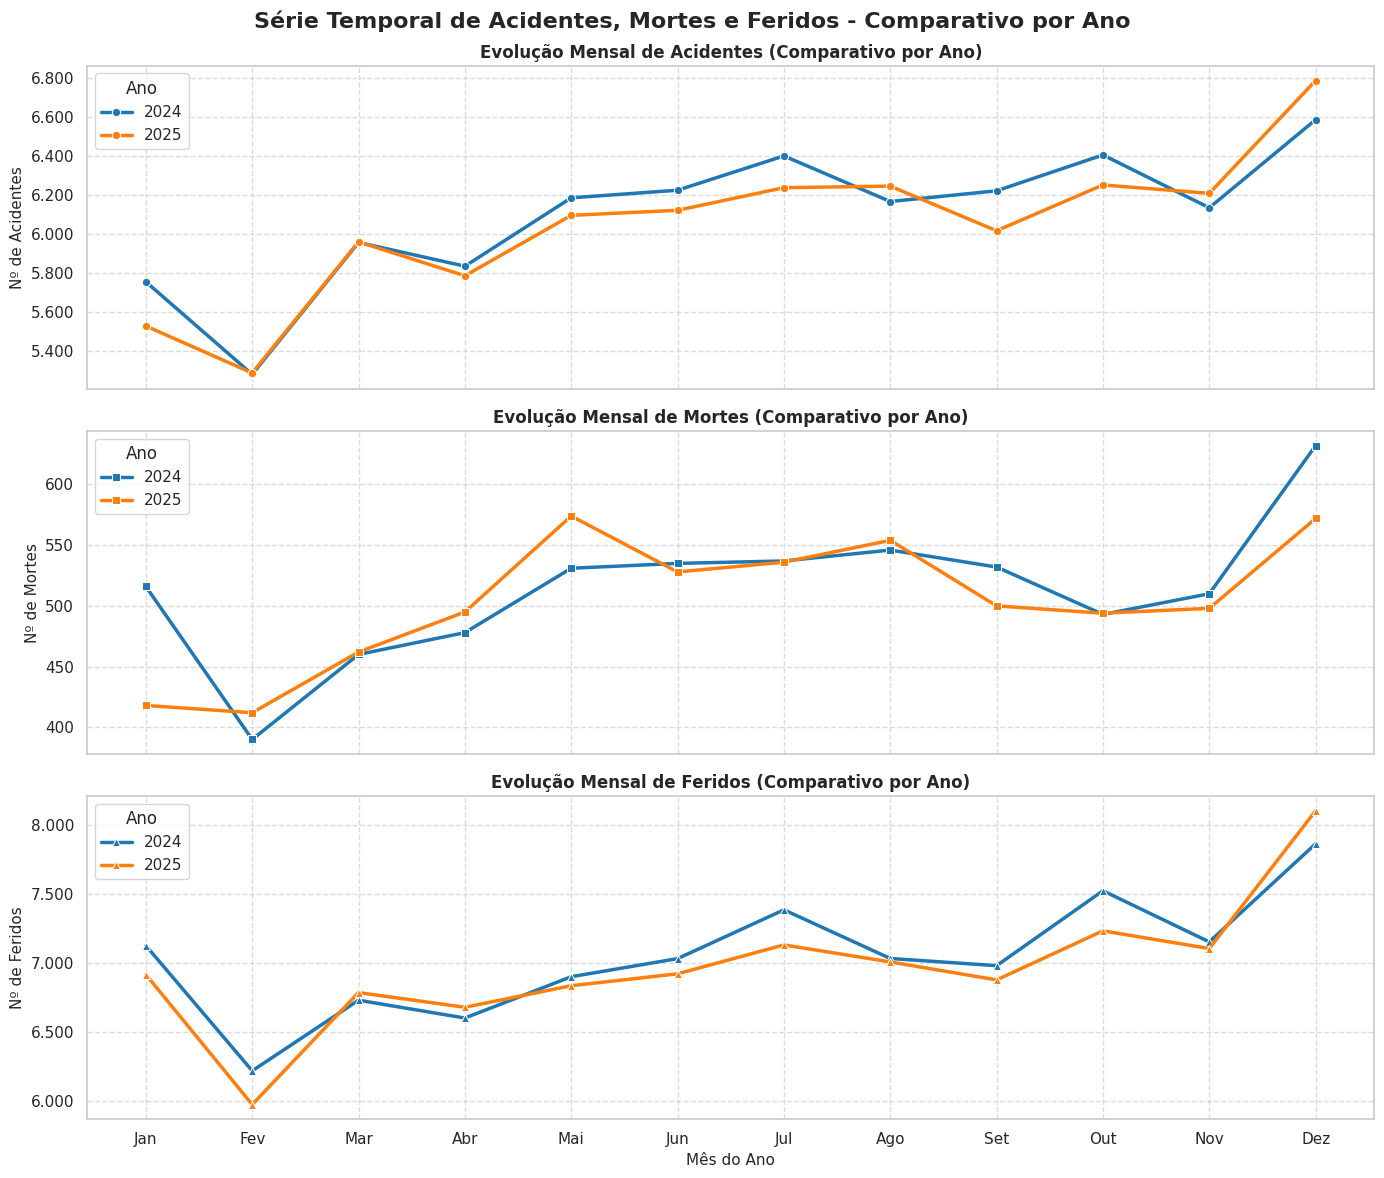

In [165]:
show_lineplot_serie_temporal_mensal(df_serie_temporal)

Analisando como o Nº de acidentes, mortos e feridos evoluiu nos anos de registro do dataset, vemos que os três valores tendem a caminhar juntos. 

Existe um pico bem claro em Dezembro, causado provavelmente pelas festas de fim de ano e o aumento no número de viagens. Esse pico vai diminuindo ao longo de Janeiro até atingir uma mínima anual em Fevereiro.

Outro fator que chama atenção é que, a linha do gráfico de ambos os anos, segue o mesmo padrão, com a diferença mais gritante sendo Janeiro, quando 2024 teve uma grande diferença no número de mortes em relação a 2025. 

### Media móvel

Um outro detalhe interessante de ser visualizado é a média móvel semanal de acidentes, feridos e mortes, proporcionando uma noção mais fechada de como esses atributos evoluíram ao longo do tempo:

In [166]:
# %% [markdown]
# 
# Esta query calcula a média móvel de 7 dias (semana móvel) para o número de acidentes, mortos e feridos por estado (UF).
# 
# ### Explicação das Decisões de Modelagem da Query:
# 
# 1. **Construção de uma Grade Calendário Completa (`CROSS JOIN`):**
#    Em análises de séries temporais estaduais, alguns estados (especialmente os menores) podem passar dias sem registrar nenhum acidente. 
#    Se fizermos apenas um agrupamento simples (`GROUP BY data, uf`), esses dias sem acidentes ficarão ausentes na tabela de resultados. 
#    Ao aplicar a função de janela de média móvel (`ROWS BETWEEN 6 PRECEDING AND CURRENT ROW`), o banco de dados consideraria as 7 linhas *anteriores gravadas* no banco para aquele estado. 
#    Como haveria dias pulados, a média não seria de uma "semana cronológica" real, e sim de "7 dias com acidentes", o que distorceria o resultado.
#    Para resolver isso, criamos duas tabelas auxiliares temporárias (`dates` e `states`) contendo todas as datas e UFs únicas e fazemos um **`CROSS JOIN`** entre elas. Isso gera o produto cartesiano de todos os dias por todas as UFs, garantindo que tenhamos uma linha para cada combinação de dia e estado.
# 
# 2. **Preenchimento de Lacunas (`LEFT JOIN` + `COALESCE`):**
#    Cruzamos a grade de datas/UFs criada com os dados reais de acidentes usando um **`LEFT JOIN`**. Onde não existirem registros reais para aquela data e estado, as métricas seriam retornadas como `NULL`. Usamos a função `COALESCE(valor, 0)` para converter esses `NULL` em `0`.
# 
# 3. **Função de Janela para a Média Móvel Semanal:**
#    Usamos a função analítica `AVG(campo) OVER (PARTITION BY uf ORDER BY data ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)`.
#    - `PARTITION BY uf`: Isola o cálculo da média móvel para cada estado individualmente.
#    - `ORDER BY data`: Garante que a média considere a ordem cronológica correta dos dias.
#    - `ROWS BETWEEN 6 PRECEDING AND CURRENT ROW`: Define a janela de cálculo como o dia atual e os 6 dias imediatamente anteriores (totalizando 7 dias de calendário). Como garantimos que não há dias ausentes, este cálculo representa com precisão matemática a média móvel semanal.

# %%
sql_query = """
-- CTE 1: Seleciona todas as datas únicas do dataset (cobrindo todo o período de 2 anos)
WITH dates AS (
    SELECT DISTINCT CAST(data_inversa AS DATE) as data FROM df_acidentes
),

-- CTE 2: Seleciona todas as UFs únicas presentes no dataset
states AS (
    SELECT DISTINCT uf FROM df_acidentes
),

-- CTE 3: Produto cartesiano completo entre datas e UFs. 
-- Isso gera uma "grade" ou "grid" contendo 731 dias * 27 UFs = 19.737 combinações.
-- Esta grade serve para garantir a continuidade temporal de todos os estados.
date_state_grid AS (
    SELECT d.data, s.uf FROM dates d CROSS JOIN states s
),

-- CTE 4: Agrupamento real do dataset original para contar acidentes e somar mortos/feridos por dia e UF
daily_state_raw AS (
    SELECT 
        CAST(data_inversa AS DATE) as data,
        uf,
        COUNT(*) as total_acidentes,
        SUM(mortos) as total_mortes,
        SUM(feridos) as total_feridos
    FROM df_acidentes
    GROUP BY data, uf
),

-- CTE 5: Junção da grade de datas/UFs com os dados de acidentes reais usando LEFT JOIN.
-- Para os dias em que um estado não registrou nenhum acidente, o LEFT JOIN trará NULL nas métricas.
-- Usamos o COALESCE para transformar esses NULLs em 0, permitindo um cálculo correto da média móvel.
daily_state_filled AS (
    SELECT 
        g.data,
        g.uf,
        COALESCE(r.total_acidentes, 0) as total_acidentes,
        COALESCE(r.total_mortes, 0) as total_mortes,
        COALESCE(r.total_feridos, 0) as total_feridos
    FROM date_state_grid g
    LEFT JOIN daily_state_raw r ON g.data = r.data AND g.uf = r.uf
)

-- Query Final: Aplica a média móvel semanal (7 dias de calendário) para as três métricas.
-- A média móvel é obtida por funções de janela analíticas do SQL.
SELECT 
    data,
    uf,
    total_acidentes,
    total_mortes,
    total_feridos,
    -- Calcula a média móvel de acidentes (janela de 7 dias)
    AVG(total_acidentes) OVER (
        PARTITION BY uf 
        ORDER BY data 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) as avg_acidentes_semanal,
    
    -- Calcula a média móvel de mortes (janela de 7 dias)
    AVG(total_mortes) OVER (
        PARTITION BY uf 
        ORDER BY data 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) as avg_mortes_semanal,
    
    -- Calcula a média móvel de feridos (janela de 7 dias)
    AVG(total_feridos) OVER (
        PARTITION BY uf 
        ORDER BY data 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) as avg_feridos_semanal
FROM daily_state_filled
ORDER BY uf, data
"""

In [167]:
df_media_movel = duckdb.query(sql_query).df()
display(df_media_movel)

,data,uf,total_acidentes,total_mortes,total_feridos,avg_acidentes_semanal,avg_mortes_semanal,avg_feridos_semanal
0,2024-01-01,AC,0,0.0,0.0,0.000000,0.000000,0.000000
1,2024-01-02,AC,1,0.0,0.0,0.500000,0.000000,0.000000
2,2024-01-03,AC,1,0.0,1.0,0.666667,0.000000,0.333333
3,2024-01-04,AC,0,0.0,0.0,0.500000,0.000000,0.250000
4,2024-01-05,AC,1,0.0,3.0,0.600000,0.000000,0.800000
...,...,...,...,...,...,...,...,...
19732,2025-12-27,TO,0,0.0,0.0,3.142857,0.857143,4.285714
19733,2025-12-28,TO,1,0.0,2.0,2.714286,0.857143,4.142857
19734,2025-12-29,TO,2,0.0,2.0,2.571429,0.285714,4.285714
19735,2025-12-30,TO,1,0.0,1.0,1.571429,0.142857,2.571429


In [231]:
sns.set_theme(style="whitegrid")

def show_lineplot_media_movel_estadual(df_media_movel, estados_destaque=None):
    if estados_destaque is None:
        # Padrão: top 5 estados com mais acidentes no dataset geral
        estados_destaque = ['MG', 'SC', 'PR', 'RJ', 'RS']
        
    df_media_movel_copy = df_media_movel.copy()
    
    # Convertendo a coluna 'data' para datetime para plotagem correta
    df_media_movel_copy['data'] = pd.to_datetime(df_media_movel_copy['data'])

    # Filtrando para as UFs destacadas para evitar poluição visual
    df_destaque = df_media_movel_copy[df_media_movel_copy['uf'].isin(estados_destaque)].copy()

    # Criando 3 subplots verticais compartilhando o eixo X
    fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

    # Formatter para o padrão brasileiro (ex: 2.345,6 ou 1,2)
    pt_br_float_formatter = ticker.FuncFormatter(
        lambda x, p: f'{x:,.1f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    )

    # 6.1 Média Móvel de Acidentes
    sns.lineplot(
        data=df_destaque,
        x='data',
        y='avg_acidentes_semanal',
        hue='uf',
        linewidth=2.0,
        ax=axes[0]
    )
    axes[0].set_title("Média Móvel Semanal de Acidentes por Estado", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Média Diária (7 dias)", fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].legend(title="Estado (UF)")
    axes[0].get_yaxis().set_major_formatter(pt_br_float_formatter)

    # 6.2 Média Móvel de Mortes
    sns.lineplot(
        data=df_destaque,
        x='data',
        y='avg_mortes_semanal',
        hue='uf',
        linewidth=2.0,
        ax=axes[1]
    )
    axes[1].set_title("Média Móvel Semanal de Mortes por Estado", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Média Diária (7 dias)", fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend(title="Estado (UF)")
    axes[1].get_yaxis().set_major_formatter(pt_br_float_formatter)

    # 6.3 Média Móvel de Feridos
    sns.lineplot(
        data=df_destaque,
        x='data',
        y='avg_feridos_semanal',
        hue='uf',
        linewidth=2.0,
        ax=axes[2]
    )
    axes[2].set_title("Média Móvel Semanal de Feridos por Estado", fontsize=12, fontweight='bold')
    axes[2].set_ylabel("Média Diária (7 dias)", fontsize=11)
    axes[2].set_xlabel("Data", fontsize=11)
    axes[2].grid(True, linestyle='--', alpha=0.7)
    axes[2].legend(title="Estado (UF)")
    axes[2].get_yaxis().set_major_formatter(pt_br_float_formatter)

    plt.suptitle("Séries Temporais Estaduais com Média Móvel de 7 Dias", fontsize=16, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.show()


Como um gráfico com as 27 ufs brasileiras ficaria muito poluído, optou-se por visualizar a média móvel dos 6 com maior número de acidentes.

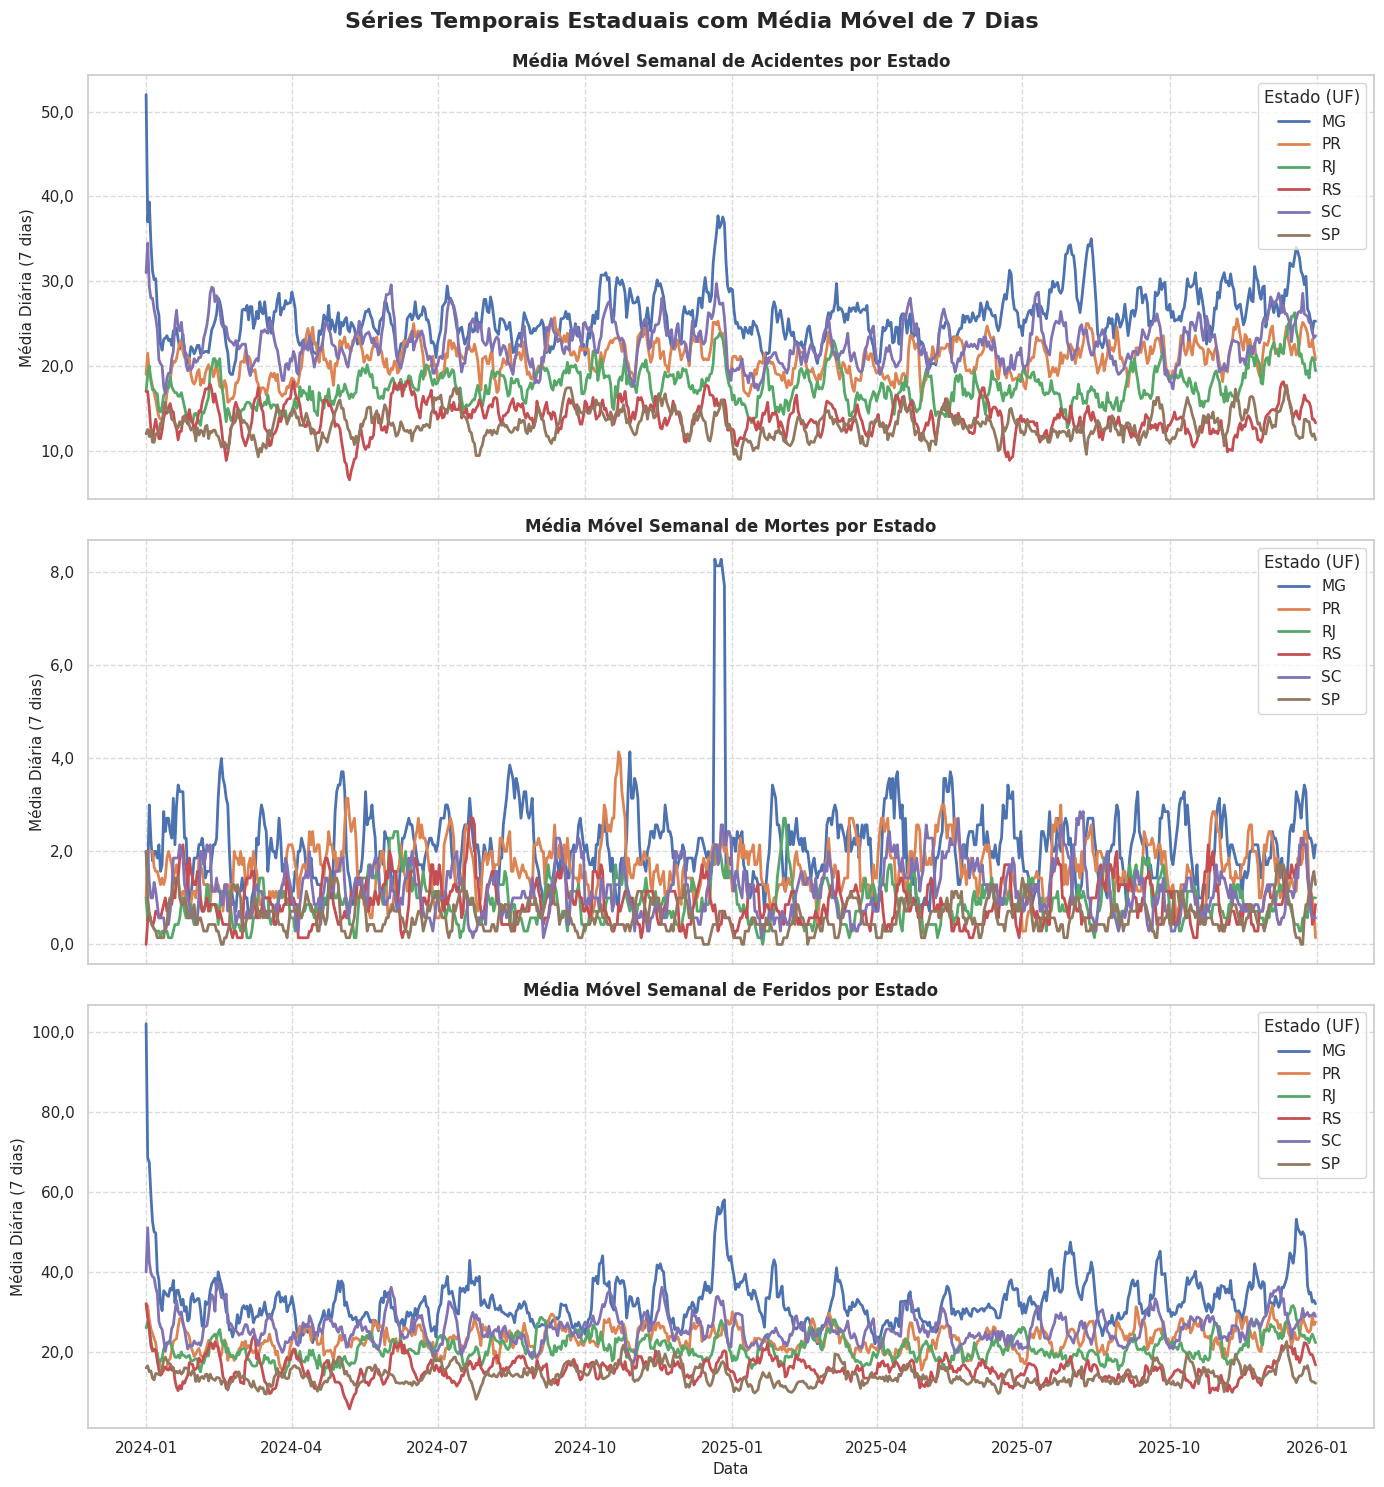

In [232]:
ufs_com_mais_acidentes = df_acidentes['uf'].value_counts().head(6).index.tolist()


show_lineplot_media_movel_estadual(df_media_movel, estados_destaque=ufs_com_mais_acidentes)

No início dos gráficos, podemos ver aquele pico em Janeiro de 2024 com mais detalhes, vendo que houve um grande número de acidentes em Minas Gerais, com número de feridos bem fora da curva. Porém, isso não resultou em muitas mortes. Vemos também que o período das festas de fim de ano tende realmente a causar picos de acidentes, aumentando o número de feridos e mortes.

Minas gerais se destaca sendo o estado com maior número de acidentes, o que o torna o estado com mais feridos e mortes.

Santa Cataria e Paraná também se destacam como estados com médias móveis consideráveis, ficando em segundo e terceiro, geralmente.

Destaca-se que todos os seis estados são das regiões sul e sudoeste. Com a presença de portos importantes, praias, e sendo as regiões "mais desenvolvidas" do país, com uma grande frota, faz sentido que eles estejam no topo.

A média móvel é um indicador que pode auxiliar os modelos no momento da classificação, já que, se a média móvel está elevada, a maior chance de um acidente que ocorrer nesse período resulte em fatalidades.

## Testes de Hipótese

In [170]:
from scipy.stats import f_oneway


### T1: A presença de chuvas aumenta a quantidade de fatalidades em acidentes

* H0: A presença de chuvas, NÃO aumenta a quantidade de fatalidades.
* H1: A presença de chuvas, aumenta a quantidade de fatalidades.

A presença de chuvas no momento do acidente é dado pela coluna `condicao_metereologica`, que pode assumir os seguintes valores:

In [171]:
df_acidentes['condicao_metereologica'].unique().tolist()

['Céu Claro',
 'Chuva',
 'Sol',
 'Nublado',
 'Garoa/Chuvisco',
 'Ignorado',
 'Vento',
 'Nevoeiro/Neblina',
 'Granizo',
 'Neve']

Então, para esse teste, consideramos todos os acidentes acinalados com a condição de `'Chuva'`. E verificamos como a presença desse elemento afetou a o número de `mortes` em relação a outras condições. Para a comparação, serão considerados os seguintes grupos:
- "Dia Limpo": 'Céu Claro' +  'Sol'
- "Dia Coberto": 'Nublado' + 'Garoa/Chuvisco'
- "Neblina": 'Nevoeiro/Neblina'
- "Chuva": 'Chuva'
- "Outros": 'Neve' + 'Vento' + 'Ignorado'


In [172]:
df_t1 = df_acidentes.copy()

mask_mortos = df_t1['teve_mortos']
mask_dia_limpo = (mask_mortos & df_t1['condicao_metereologica'].isin(['Céu Claro', 'Sol']))
mask_dia_coberto = (mask_mortos & df_t1['condicao_metereologica'].isin(['Nublado', 'Garoa/Chuvisco']))
mask_chuva = (mask_mortos & df_t1['condicao_metereologica'].isin(['Chuva']))
mask_neblina = (mask_mortos & df_t1['condicao_metereologica'].isin(['Nevoeiro/Neblina']))
mask_outros = (mask_mortos & df_t1['condicao_metereologica'].isin(['Neve', 'Vento', 'Ignorado']))



In [173]:

df_dia_limpo = df_t1[mask_dia_limpo]['mortos']
df_dia_coberto = df_t1[mask_dia_coberto]['mortos']
df_chuva = df_t1[mask_chuva]['mortos']
df_neblina = df_t1[mask_neblina]['mortos']
df_outros = df_t1[mask_outros]['mortos']

In [174]:
print("Número de acidentes por tipo de condição meteorológica:")
print(f"n Total: {len(df_t1[mask_mortos])}")
print(f"n (Céu Claro/Sol):  {len(df_dia_limpo)}")
print(f"n (Nublado/Encoberto):  {len(df_dia_coberto)}")
print(f"n (Chuva):  {len(df_chuva)}")
print(f"n (Nevoeiro/Neblina):  {len(df_neblina)}")
print(f"n (Outros):  {len(df_outros)}")

Número de acidentes por tipo de condição meteorológica:
n Total: 10432
n (Céu Claro/Sol):  7364
n (Nublado/Encoberto):  1848
n (Chuva):  866
n (Nevoeiro/Neblina):  129
n (Outros):  225



Como o teste se trata de comparar variáveis categóricas com numéricas, será realizado um teste Anova.

In [175]:
stat_t1, p_t1 = f_oneway(df_chuva, df_dia_limpo, df_dia_coberto, df_neblina, df_outros, equal_var=True, nan_policy="raise")
print(f"\n[ANOVA] Estatística F: {stat_t1:.2f}, p-valor: {p_t1:.4f}")


[ANOVA] Estatística F: 1.42, p-valor: 0.2240


Pelo resultado do teste estatístico, vemos que p <= alfa, já que 0,0048 <= 0,05. Dessa forma, como esperado, rejeita-se a hipótese $H_0$ e prova-se que a presença de chuvas aumenta o número de fatalidades em acidentes de trânsito, aceitando $H_1$.

In [176]:
GRUPO_T1_MAP = {
    "Chuva": mask_chuva,
    "Dia Limpo": mask_dia_limpo,
    "Dia Coberto": mask_dia_coberto,
    "Neblina": mask_neblina,
    "Outros": mask_outros,
}

# Adiciona coluna de grupo ao dataframe filtrado
df_t1["grupo"] = None
for label, mask in GRUPO_T1_MAP.items():
    df_t1.loc[mask, "grupo"] = label

df_viz = df_t1[df_t1["grupo"].notna()].copy()

# Paleta e ordem fixos para consistência entre gráficos
GRUPOS_ORDEM_T1 = list(GRUPO_T1_MAP.keys())
PALETTE = {
    GRUPOS_ORDEM_T1[0]: "#E8824C",   # laranja → chuva
    GRUPOS_ORDEM_T1[1]: "#4C9BE8",   # azul  → limpo
    GRUPOS_ORDEM_T1[2]: "#7B5EA7",   # roxo  → coberto
    GRUPOS_ORDEM_T1[3]: "#06DA5B",   # verde → neblina
    GRUPOS_ORDEM_T1[4]: "#D440F5",   # bege  → outros
}


# ── 5. Helper de estilo ───────────────────────────────────────────────────────
def style_ax(ax: plt.Axes) -> None:
    """Remove bordas superior/direita e ativa grid horizontal."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", visible=False)


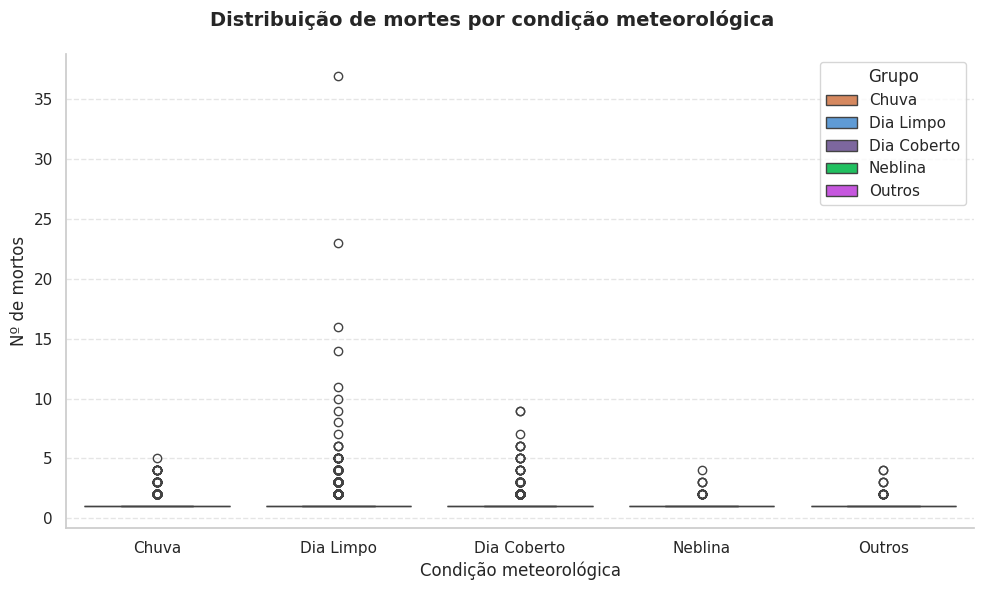

In [177]:
t1_fig1, t1_ax1 = plt.subplots(figsize=(10, 6))
t1_fig1.suptitle(
    "Distribuição de mortes por condição meteorológica",
    fontsize=14, fontweight="bold",
)

sns.boxplot(
    data=df_viz,
    x="grupo",
    y="mortos",
    hue="grupo",
    order=GRUPOS_ORDEM_T1,
    hue_order=GRUPOS_ORDEM_T1,
    palette=PALETTE,
    legend=True,
    ax=t1_ax1,
)

t1_ax1.set_xlabel("Condição meteorológica")
t1_ax1.set_ylabel("Nº de mortos")
# t1_ax1.set_yscale("log")
t1_ax1.legend(title="Grupo", frameon=True, edgecolor="#cccccc")
style_ax(t1_ax1)
t1_fig1.tight_layout()

Porém, analisando a distribuição do número de mortes por condição meteorológica no momento do acidente, providenciado pelo boxplot, temos uma imagem curiosa, que refuta o resultado do teste. Mas, antes de falarmos disso, falemos do outro ponto que chama atenção: Não é comum termos grandes números de mortes em acidentes, com a quase totalidade dos acidentes acarretando na morte de apenas uma pessoa. Todos os outros números são tratados como outliers.

Agora, sobre a divergência entre a imagem e o resultado do teste Anova. Chama atenção que apesar do teste ter mostrado que o fator chuva aumenta o número de fatalidades, na distribuição do boxplot, vemos que dias limpos, com sol e céu claro, são o que concentram os números mais elevados de fatalidades, chegando a ultrapassar mais de 10 mortes em alguns casos. Já as chuvas, apesar de causarem um aumento no número de mortes que supera a condição de neblina, por exemplo, não supera os dias limpos ou encobertos.

Talvez o teste Anova tenha sido utilizado de forma errada para analisar essa hipótese, e uma análise que compara isoladamente cada um dos fatores climáticos se provasse mais acertiva, já que, ao colocarmos todos os fatores climáticos na balança, no fim, a hipótese que estamos testando é: "Fatores climáticos contra Dias limpos".

### T2: Fatores climáticos contribuem mais para o aumento de fatalidades em acidentes do que outros fatores, tais como, época do ano e fins de semana

* H0: Fatores climáticos NÃO são o maior contribuinte para o aumento de acidentes, quando comparados com época do ano e fins de semana.
* H1: Fatores climáticos são o maior contribuinte para o aumento de acidentes, quando comparados com época do ano e fins de semana.

O tempo não é o único fator que pode contribuir para o aumento no número de acidentes, durante feriados, fins de semana, muitas pessoas saem viajar e pegam as rodovias, o que aumenta o fluxo de veículos e a chance de acidentes. Mas, qual fator será que contribuí mais?

Para esse teste, iremos comparar acidentes que ocorreram sob condições climáticas que podem aumentar a chance de ocorrem fatalidades, como Chuva, Neblina e Neve (apesar de no Brasil não ser nenhum um pouco comum), com aqueles que ocorreram em fins de semana, feriados e feriados prolongados.

Como um acidente pode ocorrer sob chuva e em um fim de semana, feriados prolongados automaticamente implicam em considerar o fim de semana também, um mesmo acidente poderá estar em mais de um conjunto.

In [178]:
df_t2 = df_acidentes.copy()

mask_mortos_t2 = df_t2['teve_mortos']
mask_fim_de_semana = (mask_mortos_t2 & df_t2['e_fim_de_semana'])
mask_fatores_climaticos = (mask_mortos_t2 & df_t2['condicao_metereologica'].isin(['Chuva', 'Nevoeiro/Neblina', 'Neve']))
mask_feriados = (mask_mortos_t2 & df_t2['e_feriado'])
mask_feriados_prolongados = (mask_mortos_t2 & df_t2['em_feriado_prolongado'])


In [179]:

df_fim_de_semana = df_t2[mask_fim_de_semana]['mortos']
df_fatores_climaticos = df_t2[mask_fatores_climaticos]['mortos']
df_feriados = df_t2[mask_feriados]['mortos']
df_feriados_prolongados = df_t2[mask_feriados_prolongados]['mortos']

In [180]:
print("Número de acidentes por período:")
print(f"n Total: {len(df_t2[mask_mortos_t2])}")
print(f"n (Fim de semana):  {len(df_fim_de_semana)}")
print(f"n (Fatores climáticos):  {len(df_fatores_climaticos)}")
print(f"n (Feriados):  {len(df_feriados)}")
print(f"n (Feriados prolongados):  {len(df_feriados_prolongados)}")

Número de acidentes por período:
n Total: 10432
n (Fim de semana):  3931
n (Fatores climáticos):  995
n (Feriados):  353
n (Feriados prolongados):  360


Como estamos comparando várias categorias, novamente será realizado o teste Anova.

In [181]:
stat_t2, p_t2 = f_oneway(df_fatores_climaticos, df_fim_de_semana, df_feriados, df_feriados_prolongados, equal_var=True, nan_policy="raise")
print(f"\n[ANOVA] Estatística F: {stat_t2:.2f}, p-valor: {p_t2:.4f}")


[ANOVA] Estatística F: 0.70, p-valor: 0.5519


Com o resultado do teste, p - 0,1498 > alfa = 0.05, não rejeitamos $H_0$, mostrando que, quando se fala no aumento das fatalidades, fatores climáticos não são o fator que mais contribuí.

In [182]:
GRUPO_T2_MAP = {
    "Fatores climáticos": mask_fatores_climaticos,
    "Fim de semana": mask_fim_de_semana,
    "Feriados": mask_feriados,
    "Feriados prolongados": mask_feriados_prolongados,
}

# Adiciona coluna de grupo ao dataframe filtrado
df_t2["grupo"] = None
for label, mask in GRUPO_T2_MAP.items():
    df_t2.loc[mask, "grupo"] = label

df_viz_t2 = df_t2[df_t2["grupo"].notna()].copy()

# Paleta e ordem fixos para consistência entre gráficos
GRUPOS_ORDEM_T2 = list(GRUPO_T2_MAP.keys())
PALETTE = {
    GRUPOS_ORDEM_T2[0]: "#7B5EA7",   # roxo  → fatores climaticos
    GRUPOS_ORDEM_T2[1]: "#4C9BE8",   # azul  → fim de semana
    GRUPOS_ORDEM_T2[2]: "#E8824C",   # laranja → feriados
    GRUPOS_ORDEM_T2[3]: "#06DA5B",   # verde → feriados prolongados
}



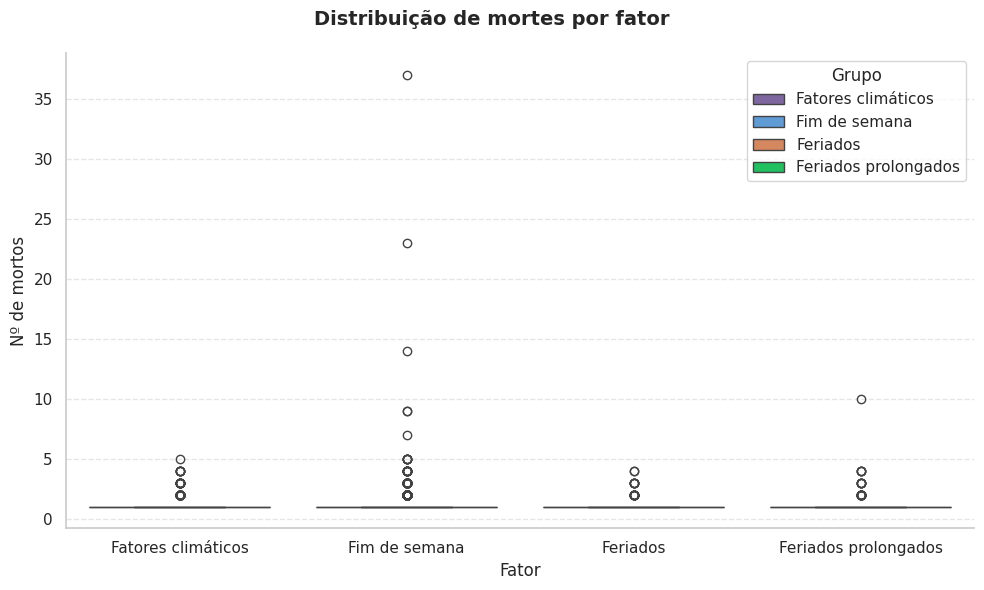

In [183]:
t2_fig1, t2_ax1 = plt.subplots(figsize=(10, 6))
t2_fig1.suptitle(
    "Distribuição de mortes por fator",
    fontsize=14, fontweight="bold",
)

sns.boxplot(
    data=df_viz_t2,
    x="grupo",
    y="mortos",
    hue="grupo",
    order=GRUPOS_ORDEM_T2,
    hue_order=GRUPOS_ORDEM_T2,
    palette=PALETTE,
    legend=True,
    ax=t2_ax1,
)

t2_ax1.set_xlabel("Fator")
t2_ax1.set_ylabel("Nº de mortos")
# t2_ax1.set_yscale("log")
t2_ax1.legend(title="Grupo", frameon=True, edgecolor="#cccccc")
style_ax(t2_ax1)
t2_fig1.tight_layout()

Olhando a distribuição do número de mortes por fator, fornecida pelo Boxplot, percebe-se que novamente o número de fatalidades na maioria dos acidentes não é expressivamente alta, ocorrendo geralmente uma única morte, com os outros valores sendo outliers.

Já quando se fala do fator mais determinante, percebe-se que, apesar de fatores climáticos certamente terem uma influência, os fins de semana são o fator mais determinante, com acidentes ceifando mais de 10, 20, 35 vidas.

A maior surprese, para mim, são os feriados, que possuem a distribuição mais "comportada", com os outliers não superando cinco mortes. Uma hipótese que podemos levantar é que, em um feriado, as pessoas geralmente viajam para aproveitá-lo em algum local, com elas já tendo chegado ao destino nesse dia, com os acidentes ocorrendo durante o deslocamento, que cairá ou num fim de semana, ou num feriado prolongado.

### T3: Feriados, normais e prolongados, contribuem para o aumento da quantidade de fatalidades em acidentes, quando comparados a dias da semana e fins de semana sem feriados

* H0: Feriados, normais e prolongados, NÃO contribuem para o aumento de acidentes na fatalidade do número de acidentes, quando comparados a dias da semana e fins de semana sem feriados
* H1: Feriados, normais e prolongados, contribuinte para o aumento de acidentes na fatalidade do número de acidentes, quando comparados a dias da semana e fins de semana sem feriados


Durante feriados, muitas pessoas pegam a estrada e viajam, o que aumente o fluxo de veículos nas rodovias. Então, é natural supormos que durante esses períodos, a chance de acidentes e o número de fatalidades nas rodovias do país aumente.

Então, para o teste, iremos comparar as seguintes categorias:
* Fim de Semana: Acidentes que ocorreram em fins de semana que não foram feriados prolongados.
* Feriados: Acidentes que ocorreram durante feriados, ou feriados prolongados.
* Dia Comum: Acidentes que não ocorreram em fins de semana, ou feriados, ou feriados prolongados.

In [184]:
df_t3 = df_acidentes.copy()

mask_mortos_t3 = df_t3['teve_mortos']
mask_fim_de_semana_t3 = (mask_mortos_t3 & df_t3['e_fim_de_semana'] & ~df_t3['em_feriado_prolongado'])
mask_feriados_t3 = (mask_mortos_t3 & (df_t3['e_feriado'] | df_t3['em_feriado_prolongado']))
mask_dia_comum_t3 = (mask_mortos_t3 & ~df_t3['e_fim_de_semana'] & ~df_t3['e_feriado'] & ~df_t3['em_feriado_prolongado'])


In [185]:

df_fim_de_semana_t3 = df_t3[mask_fim_de_semana_t3]['mortos']
df_feriados_t3 = df_t3[mask_feriados_t3]['mortos']
df_dia_comum_t3 = df_t3[mask_dia_comum_t3]['mortos']

In [186]:
print("Número de acidentes por período:")
print(f"n Total: {len(df_t3[mask_mortos_t3])}")
print(f"n (Fim de semana):  {len(df_fim_de_semana_t3)}")
print(f"n (Feriados):  {len(df_feriados_t3)}")
print(f"n (Dia comum):  {len(df_dia_comum_t3)}")

Número de acidentes por período:
n Total: 10432
n (Fim de semana):  3743
n (Feriados):  579
n (Dia comum):  6266


Como estamos comparando três categorias distintas, novamente será realizado um teste Anova.

In [187]:
stat_t3, p_t3 = f_oneway(df_feriados_t3, df_dia_comum_t3, df_fim_de_semana_t3, equal_var=True, nan_policy="raise")
print(f"\n[ANOVA] Estatística F: {stat_t3:.2f}, p-valor: {p_t3:.4f}")


[ANOVA] Estatística F: 0.58, p-valor: 0.5589


Pelo valor do teste, p = 0.2223 > alfa = 0.05, não rejeitamos a hipótese $H_0$, então feriados não são o fator que mais contribuem para o aumento no número de fatalidades.

In [188]:
GRUPO_T3_MAP = {
    "Fim de semana": mask_fim_de_semana_t3,
    "Feriados": mask_feriados_t3,
    "Dia comum": mask_dia_comum_t3,
}

# Adiciona coluna de grupo ao dataframe filtrado
df_t3["grupo"] = None
for label, mask in GRUPO_T3_MAP.items():
    df_t3.loc[mask, "grupo"] = label

df_viz_t3 = df_t3[df_t3["grupo"].notna()].copy()

# Paleta e ordem fixos para consistência entre gráficos
GRUPOS_ORDEM_T3 = list(GRUPO_T3_MAP.keys())
PALETTE = {
    GRUPOS_ORDEM_T3[0]: "#4C9BE8",   # azul  → feriados normais e prolongados
    GRUPOS_ORDEM_T3[1]: "#7B5EA7",   # roxo  → Fim de semana sem feriado prolongado
    GRUPOS_ORDEM_T3[2]: "#E8824C",   # laranja → dias comuns
}



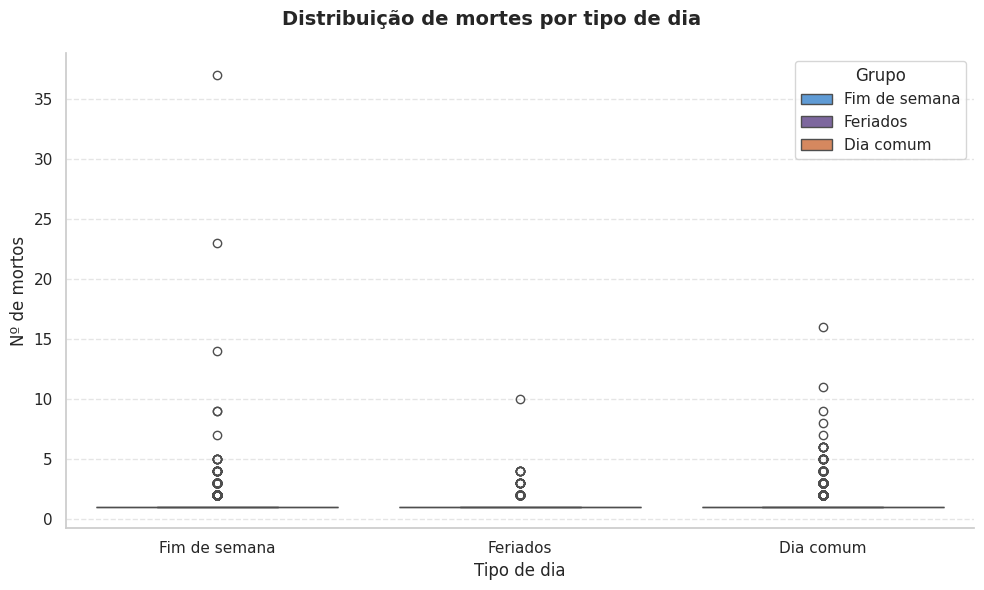

In [189]:
t3_fig1, t3_ax1 = plt.subplots(figsize=(10, 6))
t3_fig1.suptitle(
    "Distribuição de mortes por tipo de dia",
    fontsize=14, fontweight="bold",
)

sns.boxplot(
    data=df_viz_t3,
    x="grupo",
    y="mortos",
    hue="grupo",
    order=GRUPOS_ORDEM_T3,
    hue_order=GRUPOS_ORDEM_T3,
    palette=PALETTE,
    legend=True,
    ax=t3_ax1,
)

t3_ax1.set_xlabel("Tipo de dia")
t3_ax1.set_ylabel("Nº de mortos")
# t3_ax1.set_yscale("log")
t3_ax1.legend(title="Grupo", frameon=True, edgecolor="#cccccc")
style_ax(t3_ax1)
t3_fig1.tight_layout()

Pela distribuição do boxplot, percebemos que os fins de semana, sem feriados prolongados, são o fator que mais teve acidentes com causalidades, superando em muito, os feriados, que ficam atrás até dos dias comuns.

## Insights para a etapa 4

Analisando como os diferentes fatores afetam o número de mortes nos acidentes, percebe-se que considerar a variável `e_fim_de_semana` pode ajudar em muito a classificação correta da fatalidade no acidente, já que, nos três testes, esse é o fator que mais se destaca, em relação a todos os outros.

# Etapa 4

## Preparação dos experimentos

Para testar o desempenho do dataset sem nenhum pré-processamento mais intensivo e integração com fontes externas, será criado um **baseline** com dropna.

In [190]:
for c in df_acidentes.columns.tolist():
    print(df_acidentes[c].isna().sum(), c)

0 id
0 data_inversa
0 dia_semana
0 horario
0 uf
0 br
0 km
0 municipio
0 causa_acidente
0 tipo_acidente
2 classificacao_acidente
0 fase_dia
0 sentido_via
0 condicao_metereologica
0 tipo_pista
0 tracado_via
0 uso_solo
0 pessoas
0 mortos
0 feridos_leves
0 feridos_graves
0 ilesos
0 ignorados
0 feridos
0 veiculos
0 latitude
0 longitude
5 regional
58 delegacia
150 uop
0 teve_mortos
0 teve_feridos_leves
0 teve_feridos_graves
0 teve_ilesos
0 teve_feridos
0 teve_ignorados
0 e_fim_de_semana
0 e_feriado
0 em_feriado_prolongado
0 estacao_mais_proxima
0 precimitacao_momento


Como o dataset já possuía a maioria de suas linhas preenchidas completamente, e a coluna de precipitação sofreu uma tratativa para, caso a estação mais próxima estivesse inoperante no momento do acidente, zerar o valor da precipitação, com exceção de algumas linhas que não possuem regionais, delegacias e uop, que correspondem a uma porcentagem mínima do total, optou-se por remover essas linhas com dropna.

Para a baseline não usaremos todas as colunas, pois, existem colunas nativas do dataset de sinistros que entregam para o modelo se houve mortes ou não: `classificacao_acidente`, `mortos` e `teve_mortos`. Existem outras colunas que são contribuem de forma significativa para o processo de classificação, na minha visão, `delegacia`,  `uop`, pois, são colunas de critério mais informacional. 



In [191]:
BASELINE_IGNORED_COLUMNS = [
        "id",
        "classificacao_acidente",
        "mortos",
        "delegacia",
        "uop",
        "teve_mortos",
        "teve_feridos_leves",
        "teve_feridos_graves",
        "teve_ilesos",
        "teve_feridos",
        "teve_ignorados",
        "feridos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
        "e_feriado",
        "em_feriado_prolongado",
        "e_fim_de_semana",
    ]


As colunas `e_feriado`, `em_feriado_prolongado` e `e_fim_de_semana`, como reveladas pela Etapa 3, podem serem pontos muito discriminantes no que diz respeito a revelar se um acidente foi fatal ou não, então, o próximo experimento após a baseline será testar como essas colunas interferem no desempenho dos modelos.

In [192]:
EXPERIMENTO_PERIODOS_ESPECIAIS_IGNORED_COLUMNS = [
        "id",
        "classificacao_acidente",
        "mortos",
        "delegacia",
        "uop",
        "teve_mortos",
        "teve_feridos_leves",
        "teve_feridos_graves",
        "teve_ilesos",
        "teve_feridos",
        "teve_ignorados",
        "feridos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
    ]

Já as colunas que possuem informações sobre feridos, são provavelmente fonte de informação valiosa para o modelo, `teve_feridos_leves`, `teve_feridos_graves`, `teve_ilesos`, `teve_feridos`, `teve_ignorados`, `feridos`, `feridos_leves`, `feridos_graves` e `ilesos`. De forma lógica, quanto mais feridos houve em um acidente, maior a probabilidade de alguém ter morrido. Por isso, elas serão ignoradas na baseline, sendo adicionadas somente no final. Porém, isso será feito em dois estágios. No primeiro estágio, teremos somente as colunas boolenas criadas no pré-processamento. No segundo, serão consideradas as colunas nativas do próprio dataset, seja em apoio as colunas booleanas ou de forma isolada, vai depender do resultado da primeira.

In [193]:
EXPERIMENTO_GRAVIDADE_IGNORED_COLUMNS_I = [
        "id",
        "classificacao_acidente",
        "mortos",
        "delegacia",
        "uop",
        "teve_mortos",
        "feridos",
        "feridos_leves",
        "feridos_graves",
        "ilesos"
    ]

EXPERIMENTO_GRAVIDADE_IGNORED_COLUMNS_II = [
    "id",
    "classificacao_acidente",
    "mortos",
    "delegacia",
    "uop",
    "teve_mortos",
    "teve_feridos_leves",
    "teve_feridos_graves",
    "teve_ilesos",
    "teve_feridos",
    "teve_ignorados"
]

EXPERIMENTO_GRAVIDADE_IGNORED_COLUMNS_III = [
    "id",
    "classificacao_acidente",
    "mortos",
    "delegacia",
    "uop",
]

Em resumo, nossos experimentos serão:
* **Baseline**
* **Períodos especiais**
* **Gravidade booleana**
* **Gravidade original**
* **Gravidade combinada**, se necessário

### Coletas de resultados

Em relação a coleta de resultados, para facilitar o entendimento do código, serão criados alguns tipos customizados para mapear como os resultados são mapeados.

In [194]:
from typing import TypedDict, TypeAlias, Literal

class MetricBreakdown(TypedDict):
    macro: float
    weighted: float
    com_mortes: float
    sem_mortes: float

class FoldMetrics(TypedDict):
    accuracy: float
    f1: MetricBreakdown
    precision: MetricBreakdown
    recall: MetricBreakdown
    confusion_matrix: list[list[int]]

class AggregatedMetrics(TypedDict):
    accuracy: float
    f1: MetricBreakdown
    precision: MetricBreakdown
    recall: MetricBreakdown

ClassifierGeneralMetrics: TypeAlias = tuple[
    float,
    MetricBreakdown,
    MetricBreakdown,
    MetricBreakdown,
]

class ModelRunResult(TypedDict):
    folds: list[FoldMetrics]
    accuracy: float
    f1: MetricBreakdown
    precision: MetricBreakdown
    recall: MetricBreakdown

class ClassificationResults(TypedDict):
    knn: ModelRunResult
    random_forest: ModelRunResult
    svm: ModelRunResult

class DropnaRunSummary(TypedDict):
    key: str
    strategy: Literal["baseline"]
    variant: str
    rows_original: int
    rows_after_prepros: int
    results: ClassificationResults

class DropnaRunError(TypedDict):
    key: str
    error: str

## Sobre os modelos

Para ter uma noção melhor do desempenho do modelo, será utilizada a abordagem de **Validação Cruzada em K Partições**, onde, divide-se os dados em K partições, que cria uma combinação onde uma partição é o teste, e as outras `K-1` são os dados de treino, trocando a cada iteração a partição de teste por uma que ainda não foi usada para esse fim, até esgotar as combinações. Com essa abordagem, garante-se que o modelo será avaliado na totalidade dos dados, prevenindo que o teste seja feito em cima de dados que, por coincidência sejam muito difíceis ou muito fáceis.

In [195]:
def split_data_in_folds(data, k_folds=5, random_state=42):
    """Divide os dados em k folds para validação cruzada."""
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    (X, y) = data

    folds = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        folds.append((X_train, y_train, X_test, y_test))

    return folds


Sobre os modelos a serem utilizados, a ideia inicial era utilizar os seguintes modelos:
* `KNN`
* `SVM`
* `Random Forest`

Já trabalhei com o KNN e o SVM no meu TCC, então, estão muito familiarizados com eles. Porém, infelizmente minha máquina que tenho em casa não suporta utilizá-los para esse dataset, no volume de dados que estou trabalhando. A memória acaba.

Esse problema de memória se deve principalmente ao KNN, que tem que calcular as distâncias para todos os dados e armazená-los na memória.

Então, como não sou conhecedor de outros modelos, me aconselhando com algumas IAs para encontrar substitutos que minha máquina suporta, cheguei na seguinte configuração final de modelos para esse trabalho:
* `SGD`
* `LSVM`
* `Random Forest`

O **SGD, Gradiente Descendente Estocástico,** é um algoritmo de otimização, não um modelo em si. A ideia central é minimizar uma função de perda atualizando os pesos do modelo um exemplo por vez (ou em pequenos lotes), ao invés de usar o dataset inteiro a cada iteração. Isso o torna muito eficiente em memória e rápido em dados grandes.

O comportamento final depende da função de perda escolhida, onde `loss ="hinge"` faz ele se comportar como um SVM linear, e `loss="log_loss"` como uma Regressão Logística. O parâmetro `alpha` controla a regularização, evitando que o modelo decorе o treino.

Para o tunamento dos modelos, iremos tunar o `ALPHA` e o `LOSS`. O `class_weight` será fixo para garantir que ocorra um balanceamento proporcional a quantidade de elementos com mortes e sem mortes, com o último sendo muito superior em quantidade.


In [196]:
SGD_ALPHA = [1e-4, 1e-3, 1e-2]
SGB_LOSS = ["hinge", "log_loss"]
SGB_CLASS_WEIGHT = ["balanced"]
SGB_LABEL = "sgb"
SGB_PARAMETERS = {
    f"{SGB_LABEL}__loss": SGB_LOSS,
    f"{SGB_LABEL}__alpha": SGD_ALPHA,
    f"{SGB_LABEL}__class_weight": SGB_CLASS_WEIGHT,
}


O `RandomForest` é um ensemble de árvores de decisão treinadas de forma independente, cada uma em uma amostra aleatória dos dados e com um subconjunto aleatório das features. A predição final é feita por votação majoritária entre todas as árvores.

A aleatoriedade na construção é o que torna o modelo robusto, árvores individuais tendem a overfittar, mas a média de muitas árvores diversas generaliza bem. `max_depth` controla a complexidade de cada árvore , `n_estimators` o número de árvores na floresta e `class_weight` cumpre o papel de balanceador entre as classes, sendo novamente fixo, enquanto os outros dois serão tunados. 

O algoritmo possuí muitos outros parâmetros que podem serem tunados, porém, por experiência própria do meu TCC, onde descartei esse algoritmo por sua execução, mesmo nos testes locais, demorar mais de hora sem processar uma única fold se quer, vou tuná-lo o mínimo possível, pois, sei que ele demora e infelizmente, não posso deixar minha máquina pessoal ociosa pelo tempo que ele exige.

In [197]:


RF_N_ESTIMATORS = [100, 200]
RF_MAX_DEPTHS = [None, 3, 8]
RF_CLASS_WEIGHT = ["balanced_subsample"]
RF_LABEL = "rf"
RF_PARAMETERS = {
    f"{RF_LABEL}__n_estimators": RF_N_ESTIMATORS,
    f"{RF_LABEL}__max_depth": RF_MAX_DEPTHS,
    f"{RF_LABEL}__class_weight": RF_CLASS_WEIGHT,
}

O SVM busca encontrar o hiperplano que maximiza a margem entre as duas classes, ou seja, a fronteira de decisão que fica o mais distante possível dos exemplos mais próximos de cada classe (os vetores de suporte). A versão linear assume que essa fronteira é uma reta (ou hiperplano em alta dimensão).

O parâmetro `C` controla o trade-off: `C` pequeno prioriza uma margem maior, aceitando alguns erros de classificação; `C` grande tenta classificar tudo certo, mas com margem menor e mais risco de overfitting. `max_iter` controla por quantas iterações o modelo executará até parar de tentar convergir.

Sei que uma reta, ou hiperplano, não é a melhor escolha quando falamos de separar classes em planos N-Dimensionais, existindo kernels da SVM muito melhores, como o RBF, que são mais "criativos" na hora de separar os dados. Porém, por limitações da minha máquina, optei pela versão linear.

In [198]:


LSVC_C = [0.01, 0.1, 1, 10]
LSVC_MAX_ITER = [1000, 2000, 5000]
LSVC_LABEL = "lsvc"
LSVC_PARAMETERS = {
    f"{LSVC_LABEL}__C": LSVC_C,
    f"{LSVC_LABEL}__max_iter": LSVC_MAX_ITER,
}


A tunagem dos modelos se dará através de um pipeline que realiza um pré-processamento básico nos dados, aplicando `StandardScaler` nos valores numéricos e `OneHotEncoding` nos valores categóricos.

Para o `SGB` e o `SVM` iremos tentar sempre encontrar o melhor conjunto de parâmetros possíveis, via `GridSearchCV`. Para o RandomForest, pelo motivo de eu conhecer sua demora, iremos usar RandomizedSearchCV, a fim de não explorar todas as possibilidades possíveis e minimizar um pouco seu tempo de execução.

In [199]:


def tune_classifier(
    classifier, classifier_label, parameters, preprocessor, cv="grid", random_state=42
):

    pipe = Pipeline(
        [
            ("preprocess", preprocessor),
            (classifier_label, classifier),
        ]
    )

    if cv == "random":
        tuned_model = RandomizedSearchCV(
            pipe, 
            parameters, 
            n_iter=10,
            cv=3,
            n_jobs=-1, 
            random_state=random_state,
            error_score="raise",
        )
    else:
        tuned_model = GridSearchCV(pipe, parameters, n_jobs=-1)

    return tuned_model

## Sobre as métricas de avaliação

In [200]:
def build_preprocessor_baseline(
    X: pd.DataFrame, scale_numeric: bool
) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [column for column in X.columns if column not in numeric_cols]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler() if scale_numeric else "passthrough", numeric_cols),
            ("cat", make_one_hot_encoder(), categorical_cols),
        ],
        remainder="drop",
    )

Para avaliar os modelos, serão consideradas as seguintes métricas de avaliação:
* **Accuracy:** Mede quantos acertos o modelo obteve
* **Precision:** Mede a qualidade da previsão positiva, no caso desse experimento significa: "Dos acidentes classificados como tendo mortes, quantos efetivamente foram classificados corretamente"?
* **Recall:** Mede, dentre todos os casos que são da classe de interesse, quantos o modelo efetivamente acertou. No caso desse experimento, mede: "Dentre todos os acidentes com mortes, quantos casos o modelo efetivamente acertou?"
* **F1-Score:** É uma métrica que resume `precision` e `recall`, de forma que se aproxima mais da métrica com pior score, mesmo que a outra métrica tenha valor alto.

Para esse experimento, as duas métricas que devem serem analisadas com atenção maior são o `Recall` e o `F1-Score`, pois, o interesse é em criar um modelo que, através do contexto em que um acidente ocorreu, desconsiderando a gravidade, num primeiro momento, classifique corretamente quais casos resultaram em morte, auxiliando a indicar quais rodovias precisam de uma intervenção mais imediata e em qual contexto.

Tirando a accuracy, as outras métricas possuem as seguintes variações:
* `macro`: Simplifica o cálculo, dando peso igual a cada classe.
* `weighted`: Balanceia o cálculo atribuindo peso proporcional aos exemplares da classe.
* `binary`: Retorna a métrica da classe em específico, no nosso caso `sem_mortes (0|False)` e `com_mortes (1|True)`.

Nosso objetivo é maximizar o `recall` e o `f1-score` de ambas as classes, principalmente da classe `com_mortes`.

Como estamos usando a técnica de Validação Cruzada, essas métricas serão coletadas na execução de cada uma das folds, e seu valor final será a média das execuções de todas as folds.

In [201]:
DATASET = "dataset_final"
TARGET = "teve_mortos"
OUT_DIR = "data"
K_FOLDS = 5
RANDOM_STATE = 42

In [202]:


def compute_classifier_general_metrics(
    fold_metrics: list[FoldMetrics],
    k_folds: int,
) -> ClassifierGeneralMetrics:
    """
    Computa a média das métricas de classificação (accuracy, f1, precision, recall) a partir dos resultados de cada fold.
    """

    accuracy_sum = 0

    f1_sum = {
        "macro": 0,
        "weighted": 0,
        "com_mortes": 0,
        "sem_mortes": 0,
    }
    precision_sum = {
        "macro": 0,
        "weighted": 0,
        "com_mortes": 0,
        "sem_mortes": 0,
    }
    recall_sum = {
        "macro": 0,
        "weighted": 0,
        "com_mortes": 0,
        "sem_mortes": 0,
    }
    for fold_metric in fold_metrics:
        accuracy_sum += fold_metric["accuracy"]

        f1_sum["macro"] += fold_metric["f1"]["macro"]
        f1_sum["weighted"] += fold_metric["f1"]["weighted"]
        f1_sum["com_mortes"] += fold_metric["f1"]["com_mortes"]
        f1_sum["sem_mortes"] += fold_metric["f1"]["sem_mortes"]

        precision_sum["macro"] += fold_metric["precision"]["macro"]
        precision_sum["weighted"] += fold_metric["precision"]["weighted"]
        precision_sum["com_mortes"] += fold_metric["precision"]["com_mortes"]
        precision_sum["sem_mortes"] += fold_metric["precision"]["sem_mortes"]

        recall_sum["macro"] += fold_metric["recall"]["macro"]
        recall_sum["weighted"] += fold_metric["recall"]["weighted"]
        recall_sum["com_mortes"] += fold_metric["recall"]["com_mortes"]
        recall_sum["sem_mortes"] += fold_metric["recall"]["sem_mortes"]

    accuracy = accuracy_sum / k_folds
    f1 = {
        "macro": f1_sum["macro"] / k_folds,
        "weighted": f1_sum["weighted"] / k_folds,
        "com_mortes": f1_sum["com_mortes"] / k_folds,
        "sem_mortes": f1_sum["sem_mortes"] / k_folds,
    }
    precision = {
        "macro": precision_sum["macro"] / k_folds,
        "weighted": precision_sum["weighted"] / k_folds,
        "com_mortes": precision_sum["com_mortes"] / k_folds,
        "sem_mortes": precision_sum["sem_mortes"] / k_folds,
    }
    recall = {
        "macro": recall_sum["macro"] / k_folds,
        "weighted": recall_sum["weighted"] / k_folds,
        "com_mortes": recall_sum["com_mortes"] / k_folds,
        "sem_mortes": recall_sum["sem_mortes"] / k_folds,
    }

    return accuracy, f1, precision, recall


def run_classification(
    X: pd.DataFrame,
    y: pd.Series,
    k_folds: int,
    random_state: int,
    result_dir: str,
    base_filename: str,
) -> ClassificationResults:

    folds = split_data_in_folds((X, y), k_folds=k_folds, random_state=random_state)

    results = {
        f"{SGB_LABEL}": {"folds": []},
        f"{RF_LABEL}": {"folds": []},
        f"{LSVC_LABEL}": {"folds": []},
    }

    models = {
        f"{SGB_LABEL}": (
            SGDClassifier(random_state=random_state),
            SGB_LABEL,
            SGB_PARAMETERS,
            True,
        ),
        f"{LSVC_LABEL}": (
            LinearSVC(random_state=random_state, class_weight="balanced"),
            LSVC_LABEL,
            LSVC_PARAMETERS,
            True,
        ),
        f"{RF_LABEL}": (
            RandomForestClassifier(random_state=random_state, n_jobs=-1),
            RF_LABEL,
            RF_PARAMETERS,
            False,
        ),
    }

    result_path = Path(result_dir)

    for name, (classifier, label, parameters, scale_numeric) in models.items():
        model_cache_path = result_path / f"{base_filename}_{name}_results.json"

        # Cache por modelo — se já existe, carrega e pula
        if model_cache_path.exists():
            print(f"Cache encontrado para modelo '{name}', carregando de {model_cache_path}")
            cached = json.loads(model_cache_path.read_text(encoding="utf-8"))
            results[name] = cached
            continue

        print(f"\n{'='*50}")
        print(f"Iniciando modelo: {name}")
        print(f"{'='*50}")

        for fold_index, (X_train, y_train, X_test, y_test) in enumerate(folds):
            print(f"\nTreinando modelo {name} na fold {fold_index}...")

            if label == RF_LABEL:
                model = tune_classifier(
                    classifier,
                    label,
                    parameters,
                    build_preprocessor_baseline(X_train, scale_numeric=scale_numeric),
                    cv="random",
                    random_state=random_state,
                )
            else:
                model = tune_classifier(
                    classifier,
                    label,
                    parameters,
                    build_preprocessor_baseline(X_train, scale_numeric=scale_numeric),
                )

            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            accuracy = float(accuracy_score(y_test, pred))
            macro_f1 = float(f1_score(y_test, pred, average="macro"))
            macro_precision = float(precision_score(y_test, pred, average="macro"))
            macro_recall = float(recall_score(y_test, pred, average="macro"))
            weighted_f1 = float(f1_score(y_test, pred, average="weighted"))
            weighted_precision = float(precision_score(y_test, pred, average="weighted"))
            weighted_recall = float(recall_score(y_test, pred, average="weighted"))
            sem_mortes_f1 = float(f1_score(y_test, pred, average="binary", pos_label=0))
            com_mortes_f1 = float(f1_score(y_test, pred, average="binary", pos_label=1))
            sem_mortes_precision = float(precision_score(y_test, pred, average="binary", pos_label=0))
            com_mortes_precision = float(precision_score(y_test, pred, average="binary", pos_label=1))
            sem_mortes_recall = float(recall_score(y_test, pred, average="binary", pos_label=0))
            com_mortes_recall = float(recall_score(y_test, pred, average="binary", pos_label=1))

            confusion_matrix_data = confusion_matrix(y_test, pred)

            metrics = {
                "accuracy": accuracy,
                "f1": {
                    "macro": macro_f1,
                    "weighted": weighted_f1,
                    "sem_mortes": sem_mortes_f1,
                    "com_mortes": com_mortes_f1,
                },
                "precision": {
                    "macro": macro_precision,
                    "weighted": weighted_precision,
                    "sem_mortes": sem_mortes_precision,
                    "com_mortes": com_mortes_precision,
                },
                "recall": {
                    "macro": macro_recall,
                    "weighted": weighted_recall,
                    "sem_mortes": sem_mortes_recall,
                    "com_mortes": com_mortes_recall,
                },
                "confusion_matrix": confusion_matrix_data.tolist(),
                "best_params": model.best_params_ if hasattr(model, "best_params_") else None,
            }
            results[name]["folds"].append(metrics)

            print(f"\n[model] {name} | Fold {fold_index}")
            print(metrics)
            print("Matriz de confusao:")
            print(confusion_matrix_data)
            print(classification_report(y_test, pred))

            del model
            gc.collect()

        # Agrega métricas e salva cache do modelo
        fold_metrics = results[name]["folds"]
        accuracy, f1, precision, recall = compute_classifier_general_metrics(
            fold_metrics, k_folds
        )
        results[name]["accuracy"] = accuracy
        results[name]["f1"] = f1
        results[name]["precision"] = precision
        results[name]["recall"] = recall

        model_cache_path.write_text(
            json.dumps(results[name], indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        print(f"\n[CONCLUIDO] {name} | Salvo em {model_cache_path}")

    return results


## Execução Baseline

In [203]:

def run_one_dataset_with_baseline(
    data: pd.DataFrame,
    key: str,
    target,
    out_dir: str = "data",
    k_folds: float = 5,
    random_state: int = 42,
) -> DropnaRunSummary:
    data_dir = Path(out_dir)

    result_dir = data_dir / "results" / "baseline"
    result_dir.mkdir(parents=True, exist_ok=True)
    out_path = result_dir / f"{key}_baseline_results.json"

    # Cache — se já existe, só lê e devolve
    if out_path.exists():
        print(f"Cache encontrado para '{key}', carregando resultados de {out_path}")
        cached = json.loads(out_path.read_text(encoding="utf-8"))
        return {
            "key": cached["key"],
            "strategy": "baseline",
            "variant": cached["variant"],
            "rows_original": cached["shape_original"][0],
            "rows_after_prepros": cached["shape_after_prepro"][0],
            "results": cached["results"],
        }

    df = data.copy()

    print("\n" + "=" * 80)
    print(f"Dataset: {key} | Target: {target}")
    print("=" * 80)
    print("Shape original:", df.shape)

    df = normalize_missing_values(df)

    rows_before = len(df)
    df_clean = df.dropna(axis=0, how="any").copy()
    rows_after = len(df_clean)
    rows_dropped = rows_before - rows_after

    print(
        "Linhas removidas no dropna:",
        rows_dropped,
        f"({(rows_dropped / rows_before):.2%})",
    )

    if rows_after == 0:
        raise RuntimeError("Dataset vazio apos dropna.")

    X, y = split_X_y(df_clean, target, BASELINE_IGNORED_COLUMNS)

    print("Distribuicao da target:")
    print(y.value_counts())

    results = run_classification(
        X, y,
        k_folds=k_folds,
        random_state=random_state,
        result_dir=str(result_dir),
        base_filename=key,
    )

    out_path.write_text(
        json.dumps(
            {
                "key": key,
                "target": target,
                "variant": "default",
                "shape_original": list(df.shape),
                "shape_after_prepro": list(df_clean.shape),
                "k_folds": k_folds,
                "random_state": random_state,
                "results": results,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )
    print("Resultados salvos em:", out_path)

    return {
        "key": key,
        "strategy": "baseline",
        "variant": "default",
        "rows_original": int(df.shape[0]),
        "rows_after_prepros": int(df_clean.shape[0]),
        "results": results,
    }

In [204]:
print(f"{'=' * 5} BASELINE {'=' * 5}")


all_runs_baseline: list[DropnaRunSummary] = []
try:
    run_info = run_one_dataset_with_baseline(
        data=df_acidentes,
        key=DATASET,
        target=TARGET,
        out_dir=OUT_DIR,
        k_folds=K_FOLDS,
        random_state=RANDOM_STATE,
    )
    all_runs_baseline.append(run_info)
except Exception as e:
    print(f"\n[ERRO] key={DATASET}: {e}")
    all_runs_baseline.append({"key": DATASET, "error": str(e)})


===== BASELINE =====
Cache encontrado para 'dataset_final', carregando resultados de data/results/baseline/dataset_final_baseline_results.json


In [205]:
CLASSIFICATION_SUMMARY_COLUMNS = [
            "experiment",
            "key",
            "variant",
            "best_model",
            "accuracy",
            "macro_f1",
            "macro_precision",
            "macro_recall",
            "nao_teve_mortes_f1",
            "nao_teve_mortes_precision",
            "nao_teve_mortes_recall",
            "teve_mortes_f1",
            "teve_mortes_precision",
            "teve_mortes_recall",
            "weighted_f1",
            "weighted_precision",
            "weighted_recall",
            "error",
        ]

def save_classification_summary(
    rows: list,
    columns: list,
    csv_path: Path,
    append: bool = False,
) -> pd.DataFrame:
    """Salva ou anexa um resumo de classificação em CSV.

    Parameters
    ----------
    rows : list
        Linhas de dados para o DataFrame.
    columns : list
        Nomes das colunas.
    csv_path : Path
        Caminho do arquivo CSV de destino.
    append : bool
        Se True, anexa ao CSV existente. Se False, sobrescreve.
    """
    if not rows:
        print("Nenhuma linha para salvar.")
        return pd.DataFrame(columns=columns)

    new_df = pd.DataFrame(rows, columns=columns)

    if append and csv_path.exists():
        existing_df = pd.read_csv(csv_path)
        final_df = pd.concat([existing_df, new_df], ignore_index=True)
        print(f"Anexando {len(new_df)} linha(s) ao CSV existente ({len(existing_df)} já salvas).")
    else:
        final_df = new_df

    print("\n=== Classificacao ===")
    display(final_df)
    final_df.to_csv(csv_path, index=False)
    print("Salvo em:", csv_path)

    return final_df

In [206]:
# --- Monta tabelas separadas por tipo de tarefa ---

classification_rows = []

for r in all_runs_baseline:
    base = {
        "experiment": "baseline",
        "key": r["key"],
        "variant": r.get("variant", "default"),
        "best_model": "",
        "error": r.get("error", ""),
    }

    if "error" in r and "results" not in r:
        classification_rows.append(
            {
                **base,
                "accuracy": None,
                "macro_f1": None,
                "weighted_f1": None,
                "weighted_precision": None,
                "weighted_recall": None,
            }
        )
        continue

    best = max(r["results"], key=lambda m: r["results"][m]["f1"]["macro"])
    m = r["results"][best]
    classification_rows.append(
        {
            "experiment": "baseline",
            "key": r["key"],
            "variant": r["variant"],
            "best_model": best,
            "accuracy": round(m["accuracy"], 4),
            "macro_f1": round(m["f1"]["macro"], 4),
            "macro_precision": round(m["precision"]["macro"], 4),
            "macro_recall": round(m["recall"]["macro"], 4),
            "weighted_f1": round(m["f1"]["weighted"], 4),
            "weighted_precision": round(m["precision"]["weighted"], 4),
            "weighted_recall": round(m["recall"]["weighted"], 4),
            "error": "",
            "nao_teve_mortes_f1": round(m["f1"]["sem_mortes"], 4),
            "nao_teve_mortes_precision": round(m["precision"]["sem_mortes"], 4),
            "nao_teve_mortes_recall": round(m["recall"]["sem_mortes"], 4),
            "teve_mortes_f1": round(m["f1"]["com_mortes"], 4),
            "teve_mortes_precision": round(m["precision"]["com_mortes"], 4),
            "teve_mortes_recall": round(m["recall"]["com_mortes"], 4),
        }
    )

# Exibe  resultados e salva CSVs


data_path = Path(OUT_DIR)

save_classification_summary(
    rows=classification_rows,
    columns=CLASSIFICATION_SUMMARY_COLUMNS,
    csv_path=data_path / "classification_summary.csv",
    append=False,
)


print(f"{'=' * 5} FIM BASELINE {'=' * 5}")


=== Classificacao ===


,experiment,key,variant,best_model,accuracy,macro_f1,macro_precision,macro_recall,nao_teve_mortes_f1,nao_teve_mortes_precision,nao_teve_mortes_recall,teve_mortes_f1,teve_mortes_precision,teve_mortes_recall,weighted_f1,weighted_precision,weighted_recall,error
0,baseline,dataset_final,default,sgb,0.8715,0.651,0.6244,0.7164,0.9284,0.9616,0.8974,0.3737,0.2873,0.5354,0.8887,0.9133,0.8715,


Salvo em: data/classification_summary.csv
===== FIM BASELINE =====


Analisando a execução da Baseline, foram classificados 145533 elementos do total de 145685, uma remoção de 152 (0.10%) elementos. Como todos os demais experimentos usarão esses mesmos dados e estratégia, não haverá alteração nesses valores.

### Desempenho SGD

Analisando o desempenho geral, sem olhar para uma fold em específico, vemos que o modelo teve uma acurácia alta, de `87,15%`, porém, ao olharmos com mais atenção, percebe-se que essa alta taxa de acerto se deve ao fato dele ser muito bom em identificar acidentes `sem_mortes`, onde o recall, f1 e precision superam 89%, enquanto o desempenho em relação ao acidentes `com_mortes`, fica muito abaixo.

Para esse modelo, a pior métrica foi a precision, com `28,72%`, mostrando que ele teve muitos falsos positivos, classificando muitos acidentes sem mortes como tendo fatalidades. Já o recall de `53,54%` mostra que, de todos os acidentes com mortes, o modelo classificou corretamente um pouco mais da metade. Esses fatores contribuíram para o f1-score extremamente baixo de `37,37%`.

Em relação ao desempenho das folds de forma isolada, não se observou nada fora do padrão revelado pelos resultados médios. O que vale destacar é que os melhores parâmetros sempre foram:
    * "sgb__alpha": 0.0001,
    * "sgb__class_weight": "balanced",
    * "sgb__loss": "hinge"

Mostrando que o comportamento do modelo se aproximou mais da SVM do que de um Regressor Linear.

Em contrapartida, a execução desse modelo foi incrivelmente rápida, compara aos outros, demorando menos de 10 minutos. E os seus resultados foram os melhores, usando o critério de `f1 macro`.

### Desempenho LSVC

Analisando o desempenho geral, sem olhar para uma fold em específico, vemos que o modelo teve uma acurácia bem alta, de `92,41%`, porém, ao olharmos com mais atenção, percebe-se que essa alta taxa de acerto se deve ao fato dele ser muito bom em identificar acidentes `sem_mortes`, assim como o SGD, onde o recall, f1 e precision para essa classe superando 93%, enquanto o desempenho em relação ao acidentes `com_mortes`, fica muito abaixo, com uma f1-score de `22,37%` evidenciando esse fato.

Para esse modelo, a pior métrica foi a recall, com `15,28%`, mostrando que de todos os acidentes `com_mortes`, ele classificou corretamente menos de um quinto deles, ao passo que para os acidentes sem_mortes, temos um recall de `98,36%`. Já a precision foi de `41,78%` para os acidentes `com_mortes`, mostrando que ele lidou melhor com os falsos positivos do que o SGD, mas, a sua qualidade da previsão positiva ainda fica abaixo do jogar de uma moeda.

Em relação ao desempenho das folds de forma isolada, não se observou nada fora do padrão revelado pelos resultados médios. Sobre os melhores parâmetros, vale destacar que:

* "lsvc__C": 10, mostrando que foi considerada uma margem suave extremamente estreita, e mesmo assim os resultados foram muito baixos.
* "lsvc__max_iter": não apresentou consistência, com cada um dos valores possíveis aparecendo pelo menos uma vez, com o mais frequente sendo 1000, depois 2000 e por fim 5000.

O desempenho do modelo mostra que os dados, do jeito que foram preparados para a Baseline, não possuem uma boa separabilidade linear, não sendo possível identificar com clareza um bom separador entre as classes.

 ### Desempenho Random Forest

O Random Forest foi o modelo que mais demorou e o que teve o pior recall e f1-score. Ao olharmos sua acurácia de `92,89%` vemos que ele teve uma taxa de acerto alta, porém, ao analisarmos suas métricas mais de perto, vemos que o modelo identifica acidentes `sem_mortes`, muito bem, possuindo f1-score de `96,31%` para essa classe, mas, em contrapartida a classe `com_mortes` fica com `2,5%` de f1-score, que é explicado pelo recall de `1,27%` dessa classe.

Então, de todos os acidentes com mortes, o modelo foi capaz de identificar um pouco mais de 1% dos casos. Isso levanta a hipótese de que, não existe um conjunto de atributos cujos valores permitam diferenciar os dois tipos de acidentes de forma mais decisiva, da mesma forma que não há uma separação linear clara entre as classes.

Essa dificuldade é reforçada ao analisarmos os melhores parâmetros de cada fold, onde `max_depth = None`, indicando que o modelo percorreu a árvore de decisão inteira para dar sua resposta. 

# Execução Períodos

In [207]:

def run_one_dataset_for_periods(
    data: pd.DataFrame,
    key: str,
    target,
    out_dir: str = "data",
    k_folds: float = 5,
    random_state: int = 42,
) -> DropnaRunSummary:
    data_dir = Path(out_dir)

    result_dir = data_dir / "results" / "periodos"
    result_dir.mkdir(parents=True, exist_ok=True)
    out_path = result_dir / f"{key}_periodos_results.json"

    # Cache — se já existe, só lê e devolve
    if out_path.exists():
        print(f"Cache encontrado para '{key}', carregando resultados de {out_path}")
        cached = json.loads(out_path.read_text(encoding="utf-8"))
        return {
            "key": cached["key"],
            "strategy": "periodos",
            "variant": cached["variant"],
            "rows_original": cached["shape_original"][0],
            "rows_after_prepros": cached["shape_after_prepro"][0],
            "results": cached["results"],
        }

    df = data.copy()

    print("\n" + "=" * 80)
    print(f"Dataset: {key} | Target: {target}")
    print("=" * 80)
    print("Shape original:", df.shape)

    df = normalize_missing_values(df)

    rows_before = len(df)
    df_clean = df.dropna(axis=0, how="any").copy()
    rows_after = len(df_clean)
    rows_dropped = rows_before - rows_after

    print(
        "Linhas removidas no dropna:",
        rows_dropped,
        f"({(rows_dropped / rows_before):.2%})",
    )

    if rows_after == 0:
        raise RuntimeError("Dataset vazio apos dropna.")

    X, y = split_X_y(df_clean, target, EXPERIMENTO_PERIODOS_ESPECIAIS_IGNORED_COLUMNS)

    print("Distribuicao da target:")
    print(y.value_counts())

    results = run_classification(
        X, y,
        k_folds=k_folds,
        random_state=random_state,
        result_dir=str(result_dir),
        base_filename=key,
    )

    out_path.write_text(
        json.dumps(
            {
                "key": key,
                "target": target,
                "variant": "default",
                "shape_original": list(df.shape),
                "shape_after_prepro": list(df_clean.shape),
                "k_folds": k_folds,
                "random_state": random_state,
                "results": results,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )
    print("Resultados salvos em:", out_path)

    return {
        "key": key,
        "strategy": "periodos",
        "variant": "default",
        "rows_original": int(df.shape[0]),
        "rows_after_prepros": int(df_clean.shape[0]),
        "results": results,
    }

In [208]:
print(f"{'=' * 5} PERIODOS {'=' * 5}")


all_runs_periods: list[DropnaRunSummary] = []
try:
    run_info = run_one_dataset_for_periods(
        data=df_acidentes,
        key=DATASET,
        target=TARGET,
        out_dir=OUT_DIR,
        k_folds=K_FOLDS,
        random_state=RANDOM_STATE,
    )
    all_runs_periods.append(run_info)
except Exception as e:
    print(f"\n[ERRO] key={DATASET}: {e}")
    all_runs_periods.append({"key": DATASET, "error": str(e)})


===== PERIODOS =====
Cache encontrado para 'dataset_final', carregando resultados de data/results/periodos/dataset_final_periodos_results.json


In [209]:

classification_rows_periods = []

for r in all_runs_periods:
    base = {"experiment": "periods", "key": r["key"], "variant": r.get("variant", "default"), "best_model": "", "error": r.get("error", "")}

    if "error" in r and "results" not in r:
        classification_rows_periods.append({**base, "accuracy": None, "macro_f1": None, "weighted_f1": None, "weighted_precision": None, "weighted_recall": None})
        continue

    best = max(r["results"], key=lambda m: r["results"][m]["f1"]["macro"] )
    m = r["results"][best]
    classification_rows_periods.append({
        "experiment": "periods",
        "key": r["key"],
        "variant": r["variant"],
        "best_model": best,
        "accuracy": round(m["accuracy"], 4),
        "macro_f1": round(m["f1"]["macro"], 4),
        "macro_precision": round(m["precision"]["macro"], 4),
        "macro_recall": round(m["recall"]["macro"], 4),
        "weighted_f1": round(m["f1"]["weighted"], 4),
        "weighted_precision": round(m["precision"]["weighted"], 4),
        "weighted_recall": round(m["recall"]["weighted"], 4),
        "error": "",
        "nao_teve_mortes_f1": round(m["f1"]["sem_mortes"], 4),
        "nao_teve_mortes_precision": round(m["precision"]["sem_mortes"], 4),
        "nao_teve_mortes_recall": round(m["recall"]["sem_mortes"], 4),
        "teve_mortes_f1": round(m["f1"]["com_mortes"], 4),
        "teve_mortes_precision": round(m["precision"]["com_mortes"], 4),
        "teve_mortes_recall": round(m["recall"]["com_mortes"], 4),
    })

# Exibe  resultados e salva CSVs 


save_classification_summary(
    rows=classification_rows_periods,
    columns=CLASSIFICATION_SUMMARY_COLUMNS,
    csv_path=data_path / "classification_summary.csv",
    append=True,
)


print(f"{'=' * 5} FIM PERIODOS {'=' * 5}")

Anexando 1 linha(s) ao CSV existente (1 já salvas).

=== Classificacao ===


,experiment,key,variant,best_model,accuracy,macro_f1,macro_precision,macro_recall,nao_teve_mortes_f1,nao_teve_mortes_precision,nao_teve_mortes_recall,teve_mortes_f1,teve_mortes_precision,teve_mortes_recall,weighted_f1,weighted_precision,weighted_recall,error
0,baseline,dataset_final,default,sgb,0.8715,0.6510,0.6244,0.7164,0.9284,0.9616,0.8974,0.3737,0.2873,0.5354,0.8887,0.9133,0.8715,NaN
1,periods,dataset_final,default,sgb,0.8281,0.6211,0.6008,0.7325,0.9012,0.9665,0.8441,0.3411,0.2351,0.6210,0.8610,0.9141,0.8281,


Salvo em: data/classification_summary.csv
===== FIM PERIODOS =====


Analisando a execução do experimento de períodos, foram classificados 145533 elementos do total de 145685, uma remoção de 152 (0.10%) elementos, seguindo o que foi feito para a Baseline.

O desempenho de cada modelo, comparado com a Baseline é descrito abaixo.

### Desempenho SGD

Quando comparado ao desempenho da Baseline, o Período SGD apresentou uma leve queda em sua acurácia, caindo de `87,15%` para `82,81%`, porém, um resultado ainda elevado. 

Também observou-se uma queda nas macros do f1 e da precision, cujo os valores para a classe `com_mortes` foram respectivamente `34,10%` e `23,51%`. Em contrapartida, o recall para a classe aumentou, saindo de `53,54%` na Baseline para `62,10%`. Isso mostra que, o modelo com as novas features de periodo, apesar de sofrer um pouco mais com falsos positivos, conseguiu classificar com mais exatidão os acidentes com morte de forma geral.

Seguindo a Baseline, a pior métrica para o modelo SGD foi a precision, que sofreu uma leve queda em relação ao primeiro experimento. Já em relação as folds de forma isolada, não se observou nenhuma grande discrepância entre os desempenhos delas que mostrem que dada parte do conjunto de dados foi mais fácil ou mais difícil de se processar.

Sobre os melhores parâmetros, para todas as folds houve:
    * "sgb__alpha": 0.01,
    * "sgb__class_weight": "balanced",
    * "sgb__loss": "hinge"

Esses valores mostram que o comportamento do modelo se aproximou mais da SVM do que de um Regressor Linear, pois, o loss foi "hinge". Mas, o alpha aumentou para 0.01, em relação ao 0.0001 da Baseline, mostrando que o modelo incrementou a penalidade para o modelo durante os treinos.

Novamente ele foi o modelo mais rápido do experimento.

### Desempenho LSVC

Seguindo o que ocorreu com o modelo SGD, o LSVC apresentou uma leve queda em sua acurácia, em relação a Baseline, caindo de `92,41%` para `90,19%`. 

O modelo permaneceu muito bom em identificar acidentes não fatais, com as métricas de f1, precision e recall para essa classe sendo, respectivamente: `94,73%`, `94,46%` e `95,02%`. Em contrapartida, para a classe `com_mortes`, o resultado ainda deixa a desejar, apesar do f1-score ter aumentado de 22,37 para 28,68 em relação a baseline. Todavia, esse aumento escode que, apesar do recall ter aumentado de 15% para 27%, a precision da classe caiu de 41% para a casa dos 30%.

Nesse cenário, seguindo o SGD, o modelo melhorou em classificar de forma geral os acidentes com mortes, mas, ficou mais sensível a falsos positivos. Isso pode se dever ao fato de que, durante o fim de semana, a uma tendência natural de aumento no número de acidentes, fatais ou não, então, fazendo o modelo chutar mais.

Essa tendência maior de chutes pode ser vista ao analisarmos os melhores parâmetros das folds, onde, ao contrário da baseline, observou-se um padrão mais consistente:
* "lsvc__C": 1, mostrando que foi considerada uma margem suave mais ampla, o que ajuda explicar o aumento no número de falsos positivos.
* "lsvc__max_iter": 1000 em 4 das 5 folds, mostrando que o modelo tendeu a convergir mais rápido no resultado.

De forma geral, como o recall aumentou, a separabilidade linear entre as classes aumentou um pouco, porém, não o suficiente para eliminar ambiguidades, já que a margem suave mais ampla gerou um aumento no número de falsos positivos. O próximo passo seria incluir features que afastassem os elementos dessa margem, ou permitissem resultados melhores a estreitando.


 ### Desempenho Random Forest

Analisando o desempenho do modelo random forest para esse experimento em que foram adicionadas os atributos de período, percebe-se que houve uma manutenção consistente dos resultados em relação a baseline, praticamente não havendo diferença nos valores das métricas. O macro f1-score na baseline foi de 49,40. No experimento de períodos, foi 49,39. O recall para os acidentes com mortes permaneceu na casa dos 1,25% e a precision para essa classe subiu um ponto, para 70,70.

Então, vendo esses resultados, concluí-se que adicionar os atributos temporais não contribuiu  para a criação de um caminho nas árvores que permitisse distinguir entre acidentes fatais de forma determinante. Com o modelo ainda tendo que percorrer a árvore toda para dar sua resposta, já que max_depth, em todas as folds, foi null.

# Experimentos Gravidade

Originalmente o dataset contava com colunas quantitativas que indicavam o número de feridos, leves e graves, informação que para um modelo que visa classificar quais acidentes resultaram em facilidades certamente ajuda muito, já que, quanto maior a quantidade de feridos, certamente maior a chance de haver mortes.

Porém, num primeiro momento, não serão utilizados as colunas quantitativas nativas do dataset, mas, as colunas booleanas que indicam a presença desse tipo de feridos, adicionadas durante o pré-processamento.

In [210]:

def run_one_dataset_for_gravity(
    data: pd.DataFrame,
    key: str,
    target,
    gravity: Literal["i", "ii", "iii"],
    out_dir: str = "data",
    k_folds: float = 5,
    random_state: int = 42,
) -> DropnaRunSummary:
    data_dir = Path(out_dir)

    result_dir = data_dir / "results" / "gravity" / gravity
    result_dir.mkdir(parents=True, exist_ok=True)
    out_path = result_dir / f"{key}_gravity_{gravity}_results.json"

    # Cache — se já existe, só lê e devolve
    if out_path.exists():
        print(f"Cache encontrado para '{key}', carregando resultados de {out_path}")
        cached = json.loads(out_path.read_text(encoding="utf-8"))
        return {
            "key": cached["key"],
            "strategy": f"gravity_{gravity}",
            "variant": cached["variant"],
            "rows_original": cached["shape_original"][0],
            "rows_after_prepros": cached["shape_after_prepro"][0],
            "results": cached["results"],
        }

    df = data.copy()

    print("\n" + "=" * 80)
    print(f"Dataset: {key} | Target: {target}")
    print("=" * 80)
    print("Shape original:", df.shape)

    df = normalize_missing_values(df)

    rows_before = len(df)
    df_clean = df.dropna(axis=0, how="any").copy()
    rows_after = len(df_clean)
    rows_dropped = rows_before - rows_after

    print(
        "Linhas removidas no dropna:",
        rows_dropped,
        f"({(rows_dropped / rows_before):.2%})",
    )

    if rows_after == 0:
        raise RuntimeError("Dataset vazio apos dropna.")

    if gravity == "i":
        ignored_columns = EXPERIMENTO_GRAVIDADE_IGNORED_COLUMNS_I
    elif gravity == "ii":
        ignored_columns = EXPERIMENTO_GRAVIDADE_IGNORED_COLUMNS_II
    elif gravity == "iii":
        ignored_columns = EXPERIMENTO_GRAVIDADE_IGNORED_COLUMNS_III

    X, y = split_X_y(df_clean, target, ignored_columns)

    print("Distribuicao da target:")
    print(y.value_counts())

    results = run_classification(
        X, y,
        k_folds=k_folds,
        random_state=random_state,
        result_dir=str(result_dir),
        base_filename=key,
    )

    out_path.write_text(
        json.dumps(
            {
                "key": key,
                "target": target,
                "variant": gravity,
                "shape_original": list(df.shape),
                "shape_after_prepro": list(df_clean.shape),
                "k_folds": k_folds,
                "random_state": random_state,
                "results": results,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )
    print("Resultados salvos em:", out_path)

    return {
        "key": key,
        "strategy": "gravity",
        "variant": gravity,
        "rows_original": int(df.shape[0]),
        "rows_after_prepros": int(df_clean.shape[0]),
        "results": results,
    }

In [211]:
GRAVITIES_STRATEGIES = ["i", "ii", "iii"]

## I - Somente colunas booleanas de feridos

In [212]:
print(f"{'=' * 5} GRAVIDADE {GRAVITIES_STRATEGIES[0]} {'=' * 5}")


all_runs_periods_gravity_i: list[DropnaRunSummary] = []
try:
    run_info = run_one_dataset_for_gravity(
        data=df_acidentes,
        key=DATASET,
        target=TARGET,
        gravity=GRAVITIES_STRATEGIES[0],
        out_dir=OUT_DIR,
        k_folds=K_FOLDS,
        random_state=RANDOM_STATE,
    )
    all_runs_periods_gravity_i.append(run_info)
except Exception as e:
    print(f"\n[ERRO] key={DATASET}: {e}")
    all_runs_periods_gravity_i.append({"key": DATASET, "error": str(e)})


===== GRAVIDADE i =====
Cache encontrado para 'dataset_final', carregando resultados de data/results/gravity/i/dataset_final_gravity_i_results.json


In [213]:

classification_rows_gravity_i = []

for r in all_runs_periods_gravity_i:
    base = {"experiment": "gravity", "key": r["key"], "variant": r.get("variant", "default"), "best_model": "", "error": r.get("error", "")}

    if "error" in r and "results" not in r:
        classification_rows_gravity_i.append({**base, "accuracy": None, "macro_f1": None, "weighted_f1": None, "weighted_precision": None, "weighted_recall": None})
        continue

    best = max(r["results"], key=lambda m: r["results"][m]["f1"]["macro"] )
    m = r["results"][best]
    classification_rows_gravity_i.append({
        "experiment": "gravity",
        "key": r["key"],
        "variant": r["variant"],
        "best_model": best,
        "accuracy": round(m["accuracy"], 4),
        "macro_f1": round(m["f1"]["macro"], 4),
        "macro_precision": round(m["precision"]["macro"], 4),
        "macro_recall": round(m["recall"]["macro"], 4),
        "weighted_f1": round(m["f1"]["weighted"], 4),
        "weighted_precision": round(m["precision"]["weighted"], 4),
        "weighted_recall": round(m["recall"]["weighted"], 4),
        "error": "",
        "nao_teve_mortes_f1": round(m["f1"]["sem_mortes"], 4),
        "nao_teve_mortes_precision": round(m["precision"]["sem_mortes"], 4),
        "nao_teve_mortes_recall": round(m["recall"]["sem_mortes"], 4),
        "teve_mortes_f1": round(m["f1"]["com_mortes"], 4),
        "teve_mortes_precision": round(m["precision"]["com_mortes"], 4),
        "teve_mortes_recall": round(m["recall"]["com_mortes"], 4),
    })

# Exibe  resultados e salva CSVs 


save_classification_summary(
    rows=classification_rows_gravity_i,
    columns=CLASSIFICATION_SUMMARY_COLUMNS,
    csv_path=data_path / "classification_summary.csv",
    append=True,
)


print(f"{'=' * 5} FIM GRAVIDADE {GRAVITIES_STRATEGIES[0]} {'=' * 5}")

Anexando 1 linha(s) ao CSV existente (2 já salvas).

=== Classificacao ===


,experiment,key,variant,best_model,accuracy,macro_f1,macro_precision,macro_recall,nao_teve_mortes_f1,nao_teve_mortes_precision,nao_teve_mortes_recall,teve_mortes_f1,teve_mortes_precision,teve_mortes_recall,weighted_f1,weighted_precision,weighted_recall,error
0,baseline,dataset_final,default,sgb,0.8715,0.6510,0.6244,0.7164,0.9284,0.9616,0.8974,0.3737,0.2873,0.5354,0.8887,0.9133,0.8715,NaN
1,periods,dataset_final,default,sgb,0.8281,0.6211,0.6008,0.7325,0.9012,0.9665,0.8441,0.3411,0.2351,0.6210,0.8610,0.9141,0.8281,NaN
2,gravity,dataset_final,i,lsvc,0.9317,0.7384,0.7432,0.7339,0.9633,0.9618,0.9648,0.5135,0.5246,0.5031,0.9311,0.9305,0.9317,


Salvo em: data/classification_summary.csv
===== FIM GRAVIDADE i =====


### Desempenho SGD

Analisando o desempenho do SGB para esse modelo treinado com os atributos booleanos de gravidade do acidente, observou-se uma melhora em relação ao desempenho da baseline, principalmente com o que diz respeito ao recall e a precision da classe de interesse, os acidentes com mortes, que atingiram, respectivamente, 78,55% e 38,52%, mostrando que o modelo foi capaz de melhorar sua identificação geral de acidentes com mortes, os diferenciando melhor dos acidentes sem mortes, aumentando seu recall. O modelo também aumentou sua resistência contra falsos positivos, refletindo no aumento de sua precisão.

Essas melhorias, muito provavelmente, se devem ao fato de que, como esperado, a presença de feridos em acidentes são um fator mais discriminante para a mortalidade dos acidentes, aumentando a separabilidade entre as classes.

Em relação ao desempenho em cada uma das folds, foi alternância no valor de sgb__loss, que nessa execução alternou entre hinge e loss, entre as folds, mostrando que hora o modelo desempenhava melhor se comportando como um SVM, hora desempenhava melhor se comportando como regressor linear.

Sobre o parâmetro alpha, 0.0001 foi o melhor valor, mostrando que o modelo aumentou as penalidades ao longo de seu treinamento.


### Desempenho LSVC

Olhando para os resultados do modelo LSVC, percebeu-se uma melhora em relação a baseline, principalmente no que diz respeito ao recall, que aumentou de 15,28% para 50,30% na classe de acidentes com mortes, mostrando que de forma geral, o modelo se tornou melhor em identificar os acidentes fatais, o que era esperado, já que a presença, ou não de feridos, são um forte indicativo de mortalidade. A precision também aumentou, de 41,78% para 52,46%, mostrando que ele passou a sofrer menos com os falsos positivos, diferenciando melhor as duas classes.

Quando comparamos esse experimento com o anterior, das features de período, vemos que a separabilidade linear dos dados melhorou, consideravelmente, já que, ao olharmos os melhores parâmetros, vemos o seguinte:

* "lsvc__C": 1, mostrando que foi considerada uma margem suave mais ampla e, mesmo assim, o desempenho aumentou, confirmando que as classes estão melhor separadas.
* "lsvc__max_iter": Não teve um valor predominante, duas folds foram melhor com 1000, outras duas com 2000 e uma com 5000.

O modelo LSVC foi o melhor para esse experimento.


 ### Desempenho Random Forest

 Seguindo a tendência dos últimos experimentos, o random forest teve o pior desempenho dos três classificadores. Porém, com as features booleanas de gravidade, a precision da classe com_mortes aumentou, praticamente igualando-se com a classe sem_mortes. Isso indica que dentre os elementos que o modelo classificou como pertencendo a cada uma das classes, a certeza dele acerca de sua decisão era bem elevada, tendo em vista que a precision macro ficou em 94,60%. Ja em relação ao recall, também houve um grande aumento de desempenho, 21,50% não parece muito, mas, comparado ao 1,27% da baseline, é um ganho substancial, mostrando que os atributos adicionados de gravidade melhoraram a capacidade do modelo em discernir acidentes fatais de não fatais.

 Sobre os melhores parâmetros do modelo em cada fold, não há houve nenhuma mudança em relaçao aos experimentos anteriores, com n_estimators variando entre 200 e 100 entre as folds, e o modelo tendo que percorrer toda há árvore para dar sua resposta, já que max_depth permaneceu null.

## II - Somente colunas quantitativas de feridos

In [214]:
print(f"{'=' * 5} GRAVIDADE {GRAVITIES_STRATEGIES[1]} {'=' * 5}")


all_runs_periods_gravity_ii: list[DropnaRunSummary] = []
try:
    run_info = run_one_dataset_for_gravity(
        data=df_acidentes,
        key=DATASET,
        target=TARGET,
        gravity=GRAVITIES_STRATEGIES[1],
        out_dir=OUT_DIR,
        k_folds=K_FOLDS,
        random_state=RANDOM_STATE,
    )
    all_runs_periods_gravity_ii.append(run_info)
except Exception as e:
    print(f"\n[ERRO] key={DATASET}: {e}")
    all_runs_periods_gravity_ii.append({"key": DATASET, "error": str(e)})


===== GRAVIDADE ii =====
Cache encontrado para 'dataset_final', carregando resultados de data/results/gravity/ii/dataset_final_gravity_ii_results.json


In [215]:

classification_rows_gravity_ii = []

for r in all_runs_periods_gravity_ii:
    print(r)

    base = {"experiment": "gravity", "key": r["key"], "variant": r.get("variant", "default"), "best_model": "", "error": r.get("error", "")}

    if "error" in r and "results" not in r:
        classification_rows_gravity_ii.append({**base, "accuracy": None, "macro_f1": None, "weighted_f1": None, "weighted_precision": None, "weighted_recall": None})
        continue

    best = max(r["results"], key=lambda m: r["results"][m]["f1"]["macro"] )
    m = r["results"][best]
    classification_rows_gravity_ii.append({
        "experiment": "gravity",
        "key": r["key"],
        "variant": r["variant"],
        "best_model": best,
        "accuracy": round(m["accuracy"], 4),
        "macro_f1": round(m["f1"]["macro"], 4),
        "macro_precision": round(m["precision"]["macro"], 4),
        "macro_recall": round(m["recall"]["macro"], 4),
        "weighted_f1": round(m["f1"]["weighted"], 4),
        "weighted_precision": round(m["precision"]["weighted"], 4),
        "weighted_recall": round(m["recall"]["weighted"], 4),
        "error": "",
        "nao_teve_mortes_f1": round(m["f1"]["sem_mortes"], 4),
        "nao_teve_mortes_precision": round(m["precision"]["sem_mortes"], 4),
        "nao_teve_mortes_recall": round(m["recall"]["sem_mortes"], 4),
        "teve_mortes_f1": round(m["f1"]["com_mortes"], 4),
        "teve_mortes_precision": round(m["precision"]["com_mortes"], 4),
        "teve_mortes_recall": round(m["recall"]["com_mortes"], 4),
    })

# Exibe  resultados e salva CSVs 


save_classification_summary(
    rows=classification_rows_gravity_ii,
    columns=CLASSIFICATION_SUMMARY_COLUMNS,
    csv_path=data_path / "classification_summary.csv",
    append=True,
)


print(f"{'=' * 5} FIM GRAVIDADE {GRAVITIES_STRATEGIES[1]} {'=' * 5}")

{'key': 'dataset_final', 'strategy': 'gravity_ii', 'variant': 'ii', 'rows_original': 145685, 'rows_after_prepros': 145533, 'results': {'sgb': {'folds': [{'accuracy': 0.9777029580513279, 'f1': {'macro': 0.9249954961625931, 'weighted': 0.9788629542412561, 'sem_mortes': 0.9878707458837162, 'com_mortes': 0.8621202464414701}, 'precision': {'macro': 0.8858611807238874, 'weighted': 0.981836473068286, 'sem_mortes': 0.9978855956201623, 'com_mortes': 0.7738367658276125}, 'recall': {'macro': 0.9755982025126697, 'weighted': 0.9777029580513279, 'sem_mortes': 0.978054918214788, 'com_mortes': 0.9731414868105516}, 'confusion_matrix': [[26429, 593], [56, 2029]], 'best_params': {'sgb__alpha': 0.001, 'sgb__class_weight': 'balanced', 'sgb__loss': 'hinge'}}, {'accuracy': 0.9704538427182464, 'f1': {'macro': 0.9052319407780364, 'weighted': 0.9725876606887093, 'sem_mortes': 0.9838509783302662, 'com_mortes': 0.8266129032258065}, 'precision': {'macro': 0.8558546150072265, 'weighted': 0.9782059846792608, 'sem_mo

,experiment,key,variant,best_model,accuracy,macro_f1,macro_precision,macro_recall,nao_teve_mortes_f1,nao_teve_mortes_precision,nao_teve_mortes_recall,teve_mortes_f1,teve_mortes_precision,teve_mortes_recall,weighted_f1,weighted_precision,weighted_recall,error
0,baseline,dataset_final,default,sgb,0.8715,0.6510,0.6244,0.7164,0.9284,0.9616,0.8974,0.3737,0.2873,0.5354,0.8887,0.9133,0.8715,NaN
1,periods,dataset_final,default,sgb,0.8281,0.6211,0.6008,0.7325,0.9012,0.9665,0.8441,0.3411,0.2351,0.6210,0.8610,0.9141,0.8281,NaN
2,gravity,dataset_final,i,lsvc,0.9317,0.7384,0.7432,0.7339,0.9633,0.9618,0.9648,0.5135,0.5246,0.5031,0.9311,0.9305,0.9317,NaN
3,gravity,dataset_final,ii,lsvc,0.9834,0.9373,0.9384,0.9362,0.9910,0.9908,0.9912,0.8835,0.8860,0.8812,0.9833,0.9833,0.9834,


Salvo em: data/classification_summary.csv
===== FIM GRAVIDADE ii =====


### Desempenho SGD

Para o SGD, o uso das colunas quantitativas de feridos, quando comparado ao uso das colunas booleanas de feridos, melhorou o recall, para ambas as classes, atingindo a casa dos 97,5%, tanto para a classe com_mortes, quanto para a sem_mortes, mostrando que, ao considerar o todo, o modelo identificou a classe do acidente corretamente. 

Já sobre a precision, também houve um aumento expressivo, quando considerada a classe com_mortes, saltando de 38,52% no experimento I, para 75,44% no experimento II. Isso indica que o modelo ficou mais resistente a falsos positivos, se confundindo menos e tendo mais certeza do seu resultado.

Olhando para os melhores parâmetros tivemos:

* "sgb__alpha": 0.001, indicando que uma penalidade melhor foi considerada para o modelo
* "sgb__loss": "hinge", mantendo a tendência do modelo se comportar mais como a SVM do que o regressor linear. Como o desempenho aumentou, é possível presumir que a separabilidade linear dos dados, a exemplo do experimento anterior, aumentou também.


### Desempenho LSVC

Para o modelo LSVC, olhando os resultados, percebe-se um grande equilíbrio entre a precision e o recall, com eles e o f1 macro, ficando todos na casa dos 93%. Equilíbrio similar também era observado no experimento I, que teve um f1 de 73,83%, mostrando uma melhora no desempenho do modelo.

De forma geral, em relação a classe com_mortes, o modelo melhorou na exatidão da classificação, se confundindo menos entre as classes, como mostra a precision de 88,60% da classe com mortes. Já sobre o recall, também ficou na casa dos 88%, indicando que em relação a todos os acidentes, o modeol teve um alto grau de acerto para essa classe.

Todos esses resultados mostram uma melhora na separabilidade linear entre as classes, o que faz muito sentido, já que, quanto maior a quantidade de feridos, principalmente graves, em um acidente, maior a chance de alguém ter morrido.

Sobre os melhores parâmetros:

* "lsvc__C": 1, mostrando que foi considerada uma margem suave mais ampla, mantendo a tendência do experimento I e apresentando melhora no desempenho, comprovando que a separabilidade entre as classes melhorou.
* "lsvc__max_iter": 1000 foi o mais frequente, sendo escolhido em quatro das cinco folds, mostrando que o modelo convergiu de forma mais rápida para o resultado.

Para esse experimento, o modelo LSVC foi o melhor.

 ### Desempenho Random Forest


O resultado do modelo random forest para o experimento II, quando comparado ao I, foi curioso. Seguindo no sentido oposto dos outros dois modelos, o desempenho diminuiu e não aumentou, com o f1 macro caindo de 66% para 58%, enquanto o recall da classe com_mortes caiu de 21,5% para 11,2%.

Esses números mostram que, para o random forest, decisões binárias podem serem mais discriminantes do que valores quantitativos, principalmente num dataset como esse onde, via de regra temos poucos mortos, na casa de uma vítima, na maioria dos acidentes, e outliers que podem superar as 10, 20 mortes. Como esses números certamente puxam a quantidade de feridos numa proporção similar, é muito mais difícil para o modelo saber a partir de quantos feridos uma morte é mais provável de ocorrer do que a simples presença de feridos.

Outro ponto que chama atenção, em todas as execuções do random forest, é sua precision elevada, acima de 90% na maioria dos casos, mostrando que, a certeza do modelo acerca de sua decisão é muito alta.

Sobre os melhores parâmetros, segue a tendência de max_depth null, mostrando que toda a árvore é percorrida para que a decisão do modelo sobre o acidente seja tomada.

## III - Combinação das colunas de feridos

As colunas booleanas de feridos, criadas durante o pré-processamento foram mais discriminantes para o modelo Random Forest, enquanto as colunas quantitativas de feridos originais do dataset foram mais discriminantes para o LSVC e para o SGD. Então, um último experimento que pode ser realizado com essas colunas é treinar modelos que utilizem ambas, o foco do experimento III.

In [216]:
print(f"{'=' * 5} GRAVIDADE {GRAVITIES_STRATEGIES[2]} {'=' * 5}")


all_runs_periods_gravity_iii: list[DropnaRunSummary] = []
try:
    run_info = run_one_dataset_for_gravity(
        data=df_acidentes,
        key=DATASET,
        target=TARGET,
        gravity=GRAVITIES_STRATEGIES[2],
        out_dir=OUT_DIR,
        k_folds=K_FOLDS,
        random_state=RANDOM_STATE,
    )
    all_runs_periods_gravity_iii.append(run_info)
except Exception as e:
    print(f"\n[ERRO] key={DATASET}: {e}")
    all_runs_periods_gravity_iii.append({"key": DATASET, "error": str(e)})


===== GRAVIDADE iii =====
Cache encontrado para 'dataset_final', carregando resultados de data/results/gravity/iii/dataset_final_gravity_iii_results.json


In [217]:

classification_rows_gravity_iii = []

for r in all_runs_periods_gravity_iii:
    base = {"experiment": "gravity", "key": r["key"], "variant": r.get("variant", "default"), "best_model": "", "error": r.get("error", "")}

    if "error" in r and "results" not in r:
        classification_rows_gravity_iii.append({**base, "accuracy": None, "macro_f1": None, "weighted_f1": None, "weighted_precision": None, "weighted_recall": None})
        continue

    best = max(r["results"], key=lambda m: r["results"][m]["f1"]["macro"] )
    m = r["results"][best]
    classification_rows_gravity_iii.append({
        "experiment": "gravity",
        "key": r["key"],
        "variant": r["variant"],
        "best_model": best,
        "accuracy": round(m["accuracy"], 4),
        "macro_f1": round(m["f1"]["macro"], 4),
        "macro_precision": round(m["precision"]["macro"], 4),
        "macro_recall": round(m["recall"]["macro"], 4),
        "weighted_f1": round(m["f1"]["weighted"], 4),
        "weighted_precision": round(m["precision"]["weighted"], 4),
        "weighted_recall": round(m["recall"]["weighted"], 4),
        "error": "",
        "nao_teve_mortes_f1": round(m["f1"]["sem_mortes"], 4),
        "nao_teve_mortes_precision": round(m["precision"]["sem_mortes"], 4),
        "nao_teve_mortes_recall": round(m["recall"]["sem_mortes"], 4),
        "teve_mortes_f1": round(m["f1"]["com_mortes"], 4),
        "teve_mortes_precision": round(m["precision"]["com_mortes"], 4),
        "teve_mortes_recall": round(m["recall"]["com_mortes"], 4),
    })

# Exibe  resultados e salva CSVs 


save_classification_summary(
    rows=classification_rows_gravity_iii,
    columns=CLASSIFICATION_SUMMARY_COLUMNS,
    csv_path=data_path / "classification_summary.csv",
    append=True,
)


print(f"{'=' * 5} FIM GRAVIDADE {GRAVITIES_STRATEGIES[2]} {'=' * 5}")

Anexando 1 linha(s) ao CSV existente (4 já salvas).

=== Classificacao ===


,experiment,key,variant,best_model,accuracy,macro_f1,macro_precision,macro_recall,nao_teve_mortes_f1,nao_teve_mortes_precision,nao_teve_mortes_recall,teve_mortes_f1,teve_mortes_precision,teve_mortes_recall,weighted_f1,weighted_precision,weighted_recall,error
0,baseline,dataset_final,default,sgb,0.8715,0.6510,0.6244,0.7164,0.9284,0.9616,0.8974,0.3737,0.2873,0.5354,0.8887,0.9133,0.8715,NaN
1,periods,dataset_final,default,sgb,0.8281,0.6211,0.6008,0.7325,0.9012,0.9665,0.8441,0.3411,0.2351,0.6210,0.8610,0.9141,0.8281,NaN
2,gravity,dataset_final,i,lsvc,0.9317,0.7384,0.7432,0.7339,0.9633,0.9618,0.9648,0.5135,0.5246,0.5031,0.9311,0.9305,0.9317,NaN
3,gravity,dataset_final,ii,lsvc,0.9834,0.9373,0.9384,0.9362,0.9910,0.9908,0.9912,0.8835,0.8860,0.8812,0.9833,0.9833,0.9834,NaN
4,gravity,dataset_final,iii,lsvc,0.9902,0.9642,0.9496,0.9801,0.9947,0.9976,0.9918,0.9338,0.9016,0.9684,0.9903,0.9907,0.9902,


Salvo em: data/classification_summary.csv
===== FIM GRAVIDADE iii =====


### Desempenho SGD

Como esperado, combinar os dois tipos de features resultou numa melhora no desempenho do modelo, principalmente na precision, que saltou de 75,74% para 85,42%, mostrando que a certeza do modelo acerca de suas decisões melhorou, no que diz respeito a classe com_mortes.

O recall também sofreu uma leve melhora, saindo de 97,67% para 98,85%.

Então, de forma geral, combinar as features aumentou mais a separabilidade linear das classes, o que favorece que o modelo se comporte como um SVM Linear, já que os melhores parâmetros foram:

    * "sgb__alpha": 0.0001, indicando uma penalidade maior do modelo em relação a erros
    * "sgb__loss": "hinge", indica que o comportamento foi mais de uma SVM.

Seguindo a tendência dos outros experimentos, o SGD foi o modelo mais rápido, apesar de não ter ficado com o melhor resultado.

### Desempenho LSVC

Como mostrado com o SGD, combinar as features melhorou a separabilidade linear dos dados, o que acaba por favorecer um modelo SVM Linear. Pode-se observar essa melhora no desempenho ao vermos o recall de 96,84% e a precision de 90,16% da classe com mortes, indicando que o modelo difere bem acidentes com e sem mortes e que a certeza dele na resposta é elevada.

Analisando os melhores parâmetros, houve uma mudança em relação ao experimento II:

* "lsvc__C": 0.1 foi a melhor margem suave, revelando uma margem mais estreita do que no experimento II. Então, há a possibilidade de que, para o LSVC, as classes não estivessem tão bem separadas quanto para o SGD.
* "lsvc__max_iter": 1000 foi o valor mais predominante, aparecendo em três das folds, enquanto 5000 e 2000 apareceram na segunda e terceira folds, revelando uma dificuldade maior do modelo para convergir no resultado.

Apesar das mudanças do experimento II para o III, combinar as features elevou o f1 macro, que atingiu 96,42%, garantindo que o LSVC fosse o melhor modelo para esse experimento.

### Desempenho Random Forest

Para os modelos random forest, o uso das colunas booleanas de feridos geraram um desempenho superior ao uso das colunas quantitativas de feridos, considerando o uso isolado de cada uma. Combinar ambas, melhorou o desempenho geral do modelo, fazendo o f1 macro que no experimento I estava em 66,03%, mais influenciado pelo recall de 21,50% da classe com mortes, saltar para um f1 macro de 71,82% no experimento III, mais influenciado por um recall de 30,45%, mostrando que os dois conjuntos conseguem se complementar, contribuindo para que as árvores da floresta tomem decisões mais acertivas sobre a classe que estão marcando.

O ponto que mais chama atenção nos modelos random forest é sua alta precision, para ambas as classes, que reforça que esse tipo de modelo é muito seguro de suas decisões.

Sobre os melhores parâmetros, manteve-se a tendência dos outros experimentos:

* "rf__n_estimators": 100 ou 200.
* "rf__max_depth": null, mostrando que mesmo combinando as features, ainda foi necessário percorrer a árvore inteira para tomar a decisão.

Seguindo a tendência da execução dos modelos random forest dos outros experimentos, teve-se o maior tempo de execução dentre todos os modelos, apesar de que, quando comparado a baseline, o tempo caiu de 4h para um pouco mais de 1h, mostrando que além de melhorar o resultado, o modelo foi capaz de decidir mais rápido.

## Análise geral

Analisando cada modelo de forma isolada, notou-se uma tendência de melhora em relação a Baseline, conforme novas features iam sendo fornecidas aos modelos, principalmente no que diz respeito as features de feridos, como mostram os gráficos abaixo.

In [218]:
# Caminhos dos arquivos de resultados
results_paths = {
    "baseline": "data/results/baseline/dataset_final_baseline_results.json",
    "periodos": "data/results/periodos/dataset_final_periodos_results.json",
    "gravity_i": "data/results/gravity/i/dataset_final_gravity_i_results.json",
    "gravity_ii": "data/results/gravity/ii/dataset_final_gravity_ii_results.json",
    "gravity_iii": "data/results/gravity/iii/dataset_final_gravity_iii_results.json",
}

# Carregar os dados e construir a lista de resultados
data_list = []
for exp_name, path_str in results_paths.items():
    path = Path(path_str)
    if not path.exists():
        continue
    with open(path, "r", encoding="utf-8") as f:
        res = json.load(f)
        
    for model_key in ["sgb", "lsvc", "rf"]:
        model_name = "sgd" if model_key == "sgb" else model_key
        model_results = res["results"][model_key]
        
        # Multiplica por 100 para converter para escala de 0 a 100
        f1_macro = model_results["f1"]["macro"] * 100
        recall_com_mortes = model_results["recall"]["com_mortes"] * 100
        recall_sem_mortes = model_results["recall"]["sem_mortes"] * 100
        precision_com_mortes = model_results["precision"]["com_mortes"] * 100
        precision_sem_mortes = model_results["precision"]["sem_mortes"] * 100
        
        data_list.append({
            "Experimento": exp_name,
            "Modelo": model_name,
            "F1 Macro (%)": f1_macro,
            "Recall (com_mortes) (%)": recall_com_mortes,
            "Recall (sem_mortes) (%)": recall_sem_mortes,
            "Precision (com_mortes) (%)": precision_com_mortes,
            "Precision (sem_mortes) (%)": precision_sem_mortes,
        })

# Criar DataFrame para facilidade com o Seaborn
df_experiment_results = pd.DataFrame(data_list)

# Definir paleta de cores harmoniosa e moderna para os modelos
MODEL_COLORS = {
    "sgd": "#3498db",  # Azul vibrante
    "lsvc": "#e74c3c", # Coral/Vermelho vibrante
    "rf": "#2ecc71"    # Verde vibrante
}

# Configurações de estilo do Seaborn e Matplotlib
sns.set_theme(style="whitegrid")

def plot_experiment_comparison(df, metric, title, colors=MODEL_COLORS):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.barplot(
        y="Experimento",
        x=metric,
        hue="Modelo",
        data=df,
        palette=colors,
        ax=ax
    )
    
    ax.set_title(title, pad=15, fontsize=14, fontweight="bold")
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel("Experimento", fontsize=12)
    ax.set_xlim(0, 100)
    
    # Remover borda superior e direita do gráfico
    sns.despine(ax=ax, top=True, right=True)
    
    # Adicionar contorno (caixa) à legenda
    legend = ax.get_legend()
    if legend:
        legend.set_frame_on(True)
        frame = legend.get_frame()
        frame.set_edgecolor("gray")
        frame.set_linewidth(1.0)
        frame.set_facecolor("white")
    
    # Adiciona rótulos de valores ao final de cada barra com clip_on=False
    for container in ax.containers:
        labels = ax.bar_label(container, fmt="%.2f%%", padding=5, fontsize=9)
        for label in labels:
            label.set_clip_on(False)
            
    plt.tight_layout()
    plt.show()


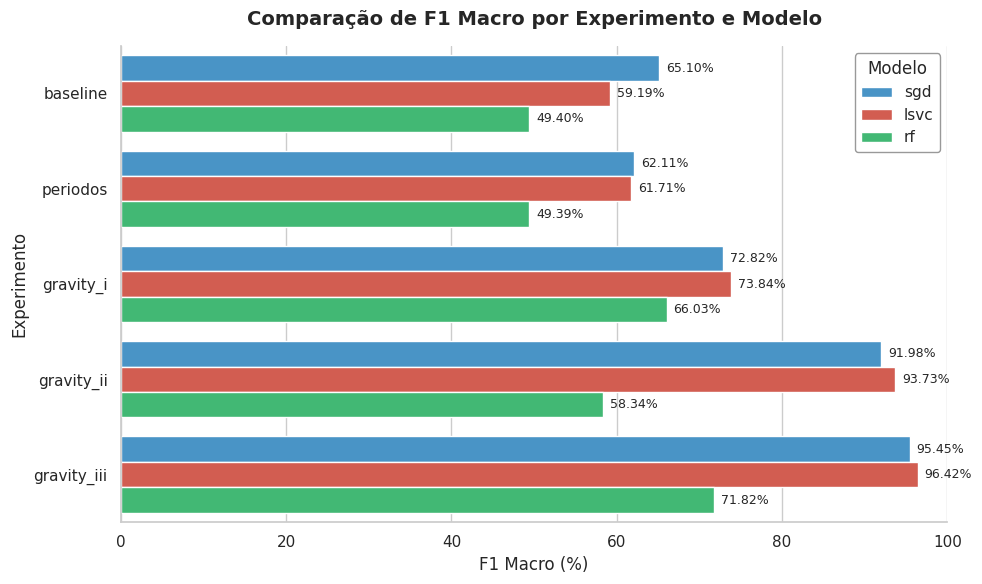

In [219]:
plot_experiment_comparison(
    df=df_experiment_results,
    metric="F1 Macro (%)",
    title="Comparação de F1 Macro por Experimento e Modelo"
)


Essa melhora em relação a baseline, como mostra o gráfico acima do F1 Macro, foi mais evidente a partir do momento em que os atributos de feridos foram considerados pelo modelo, o que é esperado, pois, quanto mais feridos, maior a chance do acidente ter resultado em fatalidades. Ganho similar não ocorreu ao adicionar as colunas booleanas de fim de semana e feriados, pois, apesar do senso comum dizer que, nesses períodos a chance de acidentes também é maior, para os modelos não foi um fator tão discriminante entre as classes na hora de tomar sua decisão, com exceção do LSVC, que teve um leve ganho, saindo de 59,19% para 61,71%.

Esse pouco impacto dos atributos de período, podem serem explicados pelo fato de, como mostraram os boxplots de distribuição do número de mortes, muitos acidentes possuem via de regra uma única fatalidade, existindo alguns outliers que fogem desse padrão, então, se a grande maioria dos acidentes segue esse padrão, não há um fator de discriminação tão grande entre as classes.

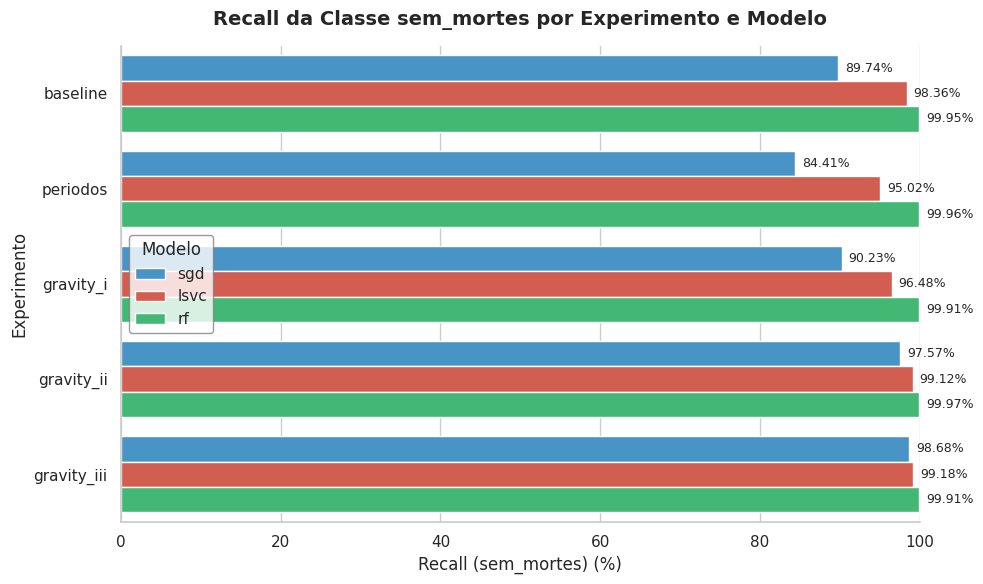

In [220]:
plot_experiment_comparison(
    df=df_experiment_results,
    metric="Recall (sem_mortes) (%)",
    title="Recall da Classe sem_mortes por Experimento e Modelo"
)

Todavia, ao olhar-se somente o F1 Score, vários problemas são escondidos. O objetivo do classificador é identificar corretamente, dado um contexto que variou ao longo dos experimentos (clima, período, feridos), acidentes que resultaram em fatalidades a fim de oferecer uma visão que permita ao poder responsável focar em cuidar das rodovias mais críticas. E ao olharmos o desempenho separado para os acidentes com, e sem mortes, nota-se uma grande dificuldade do modelo, nos primeiros experimentos, em identificar acidentes com fatalidades.

Já os acidentes sem fatalidades tenderam a serem classificados com certa facilidade, com nenhum modelo tendo recall inferior há 80%.

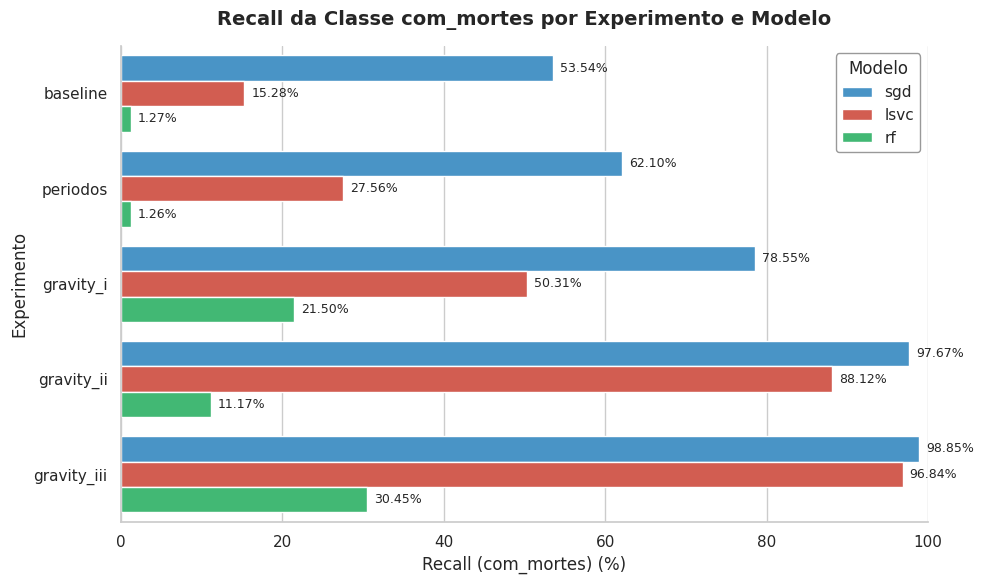

In [221]:
plot_experiment_comparison(
    df=df_experiment_results,
    metric="Recall (com_mortes) (%)",
    title="Recall da Classe com_mortes por Experimento e Modelo"
)


O SGD foi o modelo que mais teve facilidade em identificar os acidentes com mortes de forma geral, sendo alcançado pelo LSVC somente no experimento gravity_iii, que utilizou a combinação das colunas de feridos booleanas e quantitativas.

Já o Random Forest aparenta não ter conseguido encontrar nos atributos do dataset características o suficiente para diferenciar um acidente com morte de um sem morte de forma ótima, mesmo com as informações fornecidas acerca do contexto do acidente sendo enriquecidas ao longo dos experimentos, primeiro com as informações de período, depois, com as informações de feridos.

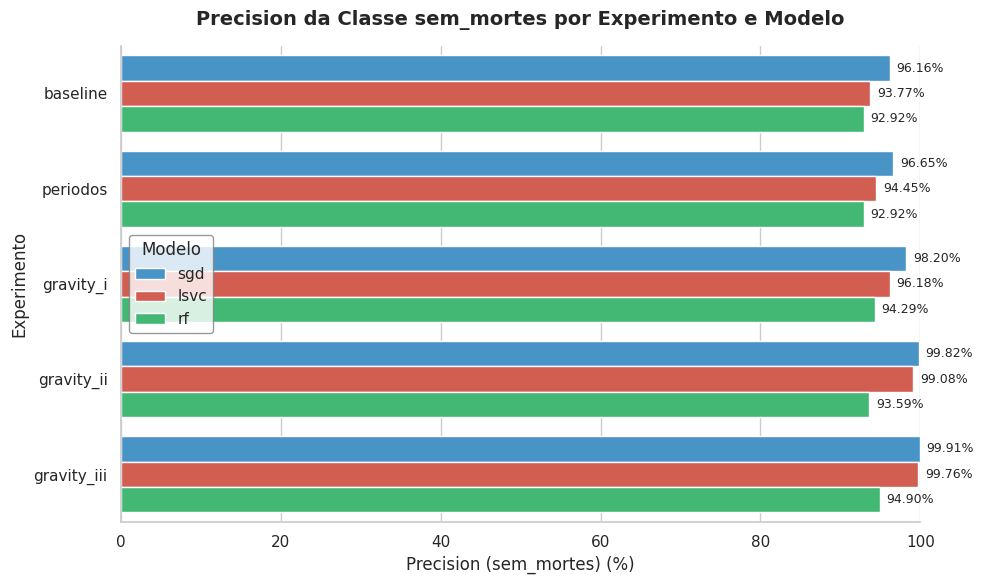

In [222]:
plot_experiment_comparison(
    df=df_experiment_results,
    metric="Precision (sem_mortes) (%)",
    title="Precision da Classe sem_mortes por Experimento e Modelo"
)

Por outro lado,  se o Random Forest não foi capaz de diferenciar muito bem os dois tipos de acidentes, ele foi o modelo, em todos os experimentos, que teve mais certeza de suas decisões, possuindo a maior precision desde a baseline, que melhorou com os atributos de feridos sendo considerados, como mostra a imagem abaixo.

Para todos os modelos, os atributos de feridos foram os que mais contribuíram para que o modelo tivesse uma resposta mais assertiva e reduzi os falsos positivos, enquanto as informações de período, de forma isolada acabaram por confundir mais os modelos, tendo em vista a queda de desempenho sofrida pelo SGD e LSVC em relação a baseline.

Ter certeza acerca dos acidentes sem fatalidades, como mostra a imagem acima, nunca foi problema para nenhum dos modelos.

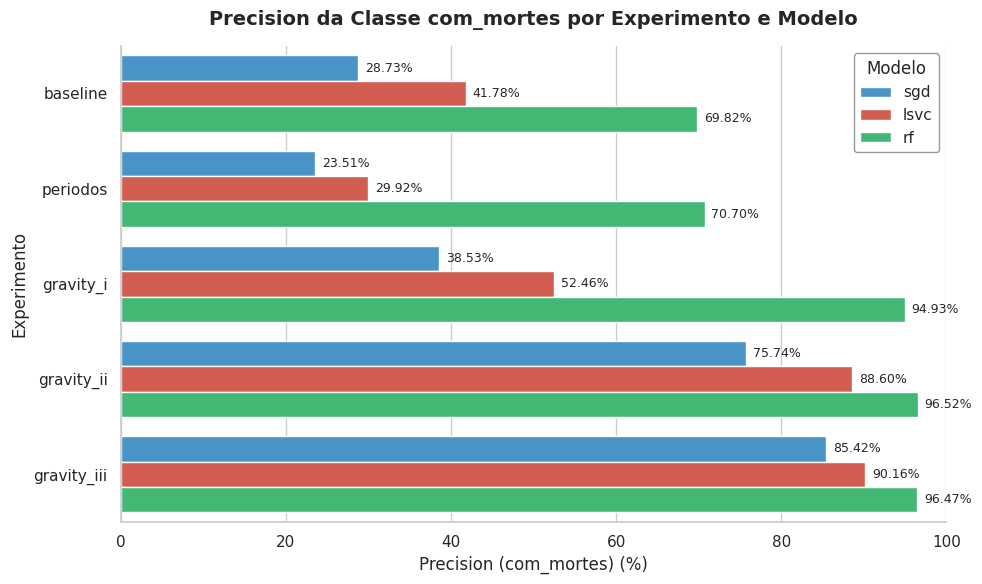

In [223]:
plot_experiment_comparison(
    df=df_experiment_results,
    metric="Precision (com_mortes) (%)",
    title="Precision da Classe com_mortes por Experimento e Modelo"
)


## Melhores modelos

In [224]:
# Carregar o CSV de resumo
csv_path = data_path / "classification_summary.csv"
df_summary = pd.read_csv(csv_path)
df_summary = df_summary.dropna(subset=["experiment"])

# Mapear os rótulos de experimento
exp_labels = []
for idx, row in df_summary.iterrows():
    exp = row["experiment"]
    variant = row["variant"]
    if exp == "baseline":
        exp_labels.append("baseline")
    elif exp == "periods":
        exp_labels.append("periodos")
    elif exp == "gravity":
        exp_labels.append(f"gravity_{variant}")
    else:
        exp_labels.append(exp)

df_summary["Experimento"] = exp_labels

# Ordenar de acordo com a ordem cronológica
order = ["baseline", "periodos", "gravity_i", "gravity_ii", "gravity_iii"]
df_summary["Experimento"] = pd.Categorical(df_summary["Experimento"], categories=order, ordered=True)
df_summary = df_summary.sort_values("Experimento").reset_index(drop=True)

# Preparar o DataFrame no formato "melted" para o Seaborn
melted_rows = []
for idx, row in df_summary.iterrows():
    exp = row["Experimento"]
    best_model = "sgd" if row["best_model"] == "sgb" else row["best_model"]
    
    f1_macro = row["macro_f1"] * 100
    recall_com_mortes = row["teve_mortes_recall"] * 100
    precision_com_mortes = row["teve_mortes_precision"] * 100
    
    melted_rows.append({"Experimento": exp, "Métrica": "F1 Macro (%)", "Valor": f1_macro, "BestModel": best_model})
    melted_rows.append({"Experimento": exp, "Métrica": "Recall (com_mortes) (%)", "Valor": recall_com_mortes, "BestModel": best_model})
    melted_rows.append({"Experimento": exp, "Métrica": "Precision (com_mortes) (%)", "Valor": precision_com_mortes, "BestModel": best_model})

df_plot_summary = pd.DataFrame(melted_rows)

def plot_best_model_summary(df_plot, df_sum, order=order, colors=MODEL_COLORS):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Criar o gráfico base
    sns.barplot(
        y="Experimento",
        x="Valor",
        hue="Métrica",
        data=df_plot,
        ax=ax
    )
    
    ax.set_title("Comparação do Melhor Modelo por Experimento", pad=15, fontsize=14, fontweight="bold")
    ax.set_xlabel("Porcentagem (%)", fontsize=12)
    ax.set_ylabel("Experimento", fontsize=12)
    ax.set_xlim(0, 100)
    
    # Remover bordas superior e direita
    sns.despine(ax=ax, top=True, right=True)
    
    # Mapear os melhores modelos na ordem correta
    best_models_in_order = []
    for exp in order:
        model = df_sum.loc[df_sum["Experimento"] == exp, "best_model"].values[0]
        best_models_in_order.append("sgd" if model == "sgb" else model)
    
    # Texturas correspondentes a cada métrica
    hatches = ["", "//", ".."]
    
    # Personalizar cada barra com cores do modelo e hachuras da métrica
    for metric_idx, container in enumerate(ax.containers):
        hatch = hatches[metric_idx]
        for exp_idx, bar in enumerate(container):
            bar.set_hatch(hatch)
            best_model = best_models_in_order[exp_idx]
            bar.set_facecolor(colors[best_model])
            bar.set_edgecolor("black")
            bar.set_linewidth(1.0)
            
    # Criar legenda personalizada com modelos e métricas agrupados
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(facecolor=colors["sgd"], edgecolor="black", label="Modelo: sgd (Melhor)"),
        mpatches.Patch(facecolor=colors["lsvc"], edgecolor="black", label="Modelo: lsvc (Melhor)"),
        mpatches.Patch(facecolor=colors["rf"], edgecolor="black", label="Modelo: rf (Melhor)"),
        mpatches.Patch(facecolor="#e0e0e0", edgecolor="black", hatch="", label="F1 Macro (%)"),
        mpatches.Patch(facecolor="#e0e0e0", edgecolor="black", hatch="//", label="Recall (com_mortes) (%)"),
        mpatches.Patch(facecolor="#e0e0e0", edgecolor="black", hatch="..", label="Precision (com_mortes) (%)"),
    ]
    
    ax.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=True,
        edgecolor="gray",
        facecolor="white"
    )
    
    # Adicionar rótulos numéricos no final de cada barra com clip_on=False
    for container in ax.containers:
        labels = ax.bar_label(container, fmt="%.2f%%", padding=5, fontsize=9)
        for label in labels:
            label.set_clip_on(False)
            
    plt.tight_layout()
    plt.show()


A figura abaixo exibe de forma gráfica os resultados de `classification_summary.csv`, mostrando o F1 Macro e Recall e Precision da classe de acidentes `com_mortes`:

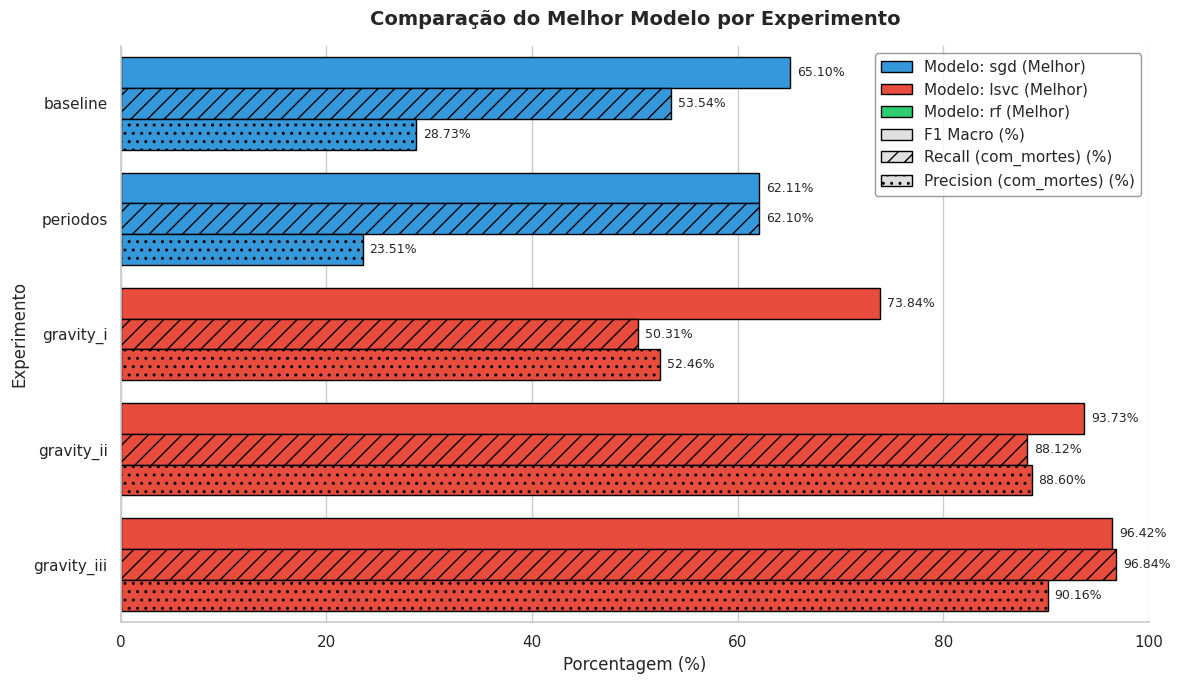

In [225]:
plot_best_model_summary(df_plot_summary, df_summary)


F1 Macro foi a métrica escolhida para decidir o melhor modelo, pois, desejavá-se um modelo que seja bom em reconhecer acidentes fatais e não fatais, não somente um dos casos.

Como discutido na análise geral dos modelos nas seções acima, os acidentes não fatais não foram problema para nenhum modelo em nenhum experimento, então ao analisarmos os melhores modelos em cada experimento, pode-se focar somente nos acidentes com mortes, que é o que acaba puxando o F1 Macro para baixo.

Olhando para os melhores modelos, percebe-se que, para o SGD, as colunas de períodos ajudaram a aumentar o recall da classe com_mortes, apesar da redução na precision. Inclusive sendo melhor no geral para identificar acidentes com mortes do que as colunas boolenas de feridos de forma isolada para o LSVC.

Porém, o gráfico também reforça o que foi descoberto nos testes de hipótese, que, os fatores climáticos não são um fator tão discriminante para indicar se um acidente foi fatal ou não, tendo em vista que a baseline sempre teve acesso a essas informações e seu desempenho não foi superior aos demais. 

O experimento com melhor desempenho sendo o gravity_iii, mostra que, como indica o senso comum, em um acidente, quanto maior o número de feridos, maior o risco de alguém ter morrido, sendo esse o fator mais discriminante, apesar do enriquecimento que o dataset sofreu com dados climáticos.

Sobre os modelos em si, vale destacar que o SGD se comportou, como mostra os melhores parâmetros, com SVM em todas as folds, em todos os experimentos, então, ele e o LSVC estando no topo, mostram que a medida o dataset foi enriquecido, aumentou-se a separabilidade linear entre as classes, principalmente com o uso das colunas quantitativas de feridos.

Portanto, concluí-se que para um modelo treinado para esse problema a quantidade de feridos no acidente é mais revelador para identificar fatalidades do que outros fatores, como clima, fins de semana e presença de feriados.

Nesse contexto, o modelo mais recomendado para o problema é o LSVC treinado no experimento gravity_iii, que teve a maior precision e recall em relação aos acidentes com mortes, sendo capaz de separar as duas classes de uma forma melhor e apresentando uma elevada certeza em suas decisões, além de não ter um tempo de treinamento muito elevado.

## Interpretabilidade

No quesito interpretabilidade, por se tratar de um SVM, não há como ter uma certeza de em qual dimensão o LSVC separou melhor as classes e mesmo que fosse possível exibir, para qualquer dimensão acima de R³, seria impossível para o cérebro humano compreender, olhando para um gráfico 2D ou 3D, como as duas classes foram linearmente separadas. Então, no quesito interpretabilidade, o LSVC é completamente caixa-preta.

Essa afirmação também vale para o SBD que adotou o comportamento de SVM em todos os experimentos. 

O Random Forest dos três modelos é o que consegue proporcionar uma interpretabilidade melhor, já que seria possível extrair algumas das suas árvores de decisão e visualizar como foi o raciocínio do modelo.
